# 03 - Modeliranje 

## Uvodne napomene

### Cilj

U ovom notebook-u, biće ispitano da li se osobine odgovora na kalcijum na nivou neurona mogu iskoristiti za razlikovanje fenotipa eksperimentalnih grupa sa različitim neurodegenerativnim stanjima: ALS, SMA i kontrola.

Analiza obuhvata nekoliko skupova osobina:
1. Status odgovora na tretman CSF-om
2. Osobine referentnog odgovora na K+ tretman
3. Osobine na nivou pikova u odgovoru na CSF i K+
4. Odnosi karakteristika odgovora na CSF i K+
5. Osobine izvedene iz fita odgovora

### Ograničenja

Osnovna jedinica beleženja podataka u originalnom snimanju jeste ROI - region od interesa. To je površina koja je ručno odabrana tako da obuhvata pojedinačnu vijabilnu ćeliju, i sa koje se očitava intenzitet fluorescencije. Sve ćelije u datom eksperimentu su izložene istim uslovima, te se zato ROI iz istog eksperimenta ne mogu posmatrati kao nezavisni biološki uzorci. Set podataka na kom radimo sadrži **997 ROI** iz **6 eksperimenata**, u kojima je korišćena CSF poreklom od **5 pacijenata**.

Imajući ovo u vidu, modeli koji mogu biti konstruisani imaće određena ograničenja:
- Nasumična ukrštena validacija će verovatno davati optimistične rezultate.
- Efekti poreklom od datog eksperimenta i/ili pacijenta će potencijalno imati veći uticaj od uopštenijih efekata poreklom od bolesti.
- Modeli će se posmatrati kao oruđe za mogućnost razdvajanja klasa unutar datog seta podataka, ali se iz njih ne mogu pouzdano izvoditi zaključci koji se mogu generalizovati.

## Uvoz biblioteka i početno podešavanje

In [1]:
from pathlib import Path
import platform
import warnings
from functools import partial
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.base import clone

import feature_engine

from feature_engine.selection import MRMR

# Random seed
RANDOM_STATE = 42

In [2]:
# Verzije softvera
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Feature-engine:", feature_engine.__version__)

Python: 3.13.14
NumPy: 2.4.6
pandas: 3.0.5
scikit-learn: 1.9.0
Feature-engine: 1.9.4


In [3]:
def find_project_root(
    start: Path | None = None,
) -> Path:
    """
    Locira osnovni folder projekta pretragom trenutne direktorije
    i foldera višeg reda.

    Osnovni folder mora sadržati:
    - environment.yml
    - notebooks/
    """
    start = (
        Path.cwd()
        if start is None
        else Path(start)
    ).resolve()

    for candidate in [
        start,
        *start.parents,
    ]:
        if (
            (candidate / "environment.yml").is_file()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Osnovni folder nije pronađen. Uverite se da "
        "environment.yml, i notebooks/ postoje "
        "u glavnom folderu projekta."
    )

In [4]:
def save_figure(
    fig,
    file_stem: str,
    dpi: int = 300,
) -> None:
    """
    Čuva grafik analize kao PNG i PDF.
    """
    png_path = (
        MODELING_FIGURES_DIR
        / f"{file_stem}.png"
    )

    pdf_path = (
        MODELING_FIGURES_DIR
        / f"{file_stem}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

In [5]:
# Direktorije i učitavanje podataka
PROJECT_ROOT = find_project_root()

EXTRACTED_DIR = (
    PROJECT_ROOT
    / "data"
    / "extracted"
)

ENGINEERED_TABLE_PATH = (
    EXTRACTED_DIR
    / "roi_features_engineered.csv"
)

MODELING_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "modeling"
)

MODELING_FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "modeling"
)

MODELING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELING_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not ENGINEERED_TABLE_PATH.is_file():
    raise FileNotFoundError(
        "Tabela za modeliranje nije pronađena:\n"
        f"{ENGINEERED_TABLE_PATH}\n\n"
        "Prvo pokrenite 01_extract_features.ipynb i 02_eda.ipynb."
    )

df = pd.read_csv(
    ENGINEERED_TABLE_PATH
)

print("Osnovni folder projekta:", PROJECT_ROOT)
print("Učitano:", ENGINEERED_TABLE_PATH)
print("Dimenzije:", df.shape)
print("Lokacija grafika:", MODELING_FIGURES_DIR)

Osnovni folder projekta: /home/pera/Faks/Master/MasterProjekatPetarJ
Učitano: /home/pera/Faks/Master/MasterProjekatPetarJ/data/extracted/roi_features_engineered.csv
Dimenzije: (997, 82)
Lokacija grafika: /home/pera/Faks/Master/MasterProjekatPetarJ/results/figures/modeling


In [6]:
# Provera integriteta
print("Broj jedinstvenih zapisa:", df["record_id"].nunique())
print("Duplirani zapisi:", df["record_id"].duplicated().sum())
print("Nedostajuće oznake klasa:", df["class_label"].isna().sum())
print("Nedostajuće oznake eksperimenata:", df["experiment_id"].isna().sum())
print("Nedostajuće oznake pacijenata:", df["patient_id"].isna().sum())

Broj jedinstvenih zapisa: 997
Duplirani zapisi: 0
Nedostajuće oznake klasa: 0
Nedostajuće oznake eksperimenata: 0
Nedostajuće oznake pacijenata: 0


In [7]:
df["class_label"].value_counts()

class_label
SMA        545
ALS        269
Control    183
Name: count, dtype: int64

In [8]:
df.groupby(
    ["class_label", "patient_id", "experiment_id"]
).size()

class_label  patient_id  experiment_id    
ALS          3           patient_3_exp_1      163
             4           patient_4_exp_1      106
Control      7           patient_7_exp_1      183
SMA          10a         patient_10a_exp_1    230
             10b         patient_10b_exp_1    171
                         patient_10b_exp_2    144
dtype: int64

Tabele su u skladu sa očekivanjima. Sada ćemo preći na modeliranje našeg seta podataka.

## Definisanje najvažnijih osobina kalcijumskog odgovora

Prvo ćemo se fokusirati na osobine koje se direktno tiču kalcijumskog odgovora, a kasnije ćemo u modele uključiti i parametre fita za svaki odgovor.

In [9]:
# Promenljiva odgovora
TARGET_COLUMN = "class_label"

# Oznake eksperimenta i pacijenta
EXPERIMENT_GROUP_COLUMN = "experiment_id"
PATIENT_GROUP_COLUMN = "patient_id"

y = df[TARGET_COLUMN].copy()

experiment_groups = df[EXPERIMENT_GROUP_COLUMN].copy()
patient_groups = df[PATIENT_GROUP_COLUMN].copy()

In [10]:
# Eksperimentalne grupe
group_structure = (
    df[
        [
            "class_label",
            "patient_id",
            "experiment_id",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "class_label",
            "patient_id",
            "experiment_id",
        ]
    )
)

group_structure

,class_label,patient_id,experiment_id
545,ALS,3,patient_3_exp_1
708,ALS,4,patient_4_exp_1
814,Control,7,patient_7_exp_1
0,SMA,10a,patient_10a_exp_1
230,SMA,10b,patient_10b_exp_1
401,SMA,10b,patient_10b_exp_2


Ovde vidimo jedno od najvećih ograničenja naših podataka - kontrolna klasa obuhvata samo jedan eksperiment i jednog pacijenta.

Sada ćemo definisati najvažnije osobine podataka:
- Osobine statusa odgovora: `response_status_features`;
- Osobine referentnog K+ odgovora: `k_reference_features`;
- Osnovne osobine CSF odgovora: `csf_response_features`;
- Kombinovane osobine na nivou pikova: `combined_peak_features`;
- Kombinovane osobine na nivou pikova, zajedno sa odnosima amplituda i integrala: `combined_ratio_features`.

In [11]:
response_status_features = [
    "csf_response_detected_int",
    "csf_multiple_responses_int",
]

In [12]:
k_reference_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",
]

In [13]:
csf_response_features = [
    "csf_response_detected_int",
    "csf_multiple_responses_int",
    "csf_amplitude",
    "csf_half_width",
    "csf_integral",
]

In [14]:
combined_peak_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",

    "csf_response_detected_int",
    "csf_multiple_responses_int",
    "csf_amplitude",
    "csf_half_width",
    "csf_integral",
]

In [15]:
combined_ratio_features = [
    *combined_peak_features,
    "csf_to_k_amplitude_ratio",
    "csf_to_k_integral_ratio",
]

In [16]:
# Prikupljanje svih skupova u rečnik
feature_sets = {
    "response_status": response_status_features,
    "k_reference": k_reference_features,
    "csf_response": csf_response_features,
    "combined_peak": combined_peak_features,
    "combined_with_ratios": combined_ratio_features,
}

In [17]:
# Provera da li su sve kolone tu
for feature_set_name, features in feature_sets.items():
    missing_columns = [
        feature for feature in features
        if feature not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{feature_set_name} sadrži nedostajuće kolone: "
            f"{missing_columns}"
        )

In [18]:
# Provera svih nedostajućih vrednosti
feature_set_summary = []

for feature_set_name, features in feature_sets.items():
    subset = df[features]

    feature_set_summary.append(
        {
            "feature_set": feature_set_name,
            "n_features": len(features),
            "rows_with_any_missing": (
                subset.isna().any(axis=1).sum()
            ),
            "fraction_rows_with_any_missing": (
                subset.isna().any(axis=1).mean()
            ),
            "total_missing_values": (
                subset.isna().sum().sum()
            ),
        }
    )

feature_set_summary = pd.DataFrame(feature_set_summary)

feature_set_summary

,feature_set,n_features,rows_with_any_missing,fraction_rows_with_any_missing,total_missing_values
0,response_status,2,0,0.000000,0
1,k_reference,3,1,0.001003,2
2,csf_response,5,322,0.322969,644
3,combined_peak,8,323,0.323972,646
4,combined_with_ratios,10,323,0.323972,969


### Strategija evaluacije modela

Evaluacija modela biće vršena u tri stadijuma.

#### Faza 1 - *Dummy* osnovica

Tzv. *dummy* klasifikacija donosi performanse koje se dobijaju predikcijom isključivo na osnovu učestalosti klasa - izračunava se jednom na početku.

#### Faza 2 - Ukrštena validacija na nivou ROI 

Stratifikovana ukrštena validacija koristi se kao oruđe za ispitivanje mogućnosti razdvajanja klasa unutar datog seta podataka. Očekuju se optimisitčni rezultati iz prostog razloga što se ROI iz istih eksperimenata pojavljuju u različitim podskupovima/foldovima.

#### Faza 3 - Analize senzitivnosti za različite grupe

Oznake eksperimenata i pacijenata koriste se da bi se ispitalo da li performanse klasifikacije primarno zavise od efekata uslova datog eksperimenta.

## Modeli (direktni parametri odgovora)

In [19]:
# Inicijalni CV objekat
roi_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

### *Dummy* klasifikator

In [20]:
# Parametri evaluacije
SCORING = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

Primarni fokus biće na makro F1 (macro F1) vrednosti i balansiranoj tačnosti (balanced accuracy).

\begin{equation}
    Macro \space F1 = \frac{F1_{ALS}+F1_{SMA}+F1_{Control}}{3}
\end{equation}

gde je $F1$ za svaku klasu:

\begin{equation}
    F1 = 2 \times \frac{precision \times recall}{precision+recall}
\end{equation}

pri čemu važi:

\begin{equation}
    Precision = \frac{Correct \space predictions \space of \space a \space class}{All \space predictions \space of \space that \space class}
\end{equation}

kao i:

\begin{equation}
    Recall = \frac{Correctly \space identified \space members \space of \space a \space class}{All \space actual \space members \space of \space that \space class}
\end{equation}

Balansirana tačnost računa se kao:

\begin{equation}
    Balanced \space accuracy = \frac{Recall_{ALS}+Recall_{SMA}+Recall_{Control}}{3}
\end{equation}

gde je tačnost (Accuracy) za svaku klasu:

\begin{equation}
    Accuracy = \frac{Correct \space predictions}{All \space predictions}
\end{equation}

Obična tačnost (Accuracy) posmatraće se kao sekundarni pokazatelj performansi.

In [21]:
# Provera dummy modela
X_dummy = np.zeros((len(df), 1)) # ne zahteva prave prediktore
                                 # ali svejedno očekuje X matriks
 
dummy_model = DummyClassifier(
    strategy="most_frequent",
)

dummy_cv_results = cross_validate(
    estimator=dummy_model,
    X=X_dummy,
    y=y,
    cv=roi_cv,
    scoring=SCORING,
    return_train_score=False,
    error_score="raise",
)

In [22]:
# Prikaz rezultata
dummy_summary = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
        ],
        "mean_cv_score": [
            dummy_cv_results["test_accuracy"].mean(),
            dummy_cv_results["test_balanced_accuracy"].mean(),
            dummy_cv_results["test_f1_macro"].mean(),
        ],
        "std_cv_score": [
            dummy_cv_results["test_accuracy"].std(),
            dummy_cv_results["test_balanced_accuracy"].std(),
            dummy_cv_results["test_f1_macro"].std(),
        ],
    }
)

dummy_summary

,metric,mean_cv_score,std_cv_score
0,accuracy,0.546643,0.001342
1,balanced_accuracy,0.333333,0.000000
2,f1_macro,0.235625,0.000374


Ovde vidimo zašto obična tačnost sama po sebi nije adekvatan parametar. Usled nebalansiranosti klasa, *dummy* prediktor koji svaki put predviđa najčešću klasu (SMA) imaće tačnost od `0.547`. Balansirana tačnost, međutim, ima nižu vrednost i predstavlja realniji pokazatelj kvaliteta ovakvog modela.

### Logistička regresija

In [23]:
def make_logistic_pipeline() -> Pipeline:
    """
    Kreira pajplajn obrade i multinomne klasifikacije.

    Nedostajuće vrednosti se popunjavaju medijalnim, dodaju se indikatori
    nedostajućih vrednosti, numeričke promenljive se standardizuju, i 
    fituje se regularizovani klasifikator logističke regresije.
    """
    return Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=False, # Indikator nedostajuće vrednosti već
                                         # prisutan (csf_response_detected_int)
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced", # važno jer SMA dominira
                    max_iter=5000, 
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

Imputacija pomoću medijalnih vrednosti korisna je za osiguravanje od autlajera. Skaliranje je važno zato što različite osobine (amplitude, integrali, odnosi itd.) imaju znatno različite opsege vrednosti. Regularizacija je podrazumevana u sklearn paketu.

In [24]:
def evaluate_feature_set(
    feature_set_name: str,
    features: list[str],
    model_factory=make_logistic_pipeline, # podrazumevana LR
    model_name: str = "logistic_regression",
) -> dict:
    """
    Vrši evaluaciju kombinacije jednog modela 
    i jednog skupa osobina koristeći fiksnu CV podelu.
    """
    model = model_factory()

    cv_results = cross_validate(
        estimator=model,
        X=df[features],
        y=y,
        cv=roi_cv,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1,
        error_score="raise",
    )

    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "n_features": len(features),

        "test_accuracy_mean": (
            cv_results["test_accuracy"].mean()
        ),
        "test_accuracy_std": (
            cv_results["test_accuracy"].std()
        ),

        "test_balanced_accuracy_mean": (
            cv_results[
                "test_balanced_accuracy"
            ].mean()
        ),
        "test_balanced_accuracy_std": (
            cv_results[
                "test_balanced_accuracy"
            ].std()
        ),

        "test_f1_macro_mean": (
            cv_results["test_f1_macro"].mean()
        ),
        "test_f1_macro_std": (
            cv_results["test_f1_macro"].std()
        ),

        "train_balanced_accuracy_mean": (
            cv_results[
                "train_balanced_accuracy"
            ].mean()
        ),
        "train_balanced_accuracy_std": (
            cv_results[
                "train_balanced_accuracy"
            ].std()
        ),

        "fit_time_mean": (
            cv_results["fit_time"].mean()
        ),
    }

In [25]:
# Evaluacija svih skupova zasebno
logistic_result_rows = []

for feature_set_name, features in feature_sets.items():
    result = evaluate_feature_set(
        feature_set_name=feature_set_name,
        features=features,
    )

    logistic_result_rows.append(result)

In [26]:
# Spajanje rezultata
logistic_results = (
    pd.DataFrame(logistic_result_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

logistic_results

,model,feature_set,n_features,test_accuracy_mean,test_accuracy_std,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean,train_balanced_accuracy_std,fit_time_mean
0,logistic_regression,combined_with_ratios,10,0.911729,0.008823,0.921462,0.007253,0.906194,0.008063,0.928622,0.003523,0.017184
1,logistic_regression,combined_peak,8,0.910724,0.012102,0.919639,0.013060,0.904484,0.011740,0.925773,0.002633,0.014600
2,logistic_regression,k_reference,3,0.745186,0.040902,0.785462,0.034174,0.741086,0.038169,0.784989,0.005661,0.014612
3,logistic_regression,csf_response,5,0.697166,0.032488,0.717888,0.018788,0.681844,0.027206,0.726943,0.003439,0.013628
4,logistic_regression,response_status,2,0.517618,0.029906,0.501743,0.023541,0.409492,0.032680,0.512564,0.006102,0.030798


In [27]:
# Kompaktnija tabela za vizuelizaciju
logistic_results_display = logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].copy()

logistic_results_display.round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_with_ratios,10,0.912,0.921,0.007,0.906,0.008,0.929
1,combined_peak,8,0.911,0.920,0.013,0.904,0.012,0.926
2,k_reference,3,0.745,0.785,0.034,0.741,0.038,0.785
3,csf_response,5,0.697,0.718,0.019,0.682,0.027,0.727
4,response_status,2,0.518,0.502,0.024,0.409,0.033,0.513


Na osnovu ovih rezultata, možemo primetiti sledeće:

- Status odgovora na CSF nije dovoljno dobar prediktor za klasifikaciju stanja, uprkos dramatičnom odstupanju te osobine kod pacijenta `10b`. Iako pomaže za predikciju ROI upravo iz tih eksperimenata, nije korisna u razlikovanju ALS, kontrole i `10a` SMA. 
- Osobine vezane za K+ samostalno dobro razdvajaju klase, što sugeriše da postoje značajne razlike u ćelijskim kulturama između eksperimenata, u procesu snimanja fluorescencije, eksperimentalnim protokolima, i/ili podložnosti ćelija stimulaciji. Iako ove razlike mogu biti biološki značajne, one nisu povezane sa tretmanom CSF-om.
- Osobine vezane za CSF su osrednje informativne same po sebi, iako su slabiji prediktori u odnosu na osobine K+.
- Kombinovane K+/CSF osobine imaju vrlo dobre performanse. Razlika u odnosu na K+ osobine same po sebi sugeriše da informacije poreklom od CSF-a doprinose prediktivnoj vrednosti modela.
- Međutim, odnosi amplituda i integrala imaju zanemarljiv doprinos. Stoga možemo zaključiti da je najbolji skup osobina `combined_peak`.

Kada je u pitanju razlika u performansi prilikom predikcije uzoraka iz skupa za trening i skupa za testiranje, ona je mala - vrednosti balansirane tačnosti su `0.926` i `0.920`, redom. Možemo zaključiti da naš model ne pokazuje prekomerno fitovanje; međutim, i dalje postoji problem da se ROI iz svakog eksperimenta pojavljuju u podskupovima i za trening i za validaciju.

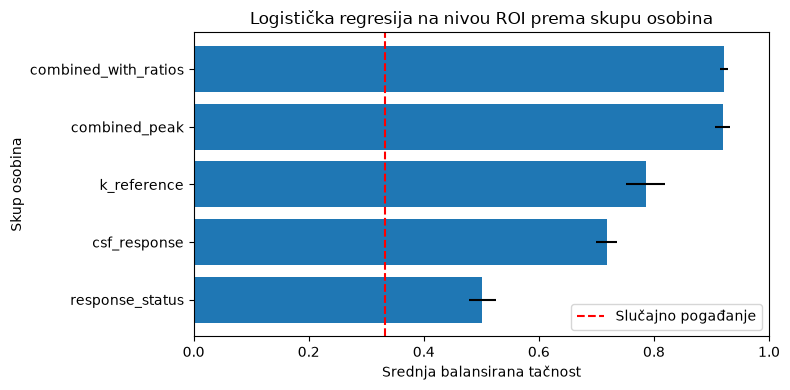

In [28]:
# Vizuelizacija balansirane tačnosti
plot_data = logistic_results.sort_values(
    "test_balanced_accuracy_mean"
)

plt.figure(figsize=(8, 4))

plt.barh(
    plot_data["feature_set"],
    plot_data["test_balanced_accuracy_mean"],
    xerr=plot_data["test_balanced_accuracy_std"],
)

plt.axvline(
    1 / 3,
    linestyle="--",
    color="red",
    label="Slučajno pogađanje",
)

plt.xlabel("Srednja balansirana tačnost")
plt.ylabel("Skup osobina")
plt.title("Logistička regresija na nivou ROI prema skupu osobina")
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Generisanje predikcija na osnovu out-of-fold uzoraka
# koristeći najbolji skup osobina
best_features = feature_sets["combined_peak"]

best_logistic_model = make_logistic_pipeline()

best_oof_predictions = cross_val_predict(
    estimator=best_logistic_model,
    X=df[best_features],
    y=y,
    cv=roi_cv,
    method="predict",
    n_jobs=-1,
)

In [30]:
print(
    classification_report(
        y_true=y,
        y_pred=best_oof_predictions,
        digits=3,
    )
)

              precision    recall  f1-score   support

         ALS      0.879     0.918     0.898       269
     Control      0.844     0.945     0.892       183
         SMA      0.955     0.895     0.924       545

    accuracy                          0.911       997
   macro avg      0.893     0.920     0.905       997
weighted avg      0.914     0.911     0.911       997



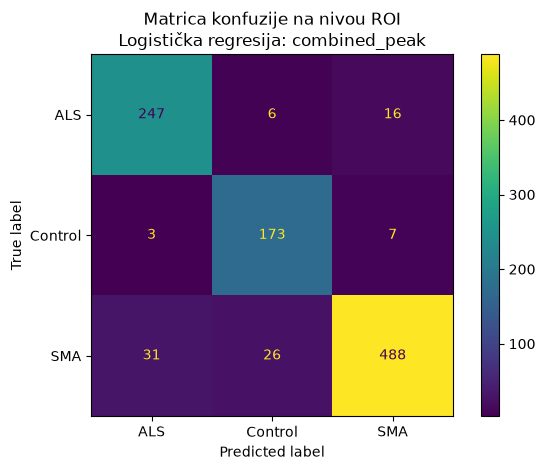

In [31]:
# Matrica konfuzije
ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=best_oof_predictions,
    normalize=None,
)

plt.title(
    f"Matrica konfuzije na nivou ROI\n"
    f"Logistička regresija: combined_peak"
)
plt.tight_layout()
plt.show()

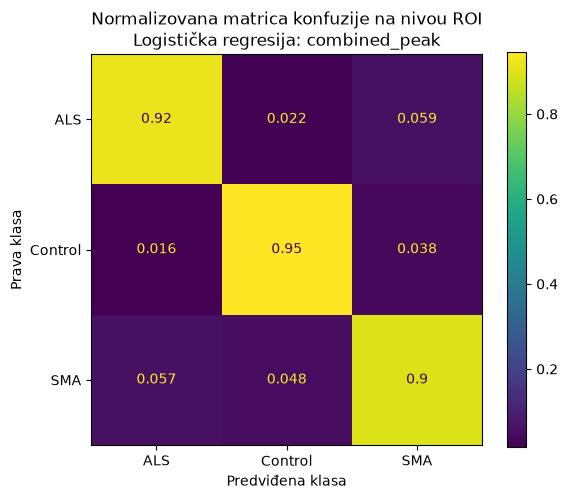

In [32]:
# Normalizovana matrica
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=best_oof_predictions,
    ax=ax,
    normalize="true",
)

ax.set_xlabel("Predviđena klasa")
ax.set_ylabel("Prava klasa")
ax.set_title(
    f"Normalizovana matrica konfuzije na nivou ROI\n"
    f"Logistička regresija: combined_peak"
)
fig.tight_layout()

save_figure(
    fig,
    "ROI_cv_confusion_matrix",
)

plt.show()

Model ima visoku senzitivnost za svaku klasu. Rezultat deluje izbalansirano, iako je SMA dominantna klasa. Ipak, i dalje je važno imati na umu da svaki validacioni podskup ima ROI koji su veoma slični ROI prisutnim u podskupu za trening, budući da potiču iz istog eksperimenta. Visoka senzitivnost za kontrolnu grupu je, stoga, pre svega dokaz da model prepoznaje taj eksperiment, ne i da će prepoznati novi kontrolni uzorak.

In [33]:
# Čuvanje prvih rezultata
LOGISTIC_RESULTS_DIR = MODELING_RESULTS_DIR / "LR"

LOGISTIC_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

dummy_summary.to_csv(
    LOGISTIC_RESULTS_DIR / "dummy_classifier_cv_results.csv",
    index=False,
)

logistic_results.to_csv(
    LOGISTIC_RESULTS_DIR / "logistic_regression_cv_results.csv",
    index=False,
)

Sada ćemo ispitati performanse trenutnog modela za svaki eksperiment zasebno.

In [34]:
# Tabela out-of-fold rezultata
oof_results = df[
    [
        "record_id",
        "class_label",
        "patient_id",
        "experiment_id",
    ]
].copy()

oof_results["predicted_class"] = best_oof_predictions

oof_results["correct"] = (
    oof_results["class_label"]
    == oof_results["predicted_class"]
)

In [35]:
# Sažetak tačnosti po eksperimentu
experiment_oof_summary = (
    oof_results
    .groupby(
        [
            "experiment_id",
            "patient_id",
            "class_label",
        ],
        dropna=False,
    )
    .agg(
        n_rois=("record_id", "count"),
        n_correct=("correct", "sum"),
        accuracy=("correct", "mean"),
    )
    .reset_index()
)

experiment_oof_summary

,experiment_id,patient_id,class_label,n_rois,n_correct,accuracy
0,patient_10a_exp_1,10a,SMA,230,210,0.913043
1,patient_10b_exp_1,10b,SMA,171,154,0.900585
2,patient_10b_exp_2,10b,SMA,144,124,0.861111
3,patient_3_exp_1,3,ALS,163,152,0.932515
4,patient_4_exp_1,4,ALS,106,95,0.896226
5,patient_7_exp_1,7,Control,183,173,0.945355


In [36]:
# Konfuzija za svaki eksperiment
experiment_prediction_table = pd.crosstab(
    index=[
        oof_results["experiment_id"],
        oof_results["class_label"],
    ],
    columns=oof_results["predicted_class"],
    normalize="index",
)

experiment_prediction_table.round(3)

,predicted_class,ALS,Control,SMA
experiment_id,class_label,,,
patient_10a_exp_1,SMA,0.057,0.030,0.913
patient_10b_exp_1,SMA,0.070,0.029,0.901
patient_10b_exp_2,SMA,0.042,0.097,0.861
patient_3_exp_1,ALS,0.933,0.025,0.043
patient_4_exp_1,ALS,0.896,0.019,0.085
patient_7_exp_1,Control,0.016,0.945,0.038


Tačnost je u opsegu od `0.86` do `0.95`, tako da možemo reći da model manje-više dobro prepoznaje ROI iz svih 6 eksperimenata. Međutim, svaki CV skup sadrži ROI iz istih eksperimenata u setu za trening i u setu za validaciju, tako da model u suštini predviđa ROI sa čijim je karakterističnim "potpisom" već upoznat.

Sada ćemo ispitati da li prediktori koje smo izabrali mogu pouzdano da identifikuju eksperiment, kako bismo ispitali da li i koliko karakteristike odgovora zavise od eksperimenta.

In [37]:
experiment_target = df["experiment_id"]

experiment_diagnostic_feature_sets = {
    "k_reference": k_reference_features,
    "combined_peak": combined_peak_features,
}

In [38]:
def evaluate_experiment_identification(
    feature_set_name: str,
    features: list[str],
) -> dict:
    """
    Generiše rečnik na osnovu kog se pravi tabela sa vrednostima performansi 
    modela za dati skup osobina, gde je taj skup naznačen u prvoj koloni.
    """
    X = df[features].copy()

    model = make_logistic_pipeline()

    cv_results = cross_validate(
        estimator=model,
        X=X,
        y=experiment_target,
        cv=roi_cv,
        scoring=SCORING,
        return_train_score=True,
        error_score="raise",
        n_jobs=-1,
    )

    return {
        "feature_set": feature_set_name,
        "test_accuracy_mean": (
            cv_results["test_accuracy"].mean()
        ),
        "test_balanced_accuracy_mean": (
            cv_results["test_balanced_accuracy"].mean()
        ),
        "test_balanced_accuracy_std": (
            cv_results["test_balanced_accuracy"].std()
        ),
        "test_f1_macro_mean": (
            cv_results["test_f1_macro"].mean()
        ),
        "train_balanced_accuracy_mean": (
            cv_results["train_balanced_accuracy"].mean()
        ),
    }

In [39]:
experiment_identification_results = pd.DataFrame(
    [
        evaluate_experiment_identification(name, features)
        for name, features
        in experiment_diagnostic_feature_sets.items()
    ]
)

experiment_identification_results.round(3)

,feature_set,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,train_balanced_accuracy_mean
0,k_reference,0.619,0.632,0.034,0.621,0.641
1,combined_peak,0.878,0.878,0.016,0.873,0.895


Kao što smo mogli zaključiti i na osnovu EDA, K+ odgovor sam po sebi nosi izražen potpis eksperimenta. Sa dodatim CSF osobinama, model skoro podjednako dobro prepoznaje eksperiment (`0.878` srednja balansirana tačnost) i klasu bolesti (`0.920`). Ovo potvrđuje naše početnu pretpostavku - karakteristike pacijenta, eksperimenta i klase su usko povezane, i svaki eksperiment ima veliki broj međusobno sličnih ROI.

Sada ćemo ispitati moć generalizacije našeg modela u testu sa izostavljanjem jednog od SMA/ALS pacijenata iz trening seta, kako bismo videli kako se model ponaša sa pacijentima sa kojima nije upoznat.

In [40]:
patient_id_as_string = df["patient_id"].astype(str)

eligible_held_out_patients = [
    "3",
    "4",
    "10a",
    "10b",
]

patient_holdout_rows = []
patient_holdout_predictions = []

In [41]:
for held_out_patient in eligible_held_out_patients:
    test_mask = (
        patient_id_as_string == held_out_patient
    )

    train_mask = ~test_mask

    X_train = df.loc[
        train_mask,
        combined_peak_features,
    ]

    X_test = df.loc[
        test_mask,
        combined_peak_features,
    ]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    true_class = y_test.iloc[0]

    # Osigurati da data klasa i dalje postoji u trening setu
    if true_class not in y_train.unique():
        print(
            f"Preskačem {held_out_patient}: "
            f"klasa {true_class} nedostaje u trening setu."
        )
        continue

    model = make_logistic_pipeline()

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    patient_accuracy = (
        predictions == y_test.to_numpy()
    ).mean()

    patient_holdout_rows.append(
        {
            "held_out_patient": held_out_patient,
            "true_class": true_class,
            "n_test_rois": len(y_test),
            "held_out_class_recall": patient_accuracy,
        }
    )

    prediction_frame = pd.DataFrame(
        {
            "held_out_patient": held_out_patient,
            "true_class": y_test.to_numpy(),
            "predicted_class": predictions,
        }
    )

    patient_holdout_predictions.append(
        prediction_frame
    )

In [42]:
patient_holdout_summary = pd.DataFrame(
    patient_holdout_rows
)

patient_holdout_summary

,held_out_patient,true_class,n_test_rois,held_out_class_recall
0,3,ALS,163,0.214724
1,4,ALS,106,0.377358
2,10a,SMA,230,0.060870
3,10b,SMA,315,0.184127


In [43]:
# Predviđanje
patient_holdout_predictions = pd.concat(
    patient_holdout_predictions,
    ignore_index=True,
)

patient_holdout_prediction_distribution = pd.crosstab(
    index=[
        patient_holdout_predictions[
            "held_out_patient"
        ],
        patient_holdout_predictions[
            "true_class"
        ],
    ],
    columns=patient_holdout_predictions[
        "predicted_class"
    ],
    normalize="index",
)

patient_holdout_prediction_distribution.round(3)

,predicted_class,ALS,Control,SMA
held_out_patient,true_class,,,
10a,SMA,0.778,0.161,0.061
10b,SMA,0.622,0.194,0.184
3,ALS,0.215,0.184,0.601
4,ALS,0.377,0.028,0.594


Sada i definitivno vidimo da model prevashodno uči na obrascima karakterističnim za pacijenta, ne na onim karakterističnim za klasu bolesti. Srednja vrednost senzitivnosti je `0.209`, iako je šansa nasumičnog pogađanja tačne klase `0.333`. Osim toga, uočavamo sledeće:
- Pacijent ALS `3` uglavnom biva predviđen kao SMA;
- Pacijent ALS `4` takođe;
- Pacijent SMA `10a` uglavnom biva predviđen kao ALS;
- Pacijent SMA `10b` takođe.

Na osnovu ovoga možemo tvrditi da dva ALS pacijenta jednostavno nisu dovoljno slična kako bi se na osnovu jednog mogao predvideti drugi. Ovo je još izraženije za dva SMA pacijenta, koji su još više međusobno različiti.

Analizu sa izostavljanjem jednog pacijenta iz trening podataka sada možemo ponoviti za različite skupove osobina, kako bismo videli da li neki drugi skup bolje služi u predikciji.

In [44]:
def run_patient_holdout_analysis(
    feature_set_dictionary: dict[str, list[str]],
    model_factory=make_logistic_pipeline,
    model_name: str = "logistic_regression",
    data: pd.DataFrame = df,
    target: pd.Series = y,
    held_out_patients: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Vrši evaluaciju više skupova osobina izostavljanjem jednog po jednog pacijenta.

    Vraća sledeće DF:
        long_results:
            Jedan red po kombinaciji skupa osobina i izostavljenog pacijenta.

        pivot_table:
            Izostavljeni pacijenti kao redovi i skupovi osobina kao kolone.

        summary_table:
            Srednja vrednost, standardna devijacija, minimalna i 
            maksimalna vrednost senzitivnosti za izostavljene pacijente.
    """
    if held_out_patients is None:
        held_out_patients = [
            "3",
            "4",
            "10a",
            "10b",
        ]

    patient_ids = data["patient_id"].astype(str)

    result_rows = []

    for feature_set_name, features in (
        feature_set_dictionary.items()
    ):

        for held_out_patient in held_out_patients:
            test_mask = (
                patient_ids == held_out_patient
            )
            train_mask = ~test_mask

            X_train = data.loc[
                train_mask,
                features,
            ]
            X_test = data.loc[
                test_mask,
                features,
            ]

            y_train = target.loc[train_mask]
            y_test = target.loc[test_mask]

            true_class = y_test.iloc[0]

            # Data klasa bolesti mora biti prisutna u trening skupu
            if true_class not in y_train.unique():
                continue

            model = model_factory()

            model.fit(
                X_train,
                y_train,
            )

            predictions = model.predict(X_test)

            correct_class_recall = (
                predictions
                == y_test.to_numpy()
            ).mean()

            result_rows.append(
                {
                    "model": model_name,
                    "feature_set": feature_set_name,
                    "held_out_patient": held_out_patient,
                    "true_class": true_class,
                    "n_test_rois": len(y_test),
                    "correct_class_recall": (
                        correct_class_recall
                    ),
                }
            )

    long_results = pd.DataFrame(result_rows)

    pivot_table = long_results.pivot(
        index="held_out_patient",
        columns="feature_set",
        values="correct_class_recall",
    )

    summary_table = (
        long_results
        .groupby("feature_set")
        .agg(
            mean_patient_recall=(
                "correct_class_recall",
                "mean",
            ),
            std_patient_recall=(
                "correct_class_recall",
                "std",
            ),
            minimum_patient_recall=(
                "correct_class_recall",
                "min",
            ),
            maximum_patient_recall=(
                "correct_class_recall",
                "max",
            ),
        )
        .sort_values(
            "mean_patient_recall",
            ascending=False,
        )
        .reset_index()
    )

    summary_table.insert(
        0,
        "model",
        model_name,
    )

    return (
        long_results,
        pivot_table,
        summary_table,
    )

In [45]:
(
    patient_holdout_results,
    patient_holdout_pivot,
    patient_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=feature_sets,
)

patient_holdout_pivot.round(3)

feature_set,combined_peak,combined_with_ratios,csf_response,k_reference,response_status
held_out_patient,,,,,
10a,0.061,0.057,0.057,0.735,0.061
10b,0.184,0.083,0.003,0.435,0.086
3,0.215,0.153,0.031,0.166,0.000
4,0.377,0.292,0.047,0.453,0.849


In [46]:
patient_holdout_summary.round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,logistic_regression,k_reference,0.447,0.232,0.166,0.735
1,logistic_regression,response_status,0.249,0.402,0.000,0.849
2,logistic_regression,combined_peak,0.209,0.130,0.061,0.377
3,logistic_regression,combined_with_ratios,0.146,0.106,0.057,0.292
4,logistic_regression,csf_response,0.034,0.023,0.003,0.057


Rezultati govore sledeće:
- `k_reference` ima senzitivnost veću od slučajne (`0.333`), ali budući da su ove osobine nezavisne od klase bolesti, ne možemo ih posmatrati kao dobre prediktore naše ciljne promenljive;
- `response_status` ima drugu najvišu vrednost, pri čemu je interesantno da je ovaj rezultat posledica veoma niske sposobnosti razdvajanja za sve pacijente, osim za pacijenta ALS `4` gde je senzitivnost `0.849`.
- `combined_with_ratios` ima niže sposobnosti razdvajanja od `combined_peak`, verovatno zbog prisustva razlika u eksperimentalnim protokolima;
- `csf_response` sam po sebi veoma slabo razdvaja klase, što sugeriše da je važno posmatrati parametre odgovora na CSF zajedno sa parametrima odgovora na K+.

Imajući sve to u vidu, verovatno najviše ima smisla koristiti `combined_peak` kao preferiranu grupu prediktora. Sada možemo probati da pogledamo koeficijente fitovane jednačine logističke regresije za svaku klasu.

In [47]:
# Čuvanje rezultata
patient_holdout_results.to_csv(
    LOGISTIC_RESULTS_DIR / "patient_holdout_results.csv",
    index=False,
)

patient_holdout_pivot.to_csv(
    LOGISTIC_RESULTS_DIR / "patient_holdout_pivot.csv",
    index=False,
)

### Interpretacija koeficijenata

In [48]:
interpretable_model = make_logistic_pipeline()

interpretable_model.fit(
    df[combined_peak_features],
    y,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['ALS','Control','SMA']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['k_ref_amplitude','k_ref_half_width','k_ref_integral',...,'csf_amplitude', 'csf_half_width','csf_integral']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace

In [49]:
classifier = interpretable_model.named_steps[
    "classifier"
]

transformed_feature_names = (
    combined_peak_features.copy()
)

coefficient_table = pd.DataFrame(
    classifier.coef_.T,
    index=transformed_feature_names,
    columns=classifier.classes_,
)

coefficient_table

,ALS,Control,SMA
k_ref_amplitude,-1.509631,1.746119,-0.236487
k_ref_half_width,0.668157,0.548721,-1.216879
k_ref_integral,3.039822,-3.885011,0.845189
csf_response_detected_int,0.563861,1.532746,-2.096607
csf_multiple_responses_int,-0.150344,0.191987,-0.041643
csf_amplitude,0.361007,0.592100,-0.953107
csf_half_width,1.043486,-1.900141,0.856655
csf_integral,-0.524600,-1.692003,2.216603


In [50]:
for class_label in classifier.classes_:
    coefficients = coefficient_table[class_label]

    positive_coefficients = (
        coefficients.loc[coefficients > 0]
        .sort_values(ascending=False)
        .to_frame(name="coefficient")
    )

    negative_coefficients = (
        coefficients.loc[coefficients < 0]
        .sort_values()
        .to_frame(name="coefficient")
    )

    print(f"\nPozitivni koeficijenti za {class_label}")
    display(positive_coefficients)

    print(f"\nNegativni koeficijenti za {class_label}")
    display(negative_coefficients)


Pozitivni koeficijenti za ALS


,coefficient
k_ref_integral,3.039822
csf_half_width,1.043486
k_ref_half_width,0.668157
csf_response_detected_int,0.563861
csf_amplitude,0.361007



Negativni koeficijenti za ALS


,coefficient
k_ref_amplitude,-1.509631
csf_integral,-0.524600
csf_multiple_responses_int,-0.150344



Pozitivni koeficijenti za Control


,coefficient
k_ref_amplitude,1.746119
csf_response_detected_int,1.532746
csf_amplitude,0.592100
k_ref_half_width,0.548721
csf_multiple_responses_int,0.191987



Negativni koeficijenti za Control


,coefficient
k_ref_integral,-3.885011
csf_half_width,-1.900141
csf_integral,-1.692003



Pozitivni koeficijenti za SMA


,coefficient
csf_integral,2.216603
csf_half_width,0.856655
k_ref_integral,0.845189



Negativni koeficijenti za SMA


,coefficient
csf_response_detected_int,-2.096607
k_ref_half_width,-1.216879
csf_amplitude,-0.953107
k_ref_amplitude,-0.236487
csf_multiple_responses_int,-0.041643


Koeficijenti umnogome oslikavaju razlike u eksperimentalnim protokolima, naročito za ALS gde je prisutan veoma visok koeficijent uz `k_ref_integral`. Mada, postoji i pozitivan doprinos od `csf_half_width` i `csf_amplitude`. 

Uopšteno govoreći, mnogi od koeficijenata povezani su sa referentnim odgovorom na kalijum ili su povezani sa tokom datog eksperimenta.

Sada ćemo preći na jednostavne modele LR koji sadrže i parametre fita, ali prvo moramo da definišemo te osobine.

## Definisanje osobina fita kalcijumskog odgovora

In [51]:
# Svi parametri fita
full_k_fit_features = [
    "k_ref_free_coef",
    "k_ref_coef_fast",
    "k_ref_tau_fast",
    "k_ref_coef_slow",
    "k_ref_tau_slow",
    "k_ref_gof",
    "k_ref_percent_fast",
]

full_csf_fit_features = [
    "csf_free_coef",
    "csf_coef_fast",
    "csf_tau_fast",
    "csf_coef_slow",
    "csf_tau_slow",
    "csf_gof",
    "csf_percent_fast",
]

full_fit_features = [
    *full_k_fit_features,
    *full_csf_fit_features,
]

In [52]:
# Rečnik sa parametrima CSF fita
csf_fit_feature_sets = {
    # Dostupnost fita
    "csf_fit_status": [
        "csf_fit_valid_int",
    ],

    # Jednostavna kinetika brze komponente
    "csf_fit_fast_tau": [
        "csf_fit_valid_int",
        "csf_tau_fast",
    ],

    # Brzi raspad + relativni doprinos brze komponente
    "csf_fit_reduced": [
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    # Testira da li kvalitet fita pruža informacije
    "csf_fit_reduced_with_gof": [
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    # Potpun prikaz CSF fita
    "csf_fit_full": [
        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],

    # Direktni parametri CSF odgovora + brza vremenska konst.
    "csf_peak_plus_fast_tau": [
        *csf_response_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
    ],

    ## Direktni parametri CSF odgovora + redukovana kinetika
    "csf_peak_plus_reduced_fit": [
        *csf_response_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    # Testira da li kvalitet fita pruža informacije
    "csf_peak_plus_reduced_fit_and_gof": [
        *csf_response_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    # Sve CSF-vezane osobine
    "csf_peak_plus_full_fit": [
        *csf_response_features,
        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],
}

In [53]:
# Rečnik sa parametrima K+ fita
k_fit_feature_sets = {
    "k_fit_status": [
        "k_ref_fit_valid_int",
    ],

    "k_fit_fast_tau": [
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
    ],

    "k_fit_reduced": [
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
    ],

    "k_fit_reduced_with_gof": [
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",
    ],

    "k_fit_full": [
        "k_ref_fit_valid_int",
        *full_k_fit_features,
    ],

    "k_reference_plus_fast_tau": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
    ],

    "k_reference_plus_reduced_fit": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
    ],

    "k_reference_plus_reduced_fit_and_gof": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",
    ],

    "k_reference_plus_full_fit": [
        *k_reference_features,
        "k_ref_fit_valid_int",
        *full_k_fit_features,
    ],
}

In [54]:
# Rečnik sa kombinovanim parametrima K+ i CSF fita
combined_fit_feature_sets = {
    "combined_fit_status": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
    ],

    "combined_fit_fast_tau": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
        "k_ref_tau_fast",
        "csf_tau_fast",
    ],

    "combined_fit_reduced": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    "combined_fit_reduced_with_gof": [
        "k_ref_fit_valid_int",
        "csf_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    "combined_fit_full": [
        "k_ref_fit_valid_int",
        *full_k_fit_features,
        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],
}

In [55]:
# Rečnik sa kombinovanim parametrima odgovora i fita za K+ i CSF
combined_peak_fit_feature_sets = {
    "combined_peak": combined_peak_features,

    "combined_peak_plus_k_reduced_fit": [
        *combined_peak_features,
        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
    ],

    "combined_peak_plus_csf_reduced_fit": [
        *combined_peak_features,
        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    "combined_peak_plus_both_reduced_fit": [
        *combined_peak_features,

        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",

        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
    ],

    "combined_peak_plus_both_reduced_fit_and_gof": [
        *combined_peak_features,

        "k_ref_fit_valid_int",
        "k_ref_tau_fast",
        "k_ref_percent_fast",
        "k_ref_gof",

        "csf_fit_valid_int",
        "csf_tau_fast",
        "csf_percent_fast",
        "csf_gof",
    ],

    "combined_peak_plus_both_full_fit": [
        *combined_peak_features,

        "k_ref_fit_valid_int",
        *full_k_fit_features,

        "csf_fit_valid_int",
        *full_csf_fit_features,
    ],
}

In [56]:
# Provera rečnika
for dictionary_name, feature_set_dictionary in {
    "csf_fit_feature_sets": csf_fit_feature_sets,
    "k_fit_feature_sets": k_fit_feature_sets,
    "combined_fit_feature_sets": combined_fit_feature_sets,
    "combined_peak_fit_feature_sets": combined_peak_fit_feature_sets
}.items():

    print(f"\n{dictionary_name}")

    for feature_set_name, features in feature_set_dictionary.items():
        missing_columns = [
            feature
            for feature in features
            if feature not in df.columns
        ]

        duplicate_columns = (
            pd.Index(features)[
                pd.Index(features).duplicated()
            ]
            .tolist()
        )

        if missing_columns:
            raise ValueError(
                f"{feature_set_name} sadrži nedostajuće kolone: "
                f"{missing_columns}"
            )

        if duplicate_columns:
            raise ValueError(
                f"{feature_set_name} sadrži duplirane kolone: "
                f"{duplicate_columns}"
            )

        print(
            f"{feature_set_name:38s}"
            f"{len(features):2d} osobina"
        )


csf_fit_feature_sets
csf_fit_status                         1 osobina
csf_fit_fast_tau                       2 osobina
csf_fit_reduced                        3 osobina
csf_fit_reduced_with_gof               4 osobina
csf_fit_full                           8 osobina
csf_peak_plus_fast_tau                 7 osobina
csf_peak_plus_reduced_fit              8 osobina
csf_peak_plus_reduced_fit_and_gof      9 osobina
csf_peak_plus_full_fit                13 osobina

k_fit_feature_sets
k_fit_status                           1 osobina
k_fit_fast_tau                         2 osobina
k_fit_reduced                          3 osobina
k_fit_reduced_with_gof                 4 osobina
k_fit_full                             8 osobina
k_reference_plus_fast_tau              5 osobina
k_reference_plus_reduced_fit           6 osobina
k_reference_plus_reduced_fit_and_gof   7 osobina
k_reference_plus_full_fit             11 osobina

combined_fit_feature_sets
combined_fit_status                    2 osobina


## Modeli (sa parametrima fita kalcijumskog odgovora)

Koristićemo već definisani tok rada, sa postojećom `evaluate_feature_set()` funkcijom.

In [57]:
# Model samo sa parametrima CSF fita
csf_fit_logistic_rows = []

for feature_set_name, features in csf_fit_feature_sets.items():
    csf_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

csf_fit_logistic_results = (
    pd.DataFrame(csf_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [58]:
# Poređenje sa csf_response
csf_fit_comparison = pd.concat(
    [
        logistic_results.loc[
            logistic_results["feature_set"]
            == "csf_response"
        ],
        csf_fit_logistic_results,
    ],
    ignore_index=True,
)

csf_fit_comparison[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].sort_values(
    "test_balanced_accuracy_mean",
    ascending=False,
).round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
1,csf_peak_plus_full_fit,13,0.754,0.778,0.024,0.745,0.031,0.790
2,csf_peak_plus_reduced_fit_and_gof,9,0.749,0.769,0.023,0.738,0.029,0.779
3,csf_peak_plus_fast_tau,7,0.713,0.736,0.014,0.701,0.022,0.749
4,csf_peak_plus_reduced_fit,8,0.713,0.736,0.015,0.701,0.023,0.751
5,csf_fit_full,8,0.705,0.735,0.043,0.699,0.048,0.748
6,csf_fit_reduced_with_gof,4,0.693,0.728,0.032,0.689,0.036,0.723
0,csf_response,5,0.697,0.718,0.019,0.682,0.027,0.727
7,csf_fit_fast_tau,2,0.668,0.708,0.050,0.665,0.053,0.710
8,csf_fit_reduced,3,0.667,0.707,0.042,0.664,0.046,0.707
9,csf_fit_status,1,0.479,0.509,0.024,0.368,0.024,0.509


Parametri CSF fita poboljšavaju klasifikaciju na nivou ROI. `csf_response` ima srednju vrednost balansirane tačnosti od `0.718`, dok `csf_peak_plus_full_fit` povećava ovu vrednost na `0.778`.

In [59]:
# Izostavljanje po jednog pacijenta
csf_holdout_feature_sets = {
    "csf_response": feature_sets["csf_response"],
    **csf_fit_feature_sets,
}

(
    csf_fit_holdout_results,
    csf_fit_holdout_pivot,
    csf_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=csf_holdout_feature_sets,
)

In [60]:
csf_fit_holdout_pivot.round(3)

feature_set,csf_fit_fast_tau,csf_fit_full,csf_fit_reduced,csf_fit_reduced_with_gof,csf_fit_status,csf_peak_plus_fast_tau,csf_peak_plus_full_fit,csf_peak_plus_reduced_fit,csf_peak_plus_reduced_fit_and_gof,csf_response
held_out_patient,,,,,,,,,,
10a,0.070,0.070,0.074,0.078,0.07,0.057,0.052,0.057,0.057,0.057
10b,0.010,0.003,0.010,0.010,0.00,0.006,0.003,0.003,0.003,0.003
3,0.043,0.067,0.049,0.037,0.00,0.025,0.061,0.018,0.037,0.031
4,0.047,0.066,0.038,0.047,0.00,0.038,0.085,0.038,0.075,0.047


In [61]:
csf_fit_holdout_summary.round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,logistic_regression,csf_fit_full,0.052,0.032,0.003,0.070
1,logistic_regression,csf_peak_plus_full_fit,0.050,0.034,0.003,0.085
2,logistic_regression,csf_peak_plus_reduced_fit_and_gof,0.043,0.031,0.003,0.075
3,logistic_regression,csf_fit_reduced_with_gof,0.043,0.028,0.010,0.078
4,logistic_regression,csf_fit_reduced,0.043,0.027,0.010,0.074
5,logistic_regression,csf_fit_fast_tau,0.042,0.025,0.010,0.070
6,logistic_regression,csf_response,0.034,0.023,0.003,0.057
7,logistic_regression,csf_peak_plus_fast_tau,0.031,0.021,0.006,0.057
8,logistic_regression,csf_peak_plus_reduced_fit,0.029,0.023,0.003,0.057
9,logistic_regression,csf_fit_status,0.017,0.035,0.000,0.070


Ipak, parametri CSF fita ne pomažu puno kada je u pitanju ispravno klasifikovanje nepoznatog pacijenta. Najvišu senzitivnost ima `csf_fit_full` skup osobina, ali ona je i dalje veoma mala - `0.052`. Na osnovu toga možemo zaključiti da su i parametri fita specifični za uzorak.

Pored toga, vrednosti `csf_gof` ne doprinose moći razdvajanja gotovo uopšte, ni na nivou ROI, ni prilikom klasifikacije nepoznatog pacijenta.

In [62]:
# Čuvanje rezultata
csf_fit_logistic_results.to_csv(
    LOGISTIC_RESULTS_DIR / "csf_fit_logistic_results.csv",
    index=False,
)

csf_fit_holdout_results.to_csv(
    LOGISTIC_RESULTS_DIR / "csf_fit_patient_holdout_results.csv",
    index=False,
)

csf_fit_holdout_pivot.to_csv(
    LOGISTIC_RESULTS_DIR / "csf_fit_patient_holdout_pivot.csv",
    index=False,
)

Istu analizu ćemo ponoviti, ovaj put sa parametrima K+ fita, i rezultate ćemo porediti sa `k_reference` rezultatima.

In [63]:
k_fit_logistic_rows = []

for feature_set_name, features in k_fit_feature_sets.items():
    k_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

k_fit_logistic_results = (
    pd.DataFrame(k_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [64]:
k_fit_comparison = pd.concat(
    [
        logistic_results.loc[
            logistic_results["feature_set"]
            == "k_reference"
        ],
        k_fit_logistic_results,
    ],
    ignore_index=True,
)

k_fit_comparison[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].sort_values(
    "test_balanced_accuracy_mean",
    ascending=False,
).round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
1,k_reference_plus_full_fit,11,0.766,0.807,0.025,0.762,0.027,0.820
2,k_reference_plus_fast_tau,5,0.759,0.802,0.031,0.756,0.032,0.810
3,k_reference_plus_reduced_fit,6,0.756,0.798,0.024,0.752,0.024,0.812
4,k_reference_plus_reduced_fit_and_gof,7,0.755,0.795,0.019,0.750,0.019,0.812
0,k_reference,3,0.745,0.785,0.034,0.741,0.038,0.785
5,k_fit_full,8,0.677,0.728,0.020,0.674,0.015,0.731
6,k_fit_reduced,3,0.626,0.673,0.025,0.625,0.022,0.681
7,k_fit_reduced_with_gof,4,0.621,0.672,0.030,0.621,0.026,0.679
8,k_fit_fast_tau,2,0.536,0.606,0.029,0.540,0.030,0.608
9,k_fit_status,1,0.213,0.336,0.008,0.130,0.013,0.340


Interesantno je da primećujemo manji skok u sposobnosti razdvajanja na nivou ROI nego kada je u pitanju odgovor na CSF. Ipak, dodavanje svih parametara fita referentnom odgovoru doprinosi nešto boljem razdvajanju ROI - vrednost balansirane tačnosti za `k_reference_plus_full_fit` je `0.807` naspram `0.785` za `k_reference`.

In [65]:
k_holdout_feature_sets = {
    "k_reference": feature_sets["k_reference"],
    **k_fit_feature_sets,
}

(
    k_fit_holdout_results,
    k_fit_holdout_pivot,
    k_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=k_holdout_feature_sets,
)

In [66]:
k_fit_holdout_pivot.round(3)

feature_set,k_fit_fast_tau,k_fit_full,k_fit_reduced,k_fit_reduced_with_gof,k_fit_status,k_reference,k_reference_plus_fast_tau,k_reference_plus_full_fit,k_reference_plus_reduced_fit,k_reference_plus_reduced_fit_and_gof
held_out_patient,,,,,,,,,,
10a,0.343,0.626,0.522,0.517,0.013,0.735,0.770,0.787,0.774,0.774
10b,0.378,0.324,0.406,0.406,0.000,0.435,0.346,0.314,0.340,0.337
3,0.552,0.092,0.387,0.399,0.000,0.166,0.160,0.117,0.166,0.166
4,0.849,0.425,0.915,0.915,0.000,0.453,0.538,0.481,0.500,0.547


In [67]:
k_fit_holdout_summary.round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,logistic_regression,k_fit_reduced_with_gof,0.559,0.243,0.399,0.915
1,logistic_regression,k_fit_reduced,0.557,0.246,0.387,0.915
2,logistic_regression,k_fit_fast_tau,0.531,0.231,0.343,0.849
3,logistic_regression,k_reference_plus_reduced_fit_and_gof,0.456,0.263,0.166,0.774
4,logistic_regression,k_reference_plus_fast_tau,0.453,0.261,0.160,0.770
5,logistic_regression,k_reference,0.447,0.232,0.166,0.735
6,logistic_regression,k_reference_plus_reduced_fit,0.445,0.258,0.166,0.774
7,logistic_regression,k_reference_plus_full_fit,0.425,0.284,0.117,0.787
8,logistic_regression,k_fit_full,0.367,0.222,0.092,0.626
9,logistic_regression,k_fit_status,0.003,0.007,0.000,0.013


Zanimljivo je da kompletan skup parametara K+ u stvari smanjuje sposobnost razdvajanja klasa za nepoznatog pacijenta, iako poboljšava razdvajanje na nivou ROI. S druge strane, `k_fit_reduced` merljivo doprinosi razdvajanju u slučaju nepoznatog pacijenta. Ovo dodatno ilustruje značaj eksperimentalnih varijacija u našem setu podataka. 

Kao i u slučaju CSF, `k_ref_gof` ne pruža značajnu informaciju.

In [68]:
# Čuvanje rezultata
k_fit_logistic_results.to_csv(
    LOGISTIC_RESULTS_DIR / "k_fit_logistic_results.csv",
    index=False,
)

k_fit_holdout_results.to_csv(
    LOGISTIC_RESULTS_DIR / "k_fit_patient_holdout_results.csv",
    index=False,
)

k_fit_holdout_pivot.to_csv(
    LOGISTIC_RESULTS_DIR / "k_fit_patient_holdout_pivot.csv",
    index=False,
)

Ono što je preostalo jeste ispitivanje modela koji koriste kombinovane parametre K+ i CSF fita (`combined_fit_feature_sets`), kao i kombinovanje parametara fita sa `combined_peak` skupom prediktora (`combined_peak_fit_feature_sets`). 

In [69]:
# Kombinovani parametri fita
combined_fit_logistic_rows = []

for feature_set_name, features in combined_fit_feature_sets.items():
    combined_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

combined_fit_logistic_results = (
    pd.DataFrame(combined_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [70]:
combined_fit_logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_fit_full,16,0.879,0.885,0.016,0.867,0.019,0.893
1,combined_fit_reduced_with_gof,8,0.841,0.849,0.022,0.827,0.020,0.851
2,combined_fit_reduced,6,0.833,0.842,0.028,0.818,0.027,0.843
3,combined_fit_fast_tau,4,0.789,0.801,0.029,0.771,0.028,0.803
4,combined_fit_status,2,0.479,0.509,0.024,0.368,0.024,0.509


In [71]:
(
    combined_fit_holdout_results,
    combined_fit_holdout_pivot,
    combined_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=combined_fit_feature_sets,
)

In [72]:
combined_fit_holdout_pivot.round(3)

feature_set,combined_fit_fast_tau,combined_fit_full,combined_fit_reduced,combined_fit_reduced_with_gof,combined_fit_status
held_out_patient,,,,,
10a,0.070,0.065,0.078,0.074,0.07
10b,0.733,0.276,0.771,0.765,0.00
3,0.411,0.043,0.325,0.337,0.00
4,0.264,0.358,0.340,0.358,0.00


In [73]:
combined_fit_holdout_summary.round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,logistic_regression,combined_fit_reduced_with_gof,0.384,0.285,0.074,0.765
1,logistic_regression,combined_fit_reduced,0.379,0.288,0.078,0.771
2,logistic_regression,combined_fit_fast_tau,0.370,0.280,0.070,0.733
3,logistic_regression,combined_fit_full,0.186,0.156,0.043,0.358
4,logistic_regression,combined_fit_status,0.017,0.035,0.000,0.070


U klasifikaciji na nivou ROI, kombinovani parametri fita imaju prilično dobre performanse. Međutim, u testu sa izostavljanjem jednog pacijenta, performanse su i dalje veoma niske. Ovo sugeriše da su dodatni prediktori, poput koeficijenta spore komponente i vremenskih konstanti, dobri u identifikovanju postojećih eksperimenata, ali ne i u generalizaciji na čitavu klasu bolesti.

`combined_fit_reduced` ima bolju moć razdvajanja klasa od slučajne, ali ona je vrlo varijabilna među pacijentima. Interesantno je da veoma dobro identifikuje pacijenta `10b` kada je model treniran na pacijentu `10a` - senzitivnost iznosi `0.771` u tom slučaju. Međutim, u obrnutom scenariju, senzitivnost iznosi `0.078`, što je veoma nisko. ALS rezultati su više simetrični, ali performanse su i dalje slabe.

In [74]:
# Čuvanje rezultata
combined_fit_logistic_results.to_csv(
    LOGISTIC_RESULTS_DIR / "combined_fit_logistic_results.csv",
    index=False,
)

combined_fit_holdout_results.to_csv(
    LOGISTIC_RESULTS_DIR / "combined_fit_patient_holdout_results.csv",
    index=False,
)

combined_fit_holdout_pivot.to_csv(
    LOGISTIC_RESULTS_DIR / "combined_fit_patient_holdout_pivot.csv",
    index=False,
)

In [75]:
# Kombinovane osobine pikova + parametri fita
combined_peak_fit_logistic_rows = []

for feature_set_name, features in combined_peak_fit_feature_sets.items():
    combined_peak_fit_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

combined_peak_fit_logistic_results = (
    pd.DataFrame(combined_peak_fit_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [76]:
combined_peak_fit_logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_peak_plus_csf_reduced_fit,11,0.913,0.924,0.016,0.908,0.017,0.935
1,combined_peak_plus_both_full_fit,24,0.918,0.923,0.018,0.911,0.018,0.943
2,combined_peak_plus_both_reduced_fit_and_gof,16,0.918,0.923,0.012,0.912,0.012,0.938
3,combined_peak,8,0.911,0.920,0.013,0.904,0.012,0.926
4,combined_peak_plus_k_reduced_fit,11,0.910,0.918,0.005,0.903,0.006,0.927
5,combined_peak_plus_both_reduced_fit,14,0.909,0.918,0.012,0.902,0.011,0.932


In [77]:
(
    combined_peak_fit_holdout_results,
    combined_peak_fit_holdout_pivot,
    combined_peak_fit_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=combined_peak_fit_feature_sets,
)

In [78]:
combined_peak_fit_holdout_pivot.round(3)

feature_set,combined_peak,combined_peak_plus_both_full_fit,combined_peak_plus_both_reduced_fit,combined_peak_plus_both_reduced_fit_and_gof,combined_peak_plus_csf_reduced_fit,combined_peak_plus_k_reduced_fit
held_out_patient,,,,,,
10a,0.061,0.048,0.048,0.048,0.061,0.057
10b,0.184,0.133,0.114,0.111,0.225,0.083
3,0.215,0.196,0.221,0.233,0.209,0.227
4,0.377,0.377,0.321,0.415,0.377,0.340


In [79]:
combined_peak_fit_holdout_summary.round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,logistic_regression,combined_peak_plus_csf_reduced_fit,0.218,0.129,0.061,0.377
1,logistic_regression,combined_peak,0.209,0.130,0.061,0.377
2,logistic_regression,combined_peak_plus_both_reduced_fit_and_gof,0.202,0.162,0.048,0.415
3,logistic_regression,combined_peak_plus_both_full_fit,0.189,0.140,0.048,0.377
4,logistic_regression,combined_peak_plus_k_reduced_fit,0.176,0.132,0.057,0.340
5,logistic_regression,combined_peak_plus_both_reduced_fit,0.176,0.120,0.048,0.321


Kada je u pitanju klasifikacija na nivou ROI, u poređenju sa `combined_peak`, primećujemo minimalan skok u balansiranoj tačnosti za skup prediktora `combined_peak_plus_csf_reduced_fit` (vrednosti su `0.920` naspram `0.924`). Ovaj skup je za nijansu bolji i na uzorcima nepoznatog pacijenta (senzitivnost `0.218` naspram `0.209`). Ipak, ovo poboljšanje nije konzistentno među pacijentima i nije značajno. 

In [80]:
# Čuvanje rezultata
combined_peak_fit_logistic_results.to_csv(
    LOGISTIC_RESULTS_DIR / "combined_peak_fit_logistic_results.csv",
    index=False,
)

combined_peak_fit_holdout_results.to_csv(
    LOGISTIC_RESULTS_DIR / "combined_peak_fit_patient_holdout_results.csv",
    index=False,
)

combined_peak_fit_holdout_pivot.to_csv(
    LOGISTIC_RESULTS_DIR / "combined_peak_fit_patient_holdout_pivot.csv",
    index=False,
)

Ono što još možemo testirati jeste odnos između parametara fita odgovora na CSF i K+. Na primer, možemo izračunati logaritam količnika brze vremenske kontante za CSF i K+: 

\begin{equation}
\log{(\frac{\tau_{CSF}}{\tau_K})}
\end{equation}

kao i razliku u udelu brze komponente za CSF i K+: 

\begin{equation}
\%fast_{CSF} - \%fast_K
\end{equation}



In [81]:
# Definisanje parametara i definisanje skupova
both_fits_valid = (
    df["k_ref_fit_valid"]
    & df["csf_fit_valid"]
)

df["log_csf_to_k_tau_fast_ratio"] = np.nan
df.loc[
    both_fits_valid,
    "log_csf_to_k_tau_fast_ratio",
] = np.log(
    df.loc[both_fits_valid, "csf_tau_fast"]
    / df.loc[both_fits_valid, "k_ref_tau_fast"]
)

df["csf_minus_k_percent_fast"] = np.nan
df.loc[
    both_fits_valid,
    "csf_minus_k_percent_fast",
] = (
    df.loc[both_fits_valid, "csf_percent_fast"]
    - df.loc[both_fits_valid, "k_ref_percent_fast"]
)

kinetic_relation_features = [
    "csf_fit_valid_int",
    "log_csf_to_k_tau_fast_ratio",
    "csf_minus_k_percent_fast",
]

kinetic_relation_feature_sets = {
    "kinetic_relation_only": [
        *kinetic_relation_features,
    ],

    "combined_peak_plus_kinetic_relation": [
        *combined_peak_features,
        *kinetic_relation_features,
    ],
}

In [82]:
# Testiranje na nivou ROI
kinetic_relation_logistic_rows = []

for feature_set_name, features in kinetic_relation_feature_sets.items():
    kinetic_relation_logistic_rows.append(
        evaluate_feature_set(
            feature_set_name=feature_set_name,
            features=features,
        )
    )

kinetic_relation_logistic_results = (
    pd.DataFrame(kinetic_relation_logistic_rows)
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [83]:
kinetic_relation_logistic_results[
    [
        "feature_set",
        "n_features",
        "test_accuracy_mean",
        "test_balanced_accuracy_mean",
        "test_balanced_accuracy_std",
        "test_f1_macro_mean",
        "test_f1_macro_std",
        "train_balanced_accuracy_mean",
    ]
].round(3)

,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean
0,combined_peak_plus_kinetic_relation,11,0.907,0.915,0.015,0.899,0.014,0.930
1,kinetic_relation_only,3,0.765,0.748,0.018,0.717,0.023,0.754


In [84]:
# Izostavljanje pacijenata
(
    kinetic_relation_holdout_results,
    kinetic_relation_holdout_pivot,
    kinetic_relation_holdout_summary,
) = run_patient_holdout_analysis(
    feature_set_dictionary=kinetic_relation_feature_sets,
)

In [85]:
kinetic_relation_holdout_pivot.round(3)

feature_set,combined_peak_plus_kinetic_relation,kinetic_relation_only
held_out_patient,,
10a,0.061,0.074
10b,0.187,0.010
3,0.209,0.061
4,0.330,0.358


In [86]:
kinetic_relation_holdout_summary.round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,logistic_regression,combined_peak_plus_kinetic_relation,0.197,0.110,0.061,0.330
1,logistic_regression,kinetic_relation_only,0.126,0.158,0.010,0.358


Performanse `combined_peak_plus_kinetic_relation` nisu bolje u odnosu na `combined_peak` osobine ni na osnovu ROI, ni prilikom identifikacije uzoraka nepoznatog pacijenta. U načelu, vidimo da ni odnosi kinetičkih parametara ne mogu doprineti klasifikaciji bolesti u testovima sa izdvajanjem jednog pacijenta.

In [87]:
# Čuvanje rezultata
kinetic_relation_logistic_results.to_csv(
    LOGISTIC_RESULTS_DIR / "kinetic_relation_logistic_results.csv",
    index=False,
)

kinetic_relation_holdout_results.to_csv(
    LOGISTIC_RESULTS_DIR / "kinetic_relation_patient_holdout_results.csv",
    index=False,
)

kinetic_relation_holdout_pivot.to_csv(
    LOGISTIC_RESULTS_DIR / "kinetic_relation_patient_holdout_pivot.csv",
    index=False,
)

### Pregled trenutnih zaključaka

**1. Postojeći eksperimenti se dobro razdvajaju.**

Korišćenjem `combined_peak` skupa osobina u multinomnoj logističkoj regresiji daje vrednost balansirane tačnosti u opsegu od `0.86` do `0.95` za svih šest eksperimenata, prilikom out-of-fold testiranja na nivou ROI. Stoga možemo zaključiti da se obrasci kalcijumskog odgovora značajno razlikuju među uzorcima koji su dostupni.

**2. Eksperimenti poseduju karakteristične potpise u svojim odgovorima.**

Ovo ilustruje činjenica da je mogućnost razdvajanja eksperimenata bila relativno visoka korišćenjem samo osobina vezanih za odgovor na kalijum, koji se tretira kao osnovni ćelijski odgovor, i koji bi idealno trebalo da bude visoko sličan među eksperimentima. Ove osobine, dakle, demonstriraju razlike u različitim faktorima koji utiču na tok eksperimenta, kao i onim koji su vezani za materijal, odnosno CSF.

**3. Generalizacija na nivou pacijenta je neuspešna.**

Za `combined_peak`, senzitivnost prilikom izostavljanja svih uzoraka jednog pacijenta bila je:

- SMA `10a`: `0.061`;
- SMA `10b`: `0.184`;
- ALS `3`: `0.215`;
- ALS `4`: `0.377`,

što daje srednju vrednost od `0.209`. Model uglavnom uči obrasce specifične za pacijenta i/ili eksperiment, a ne uopštene fenotipove vezane za bolesti.

**4. Osobine K+ se drugačije ponašaju od osobina odgovora na CSF.**

Referentne K+ osobine daju sledeće rezultate:

- ROI balansirana tačnost: `0.785`
- Srednja vrednost senzitivnosti prilikom izostavljanja pacijenta: `0.447`

CSF osobine daju sledeće rezultate:

- ROI balansirana tačnost: `0.718`
- Srednja vrednost senzitivnosti prilikom izostavljanja pacijenta: `0.034`

Ovaj rezultat je iznenađujuć, ali koristan. Govori da osobine vezane za CSF veoma dobro razdvajaju postojeće uzorke, ali nisu korisne prilikom generalizacije. Osobine vezane za K+ su korisnije po pitanju generalizacije, ali ovo je verovatno rezultat sličnosti u eksperimentalnim uslovima sa uzorcima poreklom od pacijenata koji pripadaju istoj klasi.

**5. Parametri fita sadrže dodatne informacije, ali su one uglavnom na nivou uzorka.**

`combined_fit_full` skup osobina postigao je balansiranu tačnost u vrednosti od `0.885`, što je značajno i pokazuje da je kinetika odgovora evidentno značajna prilikom razdvajanja postojećih uzoraka. Međutim, potpun skup imao je lošije performanse prilikom identifikacije klase nepoznatog pacijenta od redukovanog skupa, `combined_fit_reduced` - `0.186` naspram `0.379`. Ovo potvrđuje ono što smo videli u okviru EDA:

- spora komponenta često je slabo definisana;
- gotovo pola $\tau_s$ vrednosti nalazi se blizu (verovatne) donje granice;
- koeficijenti i promenljive `percent_fast` su matematički redundantne.

Sveukupno, parametri fita ne poboljšavaju glavni model značajno. Najbolji rezultat pružio je skup osobina `combined_peak_plus_csf_reduced_fit`, gde su vrednosti u odnosu na `combined_peak` bile:

- ROI balansirana tačnost: `0.924` naspram `0.920`;
- Srednja vrednost senzitivnosti prilikom izostavljanja pacijenta: `0.218` naspram `0.209`.

Ovo poboljšanje je previše malo i nekonzistentno da bi se opravdala zamena `combined_peak`.

Ono što se dalje može pokušati u cilju eventualnog poboljšanja performansi i/ili interpretabilnosti modela jeste primena metoda zasnovanih na stablima odlučivanja (poput Random Forest i Gradient Boosting), kao i primena metoda selekcije atributa (poput mRMR - minimum redundancy, maximum relevance).

## Modeli zasnovani na stablima

In [88]:
# Definisanje skupova osobina za RF/GB modele
nonlinear_feature_sets = {
    # Opšti ćelijski odgovor
    "k_reference": k_reference_features,

    # Osobine odgovora na CSF
    "csf_response": csf_response_features,

    # Primarni skup pogodan za interpretaciju
    "combined_peak": combined_peak_features,

    # Redukovane kinetičke informacije bez osobina pikova
    "combined_fit_reduced": (
        combined_fit_feature_sets[
            "combined_fit_reduced"
        ]
    ),

    # Skup pik + fit osobina s najboljim performansama
    "combined_peak_plus_csf_reduced_fit": (
        combined_peak_fit_feature_sets[
            "combined_peak_plus_csf_reduced_fit"
        ]
    ),
}

Sada ćemo definisati funkcije za Random Forest i histogram Gradient Boosting modele.

In [89]:
def make_random_forest_pipeline(
    *,
    n_estimators: int = 300,
    max_features: str | int | float | None = "sqrt",
    max_depth: int | None = None,
    min_samples_leaf: int = 5,
    class_weight: str | dict | None = "balanced_subsample",
    bootstrap: bool = True,
    random_state: int = RANDOM_STATE,
    n_jobs: int = 1,
) -> Pipeline:
    """
    Kreira RF pajplajn sa medijalnom imputacijom.

    Podrazumevani argumenti reprodukuju originalnu baznu liniju za RF.
    """
    return Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=False,
                ),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_features=max_features,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    class_weight=class_weight,
                    bootstrap=bootstrap,
                    random_state=random_state,
                    n_jobs=n_jobs,
                ),
            ),
        ]
    )

In [90]:
def make_hist_gradient_boosting_pipeline(
    *,
    learning_rate: float = 0.05,
    max_iter: int = 200,
    max_leaf_nodes: int | None = 15,
    max_depth: int | None = None,
    min_samples_leaf: int = 20,
    l2_regularization: float = 1.0,
    class_weight: str | dict | None = "balanced",
    early_stopping: bool = False,
    random_state: int = RANDOM_STATE,
) -> Pipeline:
    """
    Kreira HGB pajplajn sa medijalnom imputacijom.

    Podrazumevani argumenti reprodukuju izvornu GB baznu liniju.
    """
    return Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=False,
                ),
            ),
            (
                "classifier",
                HistGradientBoostingClassifier(
                    learning_rate=learning_rate,
                    max_iter=max_iter,
                    max_leaf_nodes=max_leaf_nodes,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    l2_regularization=l2_regularization,
                    class_weight=class_weight,
                    early_stopping=early_stopping,
                    random_state=random_state,
                ),
            ),
        ]
    )

In [91]:
# Rečnik sa različitim modelima;
# Koristi se za istovremenu evaluaciju različitih modela
model_factories = {
    "logistic_regression": make_logistic_pipeline,
    "random_forest": make_random_forest_pipeline,
    "hist_gradient_boosting": (
        make_hist_gradient_boosting_pipeline
    ),
}

In [92]:
# Poređenje modela na nivou ROI
nonlinear_cv_rows = []

for model_name, model_factory in model_factories.items():

    for feature_set_name, features in (
        nonlinear_feature_sets.items()
    ):
        result = evaluate_feature_set(
            model_name=model_name,
            model_factory=model_factory,
            feature_set_name=feature_set_name,
            features=features,
        )

        nonlinear_cv_rows.append(result)

In [93]:
# Kombinovanje rezultata
nonlinear_cv_results = pd.DataFrame(
    nonlinear_cv_rows
)

nonlinear_cv_results[
    "balanced_accuracy_gap"
] = (
    nonlinear_cv_results[
        "train_balanced_accuracy_mean"
    ]
    - nonlinear_cv_results[
        "test_balanced_accuracy_mean"
    ]
)

In [94]:
# Prikaz rezultata s najvažnijim parametrima
nonlinear_cv_results_display = (
    nonlinear_cv_results[
        [
            "model",
            "feature_set",
            "n_features",
            "test_accuracy_mean",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_macro_mean",
            "test_f1_macro_std",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .sort_values(
        [
            "feature_set",
            "test_balanced_accuracy_mean",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

nonlinear_cv_results_display.round(3)

,model,feature_set,n_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean,balanced_accuracy_gap
0,random_forest,combined_fit_reduced,6,0.876,0.871,0.014,0.859,0.015,0.920,0.049
1,hist_gradient_boosting,combined_fit_reduced,6,0.883,0.868,0.017,0.863,0.015,0.990,0.123
2,logistic_regression,combined_fit_reduced,6,0.833,0.842,0.028,0.818,0.027,0.843,0.001
3,hist_gradient_boosting,combined_peak,8,0.938,0.930,0.025,0.930,0.024,1.000,0.070
4,random_forest,combined_peak,8,0.924,0.920,0.017,0.913,0.017,0.960,0.039
5,logistic_regression,combined_peak,8,0.911,0.920,0.013,0.904,0.012,0.926,0.006
6,hist_gradient_boosting,combined_peak_plus_csf_reduced_fit,11,0.939,0.930,0.020,0.931,0.018,1.000,0.070
7,random_forest,combined_peak_plus_csf_reduced_fit,11,0.926,0.925,0.020,0.918,0.018,0.960,0.036
8,logistic_regression,combined_peak_plus_csf_reduced_fit,11,0.913,0.924,0.016,0.908,0.017,0.935,0.011
9,random_forest,csf_response,5,0.771,0.744,0.014,0.735,0.015,0.853,0.109


In [95]:
# Brzo poređenje različitih modela
roi_model_comparison_pivot = (
    nonlinear_cv_results
    .pivot(
        index="feature_set",
        columns="model",
        values="test_balanced_accuracy_mean",
    )
)

roi_model_comparison_pivot.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
feature_set,,,
combined_fit_reduced,0.868,0.842,0.871
combined_peak,0.930,0.920,0.920
combined_peak_plus_csf_reduced_fit,0.930,0.924,0.925
csf_response,0.710,0.718,0.744
k_reference,0.773,0.785,0.760


In [96]:
# Test VS trening performanse za svaki model
roi_train_test_gap_pivot = (
    nonlinear_cv_results
    .pivot(
        index="feature_set",
        columns="model",
        values="balanced_accuracy_gap",
    )
)

roi_train_test_gap_pivot.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
feature_set,,,
combined_fit_reduced,0.123,0.001,0.049
combined_peak,0.070,0.006,0.039
combined_peak_plus_csf_reduced_fit,0.070,0.011,0.036
csf_response,0.255,0.009,0.109
k_reference,0.212,-0.000,0.118


Performanse svih modela su prilično slične. GB se najbolje pokazao za dva skupa osobina koje smo dosad posmatrali kao najbolje, ali razlika između sva tri modela je veoma mala - npr. za `combined_peak_plus_csf_reduced_fit` skup su vrednosti za GB, LR i RF `0.930`, `0.924` i `0.925` redom. Pritom, nelinearni modeli imaju dosta veće razlike u test i trening performansama, što govori da, iako potencijalno postoje nelinearni odnosi u eksperimentima, metode zasnovane na stablima se osetno više oslanjaju na detalje specifične za uzorak u odnosu na logističku regresiju.

U slučaju `combined_peak` skupa osobina, GB je neznatno bolji od LR (`0.930` naspram `0.920`), dok su RF i LR potpuno jednake, pri čemu RF ima veću razliku u test i trening performansama. Stoga, nema osnove za biranje RF umesto LR u slučaju ovog skupa osobina.

Gradient Boosting ima iste performanse za `combined_peak` i `combined_peak_plus_csf_reduced_fit` skupove osobina, što je u skladu sa ranijim zaključkom da parametri fita ne pružaju značajnu informaciju u odnosu na obične parametre odgovora.

In [97]:
# Izostavljanje po jednog pacijenta
nonlinear_holdout_long_tables = []
nonlinear_holdout_summary_tables = []
nonlinear_holdout_pivots = {}

for model_name, model_factory in model_factories.items():

    (
        model_holdout_long,
        model_holdout_pivot,
        model_holdout_summary,
    ) = run_patient_holdout_analysis(
        feature_set_dictionary=(
            nonlinear_feature_sets
        ),
        model_factory=model_factory,
        model_name=model_name,
    )

    nonlinear_holdout_long_tables.append(
        model_holdout_long
    )

    nonlinear_holdout_summary_tables.append(
        model_holdout_summary
    )

    nonlinear_holdout_pivots[
        model_name
    ] = model_holdout_pivot

nonlinear_holdout_results = pd.concat(
    nonlinear_holdout_long_tables,
    ignore_index=True,
)

nonlinear_holdout_summary = pd.concat(
    nonlinear_holdout_summary_tables,
    ignore_index=True,
)

In [98]:
# Prikaz rezultata
nonlinear_holdout_summary[
    [
        "model",
        "feature_set",
        "mean_patient_recall",
        "std_patient_recall",
        "minimum_patient_recall",
        "maximum_patient_recall",
    ]
].sort_values(
    [
        "feature_set",
        "mean_patient_recall",
    ],
    ascending=[True, False],
).round(3)

,model,feature_set,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
1,logistic_regression,combined_fit_reduced,0.379,0.288,0.078,0.771
11,hist_gradient_boosting,combined_fit_reduced,0.190,0.188,0.057,0.460
6,random_forest,combined_fit_reduced,0.187,0.190,0.066,0.467
3,logistic_regression,combined_peak,0.209,0.130,0.061,0.377
8,random_forest,combined_peak,0.109,0.101,0.047,0.260
13,hist_gradient_boosting,combined_peak,0.062,0.043,0.018,0.121
2,logistic_regression,combined_peak_plus_csf_reduced_fit,0.218,0.129,0.061,0.377
7,random_forest,combined_peak_plus_csf_reduced_fit,0.178,0.213,0.047,0.495
12,hist_gradient_boosting,combined_peak_plus_csf_reduced_fit,0.069,0.043,0.047,0.133
9,random_forest,csf_response,0.048,0.007,0.039,0.057


In [99]:
# Brzo poređenje različitih modela
patient_holdout_model_comparison = (
    nonlinear_holdout_summary
    .pivot(
        index="feature_set",
        columns="model",
        values="mean_patient_recall",
    )
)

patient_holdout_model_comparison.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
feature_set,,,
combined_fit_reduced,0.190,0.379,0.187
combined_peak,0.062,0.209,0.109
combined_peak_plus_csf_reduced_fit,0.069,0.218,0.178
csf_response,0.040,0.034,0.048
k_reference,0.386,0.447,0.385


In [100]:
# Provera performansi za pojedinačne pacijente
for model_name in model_factories:

    print(
        f"\nRezultati izostavljanja pacijenata: "
        f"{model_name}"
    )

    display(
        nonlinear_holdout_pivots[
            model_name
        ].round(3)
    )


Rezultati izostavljanja pacijenata: logistic_regression


feature_set,combined_fit_reduced,combined_peak,combined_peak_plus_csf_reduced_fit,csf_response,k_reference
held_out_patient,,,,,
10a,0.078,0.061,0.061,0.057,0.735
10b,0.771,0.184,0.225,0.003,0.435
3,0.325,0.215,0.209,0.031,0.166
4,0.340,0.377,0.377,0.047,0.453



Rezultati izostavljanja pacijenata: random_forest


feature_set,combined_fit_reduced,combined_peak,combined_peak_plus_csf_reduced_fit,csf_response,k_reference
held_out_patient,,,,,
10a,0.070,0.061,0.061,0.039,0.648
10b,0.467,0.260,0.495,0.048,0.429
3,0.147,0.067,0.110,0.049,0.086
4,0.066,0.047,0.047,0.057,0.377



Rezultati izostavljanja pacijenata: hist_gradient_boosting


feature_set,combined_fit_reduced,combined_peak,combined_peak_plus_csf_reduced_fit,csf_response,k_reference
held_out_patient,,,,,
10a,0.070,0.052,0.048,0.039,0.739
10b,0.460,0.121,0.133,0.025,0.460
3,0.172,0.018,0.049,0.049,0.080
4,0.057,0.057,0.047,0.047,0.264


Nelinearni modeli imaju primetno lošije performanse u eksperimentima sa izostavljanjem pojedinačnih pacijenata i za `combined_peak` i za `combined_peak_plus_csf_fit` skupove osobina, što ide u prilog pretpostavci da su nelinearni modeli naročito osetljivi na informacije specifične za uzorak. 

`combined_fit_reduced` skup osobina pokazuje najveće razlike u performansama između logističke regresije i nelinearnih metoda: srednja vrednost senzitivnosti iznosi `0.379`, `0.190` i `0.187` za LR, GB i RF. Ovo je uprkos činjenici da su performanse na nivou ROI nešto bolje kod nelinearnih metoda (oko `0.87` naspram `0.842` za logističku regresiju), što govori da je nelinearna struktura parametara fita snažno vezana za pojedinačne uzorke.

`csf_response` skup osobina ima veoma niske performanse za sve modele - srednja vrednost senzitivnosti je u opsegu od `0.034` do `0.048`. Iako je u ovom slučaju logistička regresija najslabija, bolje performanse nelinearnih modela su trivijalne. 

`k_reference` skup osobina ostaje najpouzdaniji prilikom identifikacije izostavljenog pacijenta, pri čemu je logistička regresija i dalje najbolji model - srednja senzitivnost iznosi `0.447` naspram `0.386` i `0.385` za GB i RF. Jasno je da se referentni odgovor na kalijum nikako ne može posmatrati kao identifikator klase bolesti datog uzorka.

Kada su u pitanju pojedinačni pacijenti, logistička regresija je uglavnom bolja od nelinearnih modela. Interesantan je slučaj pacijenta `10b` - RF pokazuje relativno solidan rezultat korišćenjem `combined_peak_plus_csf_fit` osobina - senzitivnost u tom slučaju iznosi `0.495`. GB daje senzitivnost od `0.460` korišćenjem `combined_fit_reduced` skupa osobina. Ovo nam govori da pacijent `10b` potencijalno sadrži određene nelinearne odnose koji se mogu naučiti na osnovu pacijenta `10a` i drugih klasa. Međutim, ova identifikacija je isključivo jednosmerna - treniranje modela na `10b` ne omogućava prepoznavanje pacijenta `10a` sa neznatnim varijacijama među modelima. Jedini skup osobina koji omogućava solidnu identifikaciju ovog eksperimenta jeste `k_reference`, što veoma dobro ilustruje efekat eksperimentalnih uslova.

**Zaključak**

Postojeći eksperimentalni uzorci se mogu razdvajati pomoću linearnih i nelinearnih klasifikatora. Modeli zasnovani na stablima mogu povećati klasifikaciju na nivou ROI za neke skupove osobina; međutim, ovo je praćeno većim razlikama u test i trening performansama, kao i lošijim rezultatima u eksperimentima sa izostavljanjem pojedinačnih pacijenata. Stoga, izgleda da je nelinearna struktura koja je prisutna u podacima uglavnom posledica specifičnosti vezanih za datog pacijenta ili eksperiment.

Logistička regresija pruža najbolji odnos interpretabilnosti, performanse na nivou ROI i generalizacije na nivou pacijenta. Njena relativna jednostavnost u odnosu na Gradient Boosting i Random Forest naizgled štiti od prekomernog učenja informacija specifičnih za uzorak/eksperiment. Nemogućnost metoda zasnovanih na stablima da poboljšaju generalizaciju modela sugeriše da nije moguće prevazići ovaj problem samo putem povećanja kompleksnosti modela.

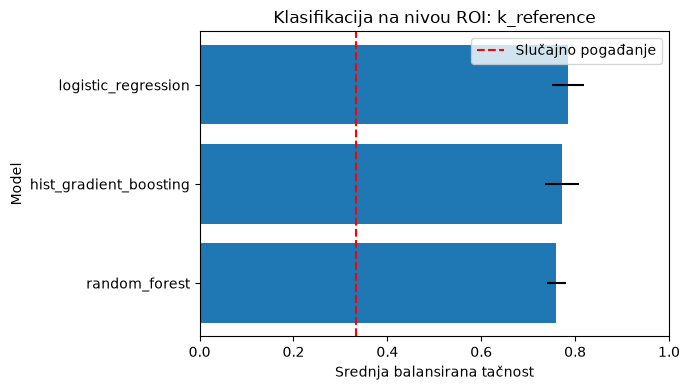

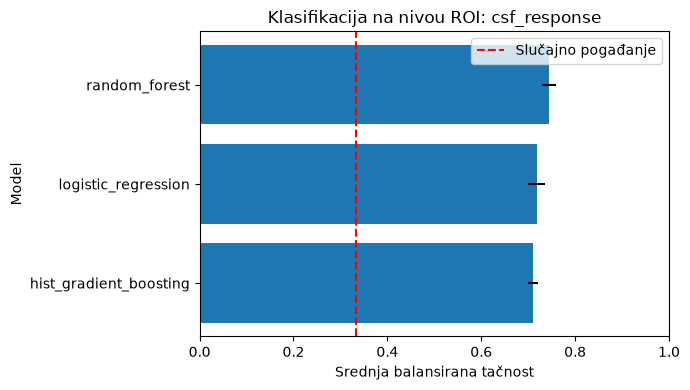

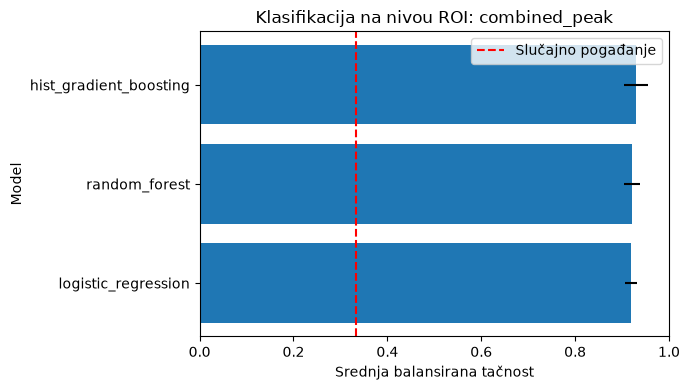

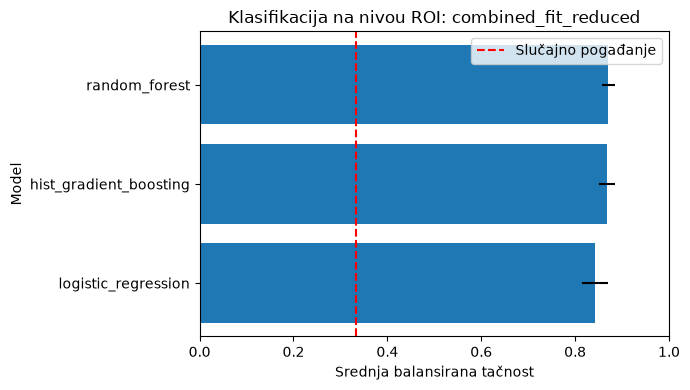

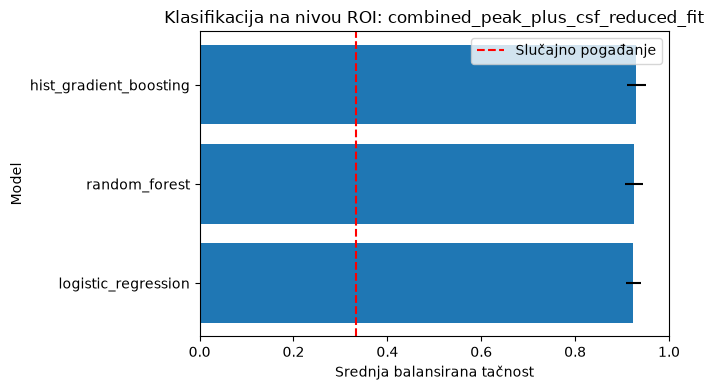

In [101]:
# Vizuelizacija glavnih dosadašnjih rezultata

# Performanse na nivou ROI
for feature_set_name in nonlinear_feature_sets:

    plot_data = (
        nonlinear_cv_results.loc[
            nonlinear_cv_results[
                "feature_set"
            ] == feature_set_name
        ]
        .sort_values(
            "test_balanced_accuracy_mean"
        )
    )

    plt.figure(figsize=(7, 4))

    plt.barh(
        plot_data["model"],
        plot_data[
            "test_balanced_accuracy_mean"
        ],
        xerr=plot_data[
            "test_balanced_accuracy_std"
        ],
    )

    plt.axvline(
        1 / 3,
        linestyle="--",
        color="red",
        label="Slučajno pogađanje",
    )

    plt.xlabel("Srednja balansirana tačnost")
    plt.ylabel("Model")
    plt.title(
        f"Klasifikacija na nivou ROI: "
        f"{feature_set_name}"
    )
    plt.xlim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

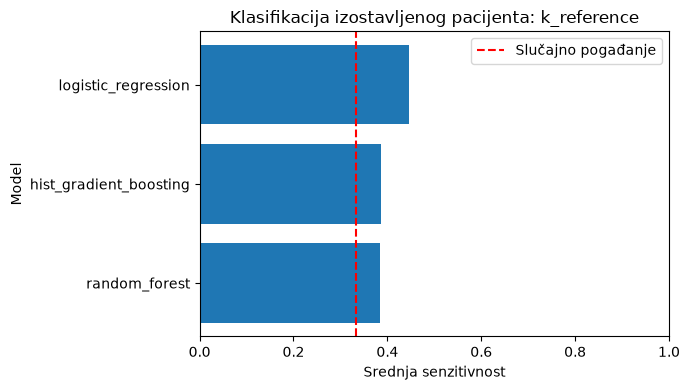

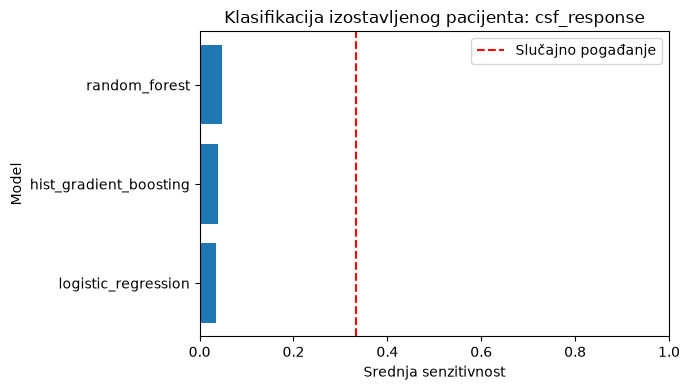

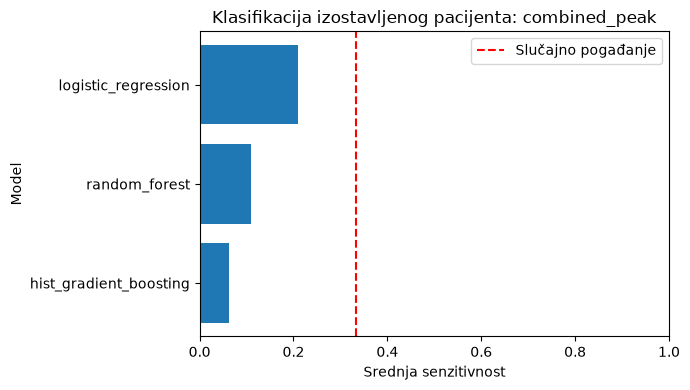

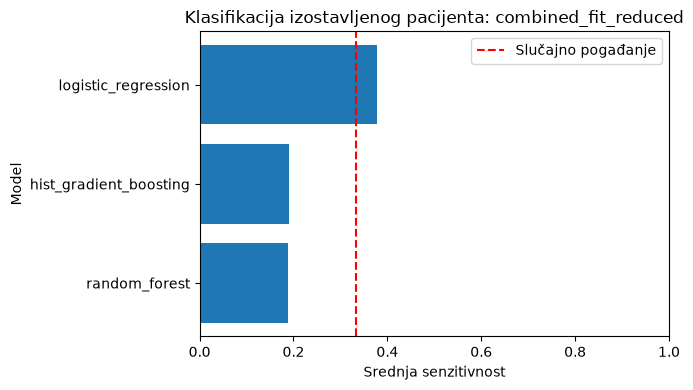

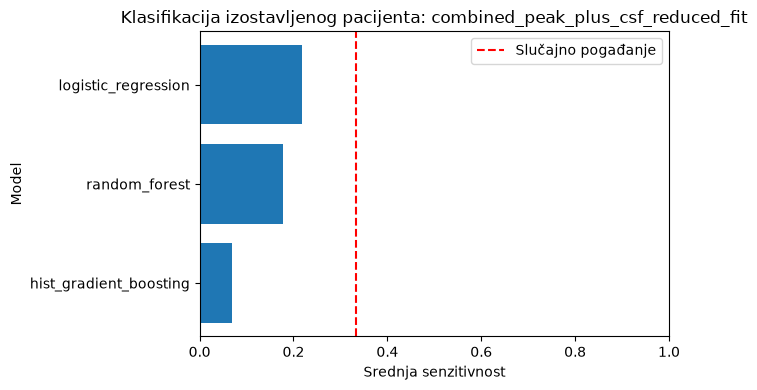

In [102]:
# Izostavljanje pacijenata
holdout_plot_data = (
    nonlinear_holdout_summary
    .sort_values("mean_patient_recall")
)

for feature_set_name in nonlinear_feature_sets:

    subset = holdout_plot_data.loc[
        holdout_plot_data[
            "feature_set"
        ] == feature_set_name
    ]

    plt.figure(figsize=(7, 4))

    plt.barh(
        subset["model"],
        subset["mean_patient_recall"],
    )

    plt.axvline(
        1 / 3,
        linestyle="--",
        color="red",
        label="Slučajno pogađanje",
    )

    plt.xlabel(
        "Srednja senzitivnost"
    )
    plt.ylabel("Model")
    plt.title(
        f"Klasifikacija izostavljenog pacijenta: {feature_set_name}"
    )
    plt.xlim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [103]:
# Čuvanje rezultata
NONLINEAR_RESULTS_DIR = MODELING_RESULTS_DIR / "Non-linear"

NONLINEAR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

nonlinear_cv_results.to_csv(
    NONLINEAR_RESULTS_DIR
    / "nonlinear_roi_cv_results.csv",
    index=False,
)

nonlinear_holdout_results.to_csv(
    NONLINEAR_RESULTS_DIR
    / "nonlinear_patient_holdout_results.csv",
    index=False,
)

nonlinear_holdout_summary.to_csv(
    NONLINEAR_RESULTS_DIR
    / "nonlinear_patient_holdout_summary.csv",
    index=False,
)

Završni deo analize odnosiće se na primenu **mRMR** tehnike. Uz pomoć nje pokušaćemo da utvrdimo da li od postojećih prediktora možemo odabrati manji (i manje redundantan) podskup koji uspeva da očuva prediktivnu moć.

Važno je imati u vidu da ova tehnika ne može prevazići glavni nedostatak trenutnog seta podataka (mali broj pojedinačnih pacijenata i eksperimenata). Njena primena kao rezultat može imati odabir osobina koje su veoma relevantne za predikciju klasa, ali samo zato što dobro razdvajaju postojeće eksperimente - ovo, naravno, ne podrazumeva nužno sposobnost prepoznavanja karakterističnog potpisa datog patološkog stanja.

## mRMR

In [104]:
# Definisanje glavnih atributa za selekciju
mrmr_core_candidate_features = [
    # Glavni skup osobina 
    *combined_peak_features,

    # Redukovane osobine K+ fita
    "k_ref_fit_valid_int",
    "k_ref_tau_fast",
    "k_ref_percent_fast",

    # Redukovane osobine CSF fita
    "csf_fit_valid_int",
    "csf_tau_fast",
    "csf_percent_fast",
]

In [105]:
# Eksplicitno označavanje diskretnih promenljivih;
# neophodno za Feature-engine MRMR implementaciju
mrmr_discrete_feature_names = {
    "csf_response_detected_int",
    "csf_multiple_responses_int",
    "k_ref_fit_valid_int",
    "csf_fit_valid_int",
}

mrmr_discrete_mask = [
    feature in mrmr_discrete_feature_names
    for feature in mrmr_core_candidate_features
]

In [106]:
# Provera diskretnih promenljivih
mrmr_feature_type_table = pd.DataFrame(
    {
        "feature": mrmr_core_candidate_features,
        "treated_as_discrete": (
            mrmr_discrete_mask
        ),
    }
)

mrmr_feature_type_table

,feature,treated_as_discrete
0,k_ref_amplitude,False
1,k_ref_half_width,False
2,k_ref_integral,False
3,csf_response_detected_int,True
4,csf_multiple_responses_int,True
5,csf_amplitude,False
6,csf_half_width,False
7,csf_integral,False
8,k_ref_fit_valid_int,True
9,k_ref_tau_fast,False


Diskretne promenljive su uspešno obeležene; sada ćemo definisati tok rada za MRMR u kombinaciji sa logističkom regresijom.

In [107]:
def make_mrmr_model_pipeline(
    max_features: int,
    base_model_factory = make_logistic_pipeline,
    method: str = "MIQ",
) -> Pipeline:
    """
    Ubacuje MRMR u postojeći pajplajn modela, ili 
    kreira novi pajplajn sa LR kao podrazumevan model.
    
    MRMR se fituje samo na trening podacima u okviru svakog
    CV skupa/pojedinačne iteracije prilikom izostavljanja pacijenata,
    posle imputacije a pre skaliranja ili klasifikacije.
    """
    if method not in {"MIQ", "MID"}:
        raise ValueError(
            "method mora biti 'MIQ' ili 'MID'."
        )

    if not 1 <= max_features <= len(
        mrmr_core_candidate_features
    ):
        raise ValueError(
            "max_features mora biti između 1 i "
            f"{len(mrmr_core_candidate_features)}."
        )

    base_pipeline = base_model_factory()

    required_steps = {
        "imputer",
        "classifier",
    }

    missing_steps = (
        required_steps
        - set(base_pipeline.named_steps)
    )

    if missing_steps:
        raise ValueError(
            "Osnovnom pajplajnu nedostaju koraci:"
            f"{sorted(missing_steps)}"
        )

    # Reprodukuje imputaciju originalnog modela
    imputer = clone(
        base_pipeline.named_steps["imputer"]
    )

    # Čuva kolone i ako neka nedostaje u trening podskupu
    imputer.set_params(
        add_indicator=False,
        keep_empty_features=True,
    )

    # Feature-engine MRMR zahteva imena kolona df-a
    imputer.set_output(
        transform="pandas"
    )

    selector = MRMR(
        method=method,
        max_features=max_features,
        discrete_features=mrmr_discrete_mask,
        n_neighbors=3,
        regression=False,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    pipeline_steps = [
        ("imputer", imputer),
        ("mrmr", selector),
    ]

    # LR podrazumeva skaliranje a nelinearni modeli nemaju;
    # Očuvati ga kad je prisutno
    if "scaler" in base_pipeline.named_steps:
        pipeline_steps.append(
            (
                "scaler",
                clone(
                    base_pipeline.named_steps[
                        "scaler"
                    ]
                ),
            )
        )

    pipeline_steps.append(
        (
            "classifier",
            clone(
                base_pipeline.named_steps[
                    "classifier"
                ]
            ),
        )
    )

    return Pipeline(
        steps=pipeline_steps
    )

Budući da `evaluate_feature_set()` funkcija kao argument očekuje drugu funkciju bez argumenata, a `make_mrmr_model_pipeline()` zahteva `max_features` argument, potrebna nam je pomoćna funkcija koja će vraćati funkciju koja je, kada se pozove, ekvivalentna `make_mrmr_model_pipeline()` sa odgovarajućim `max_features` argumentom.

In [108]:
def make_mrmr_model_factory(
    max_features: int,
    base_model_factory = make_logistic_pipeline,
    method: str = "MIQ",
):
    """
    Vraća 'factory' funkciju koja ne prima argumente
    za zadatu veličinu MRMR podskupa.

    Kao argumente prima i vrstu modela i MRMR metod;
    podrazumevano LR i MIQ.
    """
    def model_factory() -> Pipeline:
        return make_mrmr_model_pipeline(
            base_model_factory=base_model_factory,
            max_features=max_features,
            method=method,
        )

    return model_factory

Ova funkcija radi na sledeći način:

```
factory_n = make_mrmr_model_factory(
    max_features=n, 
    method="MIQ",
)
```
Pozivanje `factory_n()` je u tom slučaju ekvivalentno pozivanju:
```
make_mrmr_model_pipeline(
    max_features=n, 
    method="MIQ",
)
``` 
`factory_n` se onda može koristiti kao argument u `evaluate_feature_set()`.

In [109]:
# Definisanje veličine podskupova
mrmr_feature_counts = [
    4,
    6,
    8,
    10,
]

mRMR tehnika koristi nekoliko metoda za selekciju atributa. Za naš set podataka, posebno pogodne su korišćenje **MIQ** (*mutual-information quotent*) i **MID** (*mutual-information difference*) vrednosti. Obe ove metode su korisne kod setova podataka koji sadrže kontinualne vrednosti (poput amplitude i integrala), binarne vrednosti (poput prisustva odgovora i validnosti fita), nelinearne vrednosti i one sa neravnomernom raspodelom. Takođe, obe mere relevantnost (inormacija koja povezuje datu osobinu i klasu odgovora) i redundantnost (informacija koja povezuje osobinu kandidata za selekciju i prethodno odabrane osobine). Ono što se razlikuje jeste način na koji se ove vrednosti dobijaju.

**MIQ** vrednost predstavlja količnik relevantnosti i redundantnosti. U našem setu podataka, visoku MIQ vrednost imaće one osobine koje imaju izraženu vezu sa klasom bolesti, pri čemu je informacija koju pružaju svojstvena samo (ili većinom) njima. Činjenica da je redundantnost u imeniocu znači da će ova vrednost biti izrazito visoka ako je redundantnost date osobine niska - može čak biti i beskonačna (zbog čega se mogu javljati `RuntimeWarning` upozorenja prilikom pokretanja modela sa mRMR). 

**MID** vrednost predstavlja razliku relevantnosti i redundantnosti. Razlika u odnosu na MIQ vrednost je u tome što se u ovom slučaju favorizuju one osobine čija je relevantnost visoka više od onih čija je redundantnost niska.

### MIQ

In [110]:
# Kreiranje MRMR 'factory' funkcija
mrmr_model_factories = {
    n_features: make_mrmr_model_factory(
        max_features=n_features
    )
    for n_features in mrmr_feature_counts
}

# Utišavanje 'divide by zero' upozorenja
warnings.filterwarnings(
    "ignore",
    message=(
        "divide by zero encountered in divide"
    ),
    category=RuntimeWarning,
)

Sada kad imamo odgovarajuće funkcije za generisanje modela, u svrhu evaluacije modela sa atributima odabranim putem MRMR, prvo ćemo testirati kako model funkcioniše sa `combined_peak` skupom osobina (koji posmatramo kao optimalan/referentan), kao i sa svim osobinama koje smo definisali na početku (`mrmr_core_candidate_features`).

In [111]:
# Bazna linija - combined_peak
combined_peak_mrmr_baseline = (
    evaluate_feature_set(
        model_name="logistic_regression",
        model_factory=make_logistic_pipeline,
        feature_set_name="combined_peak",
        features=combined_peak_features,
    )
)

combined_peak_mrmr_baseline[
    "analysis_variant"
] = "combined_peak"

combined_peak_mrmr_baseline[
    "n_candidate_features"
] = len(combined_peak_features)

combined_peak_mrmr_baseline[
    "n_selected_features"
] = len(combined_peak_features)

In [112]:
# Bazna linija - svih 14 osobina
core_all_mrmr_baseline = (
    evaluate_feature_set(
        model_name="logistic_regression",
        model_factory=make_logistic_pipeline,
        feature_set_name="mrmr_core_candidates",
        features=mrmr_core_candidate_features,
    )
)

core_all_mrmr_baseline[
    "analysis_variant"
] = "core_all_no_selection"

core_all_mrmr_baseline[
    "n_candidate_features"
] = len(mrmr_core_candidate_features)

core_all_mrmr_baseline[
    "n_selected_features"
] = len(mrmr_core_candidate_features)

In [113]:
# Evaluacija MRMR modela
mrmr_roi_rows = [
    combined_peak_mrmr_baseline,
    core_all_mrmr_baseline,
]

for n_selected, model_factory in (
    mrmr_model_factories.items()
):
    result = evaluate_feature_set(
        model_name=f"mrmr_lr_{n_selected}",
        model_factory=model_factory,
        feature_set_name=(
            "mrmr_core_candidates"
        ),
        features=mrmr_core_candidate_features,
    )

    result["analysis_variant"] = (
        f"mrmr_{n_selected}"
    )

    result["n_candidate_features"] = len(
        mrmr_core_candidate_features
    )

    result["n_selected_features"] = (
        n_selected
    )

    mrmr_roi_rows.append(result)

# Kombinovanje rezultata
mrmr_roi_results = pd.DataFrame(
    mrmr_roi_rows
)

# Razlika u trening i test performansama
mrmr_roi_results[
    "balanced_accuracy_gap"
] = (
    mrmr_roi_results[
        "train_balanced_accuracy_mean"
    ]
    - mrmr_roi_results[
        "test_balanced_accuracy_mean"
    ]
)

In [114]:
# Prikaz rezultata
mrmr_roi_results_display = (
    mrmr_roi_results[
        [
            "analysis_variant",
            "n_candidate_features",
            "n_selected_features",
            "test_accuracy_mean",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_macro_mean",
            "test_f1_macro_std",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .sort_values(
        "n_selected_features"
    )
    .reset_index(drop=True)
)

mrmr_roi_results_display.round(3)

,analysis_variant,n_candidate_features,n_selected_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean,balanced_accuracy_gap
0,mrmr_4,14,4,0.847,0.857,0.027,0.837,0.023,0.864,0.007
1,mrmr_6,14,6,0.856,0.867,0.016,0.852,0.020,0.873,0.006
2,combined_peak,8,8,0.911,0.920,0.013,0.904,0.012,0.926,0.006
3,mrmr_8,14,8,0.852,0.862,0.025,0.846,0.022,0.875,0.013
4,mrmr_10,14,10,0.865,0.875,0.018,0.862,0.020,0.889,0.013
5,core_all_no_selection,14,14,0.909,0.918,0.012,0.902,0.011,0.932,0.014


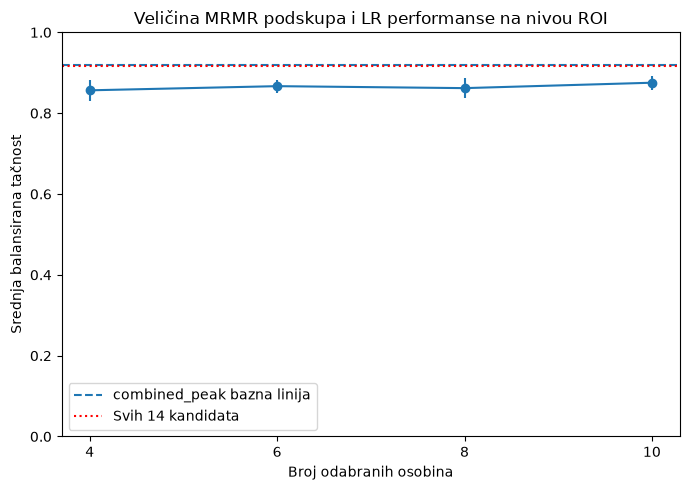

In [115]:
# Vizuelizacija
mrmr_plot_data = (
    mrmr_roi_results.loc[
        mrmr_roi_results[
            "analysis_variant"
        ].str.startswith("mrmr_")
    ]
    .sort_values("n_selected_features")
)

plt.figure(figsize=(7, 5))

plt.errorbar(
    mrmr_plot_data["n_selected_features"],
    mrmr_plot_data[
        "test_balanced_accuracy_mean"
    ],
    yerr=mrmr_plot_data[
        "test_balanced_accuracy_std"
    ],
    marker="o",
)

plt.axhline(
    combined_peak_mrmr_baseline[
        "test_balanced_accuracy_mean"
    ],
    linestyle="--",
    label="combined_peak bazna linija",
)

plt.axhline(
    core_all_mrmr_baseline[
        "test_balanced_accuracy_mean"
    ],
    linestyle=":",
    color="red",
    label="Svih 14 kandidata",
)

plt.xlabel("Broj odabranih osobina")
plt.ylabel("Srednja balansirana tačnost")
plt.title("Veličina MRMR podskupa i LR performanse na nivou ROI")
plt.xticks(mrmr_feature_counts)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

Vidimo da mRMR ne uspeva da reprodukuje jake performanse na nivou ROI koje pruža referentni `combined_peak` skup osobina. Najbolji rezultat, sa 10 od 14 kandidata, pruža vrednost balansirane tačnosti od `0.875` naspram `0.920` u slučaju `combined_peak`.

Ono što takođe možemo reći jeste da ovaj rezultat nije izazvan prekomernim fitovanjem; razlike u trening i test performansama za logističke mRMR modele je u opsegu `0.006 - 0.013`.

Sada ćemo preći na ispitivanje performansi prilikom izostavljanja pacijenata.

In [116]:
# Varijante sa combined_peak i svim osobinama
mrmr_holdout_runs = [
    {
        "analysis_variant": "combined_peak",
        "model_name": "logistic_regression",
        "model_factory": make_logistic_pipeline,
        "feature_sets": {
            "combined_peak": combined_peak_features,
        },
    },
    {
        "analysis_variant": (
            "core_all_no_selection"
        ),
        "model_name": "logistic_regression",
        "model_factory": make_logistic_pipeline,
        "feature_sets": {
            "mrmr_core_candidates": (
                mrmr_core_candidate_features
            ),
        },
    },
]

In [117]:
# Dodavanje MRMR modela
for n_selected, model_factory in (
    mrmr_model_factories.items()
):
    mrmr_holdout_runs.append(
        {
            "analysis_variant": (
                f"mrmr_{n_selected}"
            ),
            "model_name": (
                f"mrmr_lr_{n_selected}"
            ),
            "model_factory": model_factory,
            "feature_sets": {
                "mrmr_core_candidates": (
                    mrmr_core_candidate_features
                ),
            },
        }
    )

In [118]:
# Pokretanje svih varijanti modela
mrmr_holdout_long_tables = []

for run_configuration in mrmr_holdout_runs:
    (
        holdout_long,
        _,
        _,
    ) = run_patient_holdout_analysis(
        feature_set_dictionary=(
            run_configuration["feature_sets"]
        ),
        model_factory=(
            run_configuration["model_factory"]
        ),
        model_name=(
            run_configuration["model_name"]
        ),
    )

    holdout_long["analysis_variant"] = (
        run_configuration[
            "analysis_variant"
        ]
    )

    mrmr_holdout_long_tables.append(
        holdout_long
    )

# Kombinovanje rezultata
mrmr_holdout_results = pd.concat(
    mrmr_holdout_long_tables,
    ignore_index=True,
)

In [119]:
# Prikaz rezultata po pacijentu
mrmr_holdout_pivot = (
    mrmr_holdout_results
    .pivot(
        index="held_out_patient",
        columns="analysis_variant",
        values="correct_class_recall",
    )
)

mrmr_holdout_pivot.round(3)

analysis_variant,combined_peak,core_all_no_selection,mrmr_10,mrmr_4,mrmr_6,mrmr_8
held_out_patient,,,,,,
10a,0.061,0.048,0.061,0.204,0.478,0.030
10b,0.184,0.114,0.019,0.511,0.559,0.022
3,0.215,0.221,0.147,0.067,0.055,0.037
4,0.377,0.321,0.283,0.085,0.189,0.245


In [120]:
# Sažetak rezultata
mrmr_holdout_summary = (
    mrmr_holdout_results
    .groupby("analysis_variant")
    .agg(
        mean_patient_recall=(
            "correct_class_recall",
            "mean",
        ),
        std_patient_recall=(
            "correct_class_recall",
            "std",
        ),
        minimum_patient_recall=(
            "correct_class_recall",
            "min",
        ),
        maximum_patient_recall=(
            "correct_class_recall",
            "max",
        ),
    )
    .reset_index()
)

# Dodaje broj osobina
mrmr_selected_count_lookup = {
    "combined_peak": len(
        combined_peak_features
    ),
    "core_all_no_selection": len(
        mrmr_core_candidate_features
    ),
    **{
        f"mrmr_{n_features}": n_features
        for n_features in mrmr_feature_counts
    },
}

mrmr_holdout_summary[
    "n_selected_features"
] = (
    mrmr_holdout_summary[
        "analysis_variant"
    ]
    .map(mrmr_selected_count_lookup)
)

In [121]:
# Prikaz rezultata
mrmr_holdout_summary = (
    mrmr_holdout_summary
    .sort_values("n_selected_features")
    .reset_index(drop=True)
)

mrmr_holdout_summary.round(3)

,analysis_variant,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall,n_selected_features
0,mrmr_4,0.217,0.205,0.067,0.511,4
1,mrmr_6,0.320,0.238,0.055,0.559,6
2,mrmr_8,0.084,0.108,0.022,0.245,8
3,combined_peak,0.209,0.130,0.061,0.377,8
4,mrmr_10,0.128,0.117,0.019,0.283,10
5,core_all_no_selection,0.176,0.120,0.048,0.321,14


Interesantno, `mrmr_4` pokazuje uporedive performanse kao `combined_peak`, dok `mrmr_6` pokazuje znatno bolji rezultat - `0.320` naspram `0.209` za `combined_peak`. Međutim, ovaj rezultat nije ujednačen među različitim pacijentima, i relativno visoka vrednost je posledica senzitivnosti u iznosu od `0.478` i `0.559` za pacijente `10a` i `10b`, redom. Ono što je naročito interesantno je da model sa ovim osobinama pokazuje znatno veću sposobnost isprave predikcije klase pacijenta `10b` na osnovu pacijenta `10a` od većine dosadašnjih modela; međutim, sveukupan rezultat ukazuje na to da je teško govoriti o univerzalnom, biološki relevantnom prediktivnom modelu. `mrmr_6` predviđa SMA sa senzitivnošću `0.519`, dok je u slučaju `combined_peak` ta vrednost `0.123`. Međutim, kad je u pitanju ALS, vrednosti su `0.122` i `0.296` za `combined_peak` i `mrmr_6`.

Nije dovoljno samo ispitivati performanse modela sa datim brojem odabranih osobina; važno je i proveriti da li MRMR pouzdano bira istih 4, 6, itd. prediktora kada se vrši treniranje na različitim podskupovima prediktora.

In [122]:
# Ispitivanje stabilnosti selekcije osobina
X_mrmr = df[mrmr_core_candidate_features]

mrmr_roi_selection_rows = []

for n_selected, model_factory in (
    mrmr_model_factories.items()
):
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        roi_cv.split(X_mrmr, y),
        start=1,
    ):
        model = model_factory()

        model.fit(
            X_mrmr.iloc[train_indices],
            y.iloc[train_indices],
        )

        selected_features = list(
            model
            .named_steps["mrmr"]
            .get_feature_names_out()
        )

        assert len(selected_features) == n_selected

        for feature in selected_features:
            mrmr_roi_selection_rows.append(
                {
                    "n_selected_features": (
                        n_selected
                    ),
                    "fold": fold_number,
                    "feature": feature,
                }
            )

# Kombinovanje rezultata
mrmr_roi_selection_long = pd.DataFrame(
    mrmr_roi_selection_rows
)

In [123]:
# Odabrane osobine za svaki podskup
mrmr_roi_selected_by_fold = (
    mrmr_roi_selection_long
    .groupby(
        [
            "n_selected_features",
            "fold",
        ]
    )["feature"]
    .agg(
        lambda values: ", ".join(values)
    )
    .reset_index(
        name="selected_features"
    )
)

pd.set_option('display.max_colwidth', None) # Omogućava prikaz cele Pandas kolone

mrmr_roi_selected_by_fold

,n_selected_features,fold,selected_features
0,4,1,"k_ref_half_width, csf_multiple_responses_int, csf_tau_fast, csf_percent_fast"
1,4,2,"k_ref_half_width, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast"
2,4,3,"k_ref_half_width, k_ref_integral, k_ref_percent_fast, csf_tau_fast"
3,4,4,"k_ref_half_width, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast"
4,4,5,"k_ref_half_width, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast"
5,6,1,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
6,6,2,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
7,6,3,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
8,6,4,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
9,6,5,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"


In [124]:
# Ispitivanje učestalosti selekcije datih osobina za datu veličinu skupa

# Kombinacije pojedinačnih osobina i veličine skupa
roi_frequency_index = (
    pd.MultiIndex.from_product(
        [
            mrmr_feature_counts,
            mrmr_core_candidate_features,
        ],
        names=[
            "n_selected_features",
            "feature",
        ],
    )
)

mrmr_roi_selection_frequency = (
    mrmr_roi_selection_long
    .groupby(
        [
            "n_selected_features",
            "feature",
        ]
    )
    .size()
    .reindex(
        roi_frequency_index,
        fill_value=0,
    )
    .rename("n_folds_selected")
    .reset_index()
)

# Računanje učestalost odabira
n_roi_folds = roi_cv.get_n_splits(
    X_mrmr,
    y,
)

mrmr_roi_selection_frequency[
    "selection_frequency"
] = (
    mrmr_roi_selection_frequency[
        "n_folds_selected"
    ]
    / n_roi_folds
)

In [125]:
# Prikaz rezultata
mrmr_roi_selection_frequency_pivot = (
    mrmr_roi_selection_frequency
    .pivot(
        index="feature",
        columns="n_selected_features",
        values="selection_frequency",
    )
    .sort_values(
        by=mrmr_feature_counts,
        ascending=False,
    )
)

mrmr_roi_selection_frequency_pivot.round(2)

n_selected_features,4,6,8,10
feature,,,,
csf_tau_fast,1.0,1.0,1.0,1.0
k_ref_half_width,1.0,1.0,1.0,1.0
csf_multiple_responses_int,0.8,1.0,1.0,1.0
k_ref_percent_fast,0.8,1.0,1.0,1.0
csf_percent_fast,0.2,1.0,1.0,1.0
k_ref_integral,0.2,1.0,1.0,1.0
csf_integral,0.0,0.0,1.0,1.0
k_ref_tau_fast,0.0,0.0,1.0,1.0
csf_half_width,0.0,0.0,0.0,1.0


Interesantno, mRMR u potpunosti favorizuje određeni skup osobina za sve veličine skupova osim za `mrmr_4`, mada i u tom slučaju perturbacije nisu izražene. Ovo u načelu nije previše iznenađujuće ako znamo da svaki ROI fold sadrži ROI iz svih šest eksperimenata.

Sada ćemo proveriti da li se odabir osobina za datu veličinu skupa u zavisnosti od pacijenta čiji se ROI izostavljaju iz trening podataka.

In [126]:
# Ispitivanje stabilnosti selekcije osobina
mrmr_patient_selection_rows = []

for n_selected, model_factory in (
    mrmr_model_factories.items()
):
    for held_out_patient in (
        eligible_held_out_patients
    ):
        test_mask = (
            patient_id_as_string
            == held_out_patient
        )
        train_mask = ~test_mask

        X_train = df.loc[
            train_mask,
            mrmr_core_candidate_features,
        ]

        y_train = y.loc[train_mask]

        model = model_factory()

        model.fit(
            X_train,
            y_train,
        )

        selected_features = list(
            model
            .named_steps["mrmr"]
            .get_feature_names_out()
        )

        assert len(selected_features) == n_selected

        for feature in selected_features:
            mrmr_patient_selection_rows.append(
                {
                    "n_selected_features": (
                        n_selected
                    ),
                    "held_out_patient": (
                        held_out_patient
                    ),
                    "feature": feature,
                }
            )

# Kombinovanje rezultata
mrmr_patient_selection_long = pd.DataFrame(
    mrmr_patient_selection_rows
)

In [127]:
# Odabrane osobine za svakog izostavljenog pacijenta
mrmr_patient_selected_by_holdout = (
    mrmr_patient_selection_long
    .groupby(
        [
            "n_selected_features",
            "held_out_patient",
        ]
    )["feature"]
    .agg(
        lambda values: ", ".join(values)
    )
    .reset_index(
        name="selected_features"
    )
)

mrmr_patient_selected_by_holdout

,n_selected_features,held_out_patient,selected_features
0,4,10a,"k_ref_integral, csf_multiple_responses_int, csf_tau_fast, csf_percent_fast"
1,4,10b,"k_ref_amplitude, k_ref_half_width, csf_multiple_responses_int, csf_tau_fast"
2,4,3,"k_ref_amplitude, k_ref_half_width, csf_multiple_responses_int, csf_tau_fast"
3,4,4,"k_ref_integral, k_ref_fit_valid_int, csf_tau_fast, csf_percent_fast"
4,6,10a,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
5,6,10b,"k_ref_amplitude, k_ref_half_width, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
6,6,3,"k_ref_amplitude, k_ref_half_width, csf_multiple_responses_int, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
7,6,4,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, k_ref_fit_valid_int, csf_tau_fast, csf_percent_fast"
8,8,10a,"k_ref_half_width, k_ref_integral, csf_multiple_responses_int, csf_amplitude, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
9,8,10b,"k_ref_amplitude, k_ref_half_width, k_ref_integral, csf_multiple_responses_int, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"


In [128]:
# Ispitivanje učestalosti selekcije datih osobina
# za datu veličinu skupa i izostavljenog pacijenta
patient_frequency_index = (
    pd.MultiIndex.from_product(
        [
            mrmr_feature_counts,
            mrmr_core_candidate_features,
        ],
        names=[
            "n_selected_features",
            "feature",
        ],
    )
)

mrmr_patient_selection_frequency = (
    mrmr_patient_selection_long
    .groupby(
        [
            "n_selected_features",
            "feature",
        ]
    )
    .size()
    .reindex(
        patient_frequency_index,
        fill_value=0,
    )
    .rename("n_holdouts_selected")
    .reset_index()
)

# Računanje učestalosti
mrmr_patient_selection_frequency[
    "selection_frequency"
] = (
    mrmr_patient_selection_frequency[
        "n_holdouts_selected"
    ]
    / len(eligible_held_out_patients)
)

In [129]:
# Prikaz rezultata
mrmr_patient_selection_frequency_pivot = (
    mrmr_patient_selection_frequency
    .pivot(
        index="feature",
        columns="n_selected_features",
        values="selection_frequency",
    )
    .sort_values(
        by=mrmr_feature_counts,
        ascending=False,
    )
)

mrmr_patient_selection_frequency_pivot.round(2)

n_selected_features,4,6,8,10
feature,,,,
csf_tau_fast,1.00,1.00,1.00,1.00
csf_multiple_responses_int,0.75,1.00,1.00,1.00
csf_percent_fast,0.50,1.00,1.00,1.00
k_ref_half_width,0.50,1.00,1.00,1.00
k_ref_integral,0.50,0.50,0.75,1.00
k_ref_amplitude,0.50,0.50,0.50,0.75
k_ref_fit_valid_int,0.25,0.25,0.25,0.25
k_ref_percent_fast,0.00,0.75,1.00,1.00
csf_integral,0.00,0.00,1.00,1.00


U ovom slučaju, prisutne su primetne varijacije u odabiru osobina u zavisnosti od pacijenta za kog se vrši predikcija, mada su neke osobine i dalje gotovo univerzalno favorizovane u zavisnosti od veličine skupa. Na primer, u slučaju `mrmr_6` koji se dosad pokazao kao najbolji model u predikciji izostavljenog pacijenta, vidimo relativno stabilno "jezgro" od 4 osobine, dok druge dve ipak variraju u zavisnosti od pacijenta.

U celosti, dosadašnja analiza pomoću mRMR pokazuje da su uglavnom favorizovane sledeće osobine:
- `k_ref_integral`
- `k_ref_half_width`
- `csf_tau_fast`
- `csf_percent_fast`
- `k_ref_percent_fast`
- `csf_multiple_responses_int`

Dok se uglavnom odbacuju:
- `csf_amplitude`
- `csf_fit_valid_int`
- `csf_response_detected_int`

Ovo je u skladu sa principom odbacivanja redundantnih prediktora. `csf_response_detected_int` i `csf_fit_valid_int` su međusobno redundantni, a imaju slabu prediktivnu vrednost. `csf_amplitude` deli informaciju sa `csf_integral` i parametrima fita. Naravno, važno je imati na umu i činjenicu da favorizovanje određenog prediktora ne znači da je on dobar biomarker, već isključivo da je koristan u razlikovanju eksperimenata u okviru postojećeg seta podataka, pri čemu nosi informaciju koja je svojstvena njemu.

In [130]:
# Čuvanje rezultata
MRMR_RESULTS_DIR = MODELING_RESULTS_DIR / "mRMR"

MRMR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

mrmr_roi_results.to_csv(
    MRMR_RESULTS_DIR
    / "miq_roi_cv_results.csv",
    index=False,
)

mrmr_holdout_results.to_csv(
    MRMR_RESULTS_DIR
    / "miq_patient_holdout_results.csv",
    index=False,
)

mrmr_roi_selection_long.to_csv(
    MRMR_RESULTS_DIR
    / "miq_roi_selection_by_fold.csv",
    index=False,
)

mrmr_patient_selection_long.to_csv(
    MRMR_RESULTS_DIR
    / "miq_selection_by_patient_holdout.csv",
    index=False,
)

Kako bismo proverili na koji način algoritam koji koristi mRMR metoda utiče na odabir osobina, sada ćemo primeniti MID metodu selekcije osobina.

### MID

In [131]:
# Kreiranje 'factory' funkcija
mid_model_factories = {
    n_features: make_mrmr_model_factory(
        max_features=n_features,
        method="MID",
    )
    for n_features in mrmr_feature_counts
}

In [132]:
# Modeli na nivou ROI
mid_roi_rows = []

for n_selected, model_factory in (
    mid_model_factories.items()
):
    result = evaluate_feature_set(
        model_name=f"mid_lr_{n_selected}",
        model_factory=model_factory,
        feature_set_name="mrmr_core_candidates",
        features=mrmr_core_candidate_features,
    )

    result["mrmr_method"] = "MID"

    result["analysis_variant"] = (
        f"mid_{n_selected}"
    )

    result["n_candidate_features"] = len(
        mrmr_core_candidate_features
    )

    result["n_selected_features"] = (
        n_selected
    )

    mid_roi_rows.append(result)

# Kombinovanje rezultata
mid_roi_results = pd.DataFrame(
    mid_roi_rows
)

# Razlika između test i trening performansi
mid_roi_results[
    "balanced_accuracy_gap"
] = (
    mid_roi_results[
        "train_balanced_accuracy_mean"
    ]
    - mid_roi_results[
        "test_balanced_accuracy_mean"
    ]
)

In [133]:
# Prikaz rezultata
mid_roi_results_display = (
    mid_roi_results[
        [
            "analysis_variant",
            "n_candidate_features",
            "n_selected_features",
            "test_accuracy_mean",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_macro_mean",
            "test_f1_macro_std",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .sort_values("n_selected_features")
    .reset_index(drop=True)
)

mid_roi_results_display.round(3)

,analysis_variant,n_candidate_features,n_selected_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean,balanced_accuracy_gap
0,mid_4,14,4,0.851,0.859,0.024,0.843,0.019,0.870,0.010
1,mid_6,14,6,0.848,0.859,0.016,0.842,0.018,0.869,0.010
2,mid_8,14,8,0.852,0.862,0.025,0.846,0.022,0.875,0.013
3,mid_10,14,10,0.865,0.877,0.020,0.862,0.020,0.887,0.010


In [134]:
# Ekstrakcija MIQ rezultata za poređenje
miq_roi_for_comparison = (
    mrmr_roi_results.loc[
        mrmr_roi_results[
            "analysis_variant"
        ].isin(
            [
                f"mrmr_{n_features}"
                for n_features
                in mrmr_feature_counts
            ]
        )
    ]
    .copy()
)

miq_roi_for_comparison[
    "mrmr_method"
] = "MIQ"

# MIQ vrednosti za poređenje
miq_roi_for_comparison[
    "subset_size"
] = (
    miq_roi_for_comparison[
        "n_selected_features"
    ]
)

# MID vrednosti za poređenje
mid_roi_for_comparison = (
    mid_roi_results.copy()
)

mid_roi_for_comparison[
    "subset_size"
] = (
    mid_roi_for_comparison[
        "n_selected_features"
    ]
)

# Kombinovanje vrednosti
mrmr_method_roi_comparison = pd.concat(
    [
        miq_roi_for_comparison,
        mid_roi_for_comparison,
    ],
    ignore_index=True,
)

In [135]:
# Prikaz poređenja
mrmr_method_roi_comparison_display = (
    mrmr_method_roi_comparison[
        [
            "mrmr_method",
            "subset_size",
            "test_accuracy_mean",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_macro_mean",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .sort_values(
        [
            "subset_size",
            "mrmr_method",
        ]
    )
    .reset_index(drop=True)
)

mrmr_method_roi_comparison_display.round(3)

,mrmr_method,subset_size,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,train_balanced_accuracy_mean,balanced_accuracy_gap
0,MID,4,0.851,0.859,0.024,0.843,0.870,0.010
1,MIQ,4,0.847,0.857,0.027,0.837,0.864,0.007
2,MID,6,0.848,0.859,0.016,0.842,0.869,0.010
3,MIQ,6,0.856,0.867,0.016,0.852,0.873,0.006
4,MID,8,0.852,0.862,0.025,0.846,0.875,0.013
5,MIQ,8,0.852,0.862,0.025,0.846,0.875,0.013
6,MID,10,0.865,0.877,0.020,0.862,0.887,0.010
7,MIQ,10,0.865,0.875,0.018,0.862,0.889,0.013


In [136]:
# Balansirana tačnost po veličini podskupa za MIQ i MID
mrmr_method_roi_pivot = (
    mrmr_method_roi_comparison
    .pivot(
        index="subset_size",
        columns="mrmr_method",
        values="test_balanced_accuracy_mean",
    )
)

mrmr_method_roi_pivot.round(3)

mrmr_method,MID,MIQ
subset_size,,
4,0.859,0.857
6,0.859,0.867
8,0.862,0.862
10,0.877,0.875


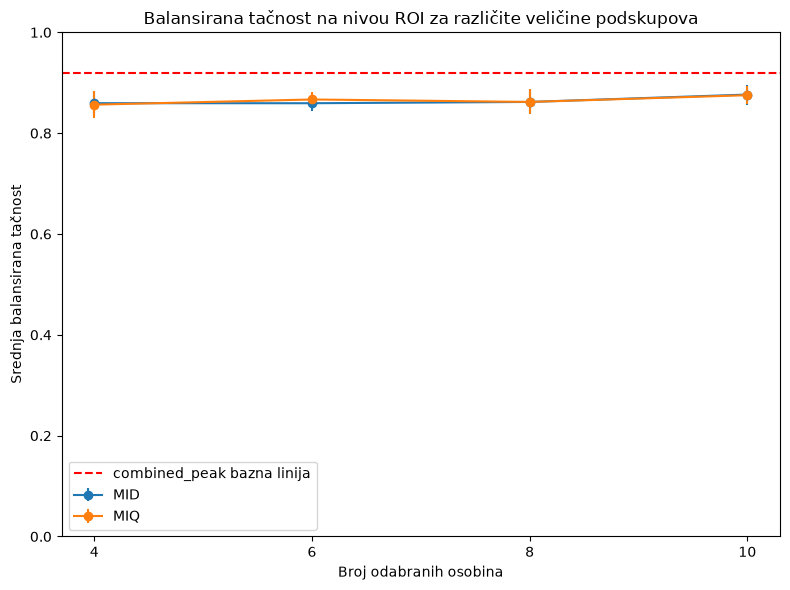

In [137]:
# Vizuelizacija
fig, ax = plt.subplots(figsize=(8, 6))

for method_name, method_data in (
    mrmr_method_roi_comparison
    .groupby("mrmr_method")
):
    method_data = method_data.sort_values(
        "subset_size"
    )

    ax.errorbar(
        method_data["subset_size"],
        method_data[
            "test_balanced_accuracy_mean"
        ],
        yerr=method_data[
            "test_balanced_accuracy_std"
        ],
        marker="o",
        label=method_name,
    )

ax.axhline(
    combined_peak_mrmr_baseline[
        "test_balanced_accuracy_mean"
    ],
    linestyle="--",
    color="red",
    label="combined_peak bazna linija",
)

ax.set_xlabel("Broj odabranih osobina")
ax.set_ylabel("Srednja balansirana tačnost")
ax.set_title(
    "Balansirana tačnost na nivou ROI za različite veličine podskupova"
)
ax.set_xticks(mrmr_feature_counts)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

save_figure(
    fig,
    "mRMR_ROI_performance_by_set_size",
)

plt.show()

Razlike u MID i MIQ u klasifikaciji na nivou ROI su praktično nepostojeće. Obe metode pokazuju:
- male razlike u trening i test performansi;
- neznatan porast performansi sa više prediktora;
- slabije performanse od `combined_peak` i svih 14 kandidata prediktora bez selekcije.

Sada ćemo pogledati kako se MID metoda ponaša u klasifikaciji izostavljenog pacijenta.

In [138]:
# Izostavljanje po jednog pacijenta
mid_holdout_long_tables = []

for n_selected, model_factory in (
    mid_model_factories.items()
):
    analysis_variant = f"mid_{n_selected}"

    (
        holdout_long,
        _,
        _,
    ) = run_patient_holdout_analysis(
        feature_set_dictionary={
            analysis_variant: (
                mrmr_core_candidate_features
            ),
        },
        model_factory=model_factory,
        model_name=f"mid_lr_{n_selected}",
    )

    holdout_long[
        "analysis_variant"
    ] = analysis_variant

    holdout_long[
        "mrmr_method"
    ] = "MID"

    holdout_long[
        "n_selected_features"
    ] = n_selected

    mid_holdout_long_tables.append(
        holdout_long
    )

# Kombinovanje rezultata
mid_holdout_results = pd.concat(
    mid_holdout_long_tables,
    ignore_index=True,
)

In [139]:
# Prikaz rezultata po pacijentu
mid_holdout_pivot = (
    mid_holdout_results
    .pivot(
        index="held_out_patient",
        columns="analysis_variant",
        values="correct_class_recall",
    )
)

mid_holdout_pivot.round(3)

analysis_variant,mid_10,mid_4,mid_6,mid_8
held_out_patient,,,,
10a,0.057,0.474,0.035,0.030
10b,0.019,0.606,0.013,0.013
3,0.043,0.258,0.043,0.037
4,0.283,0.170,0.255,0.226


In [140]:
# Sažeti rezultati za MID
mid_holdout_summary = (
    mid_holdout_results
    .groupby(
        [
            "analysis_variant",
            "n_selected_features",
        ]
    )
    .agg(
        mean_patient_recall=(
            "correct_class_recall",
            "mean",
        ),
        std_patient_recall=(
            "correct_class_recall",
            "std",
        ),
        minimum_patient_recall=(
            "correct_class_recall",
            "min",
        ),
        maximum_patient_recall=(
            "correct_class_recall",
            "max",
        ),
    )
    .reset_index()
    .sort_values("n_selected_features")
    .reset_index(drop=True)
)

mid_holdout_summary.round(3)

,analysis_variant,n_selected_features,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,mid_4,4,0.377,0.199,0.170,0.606
1,mid_6,6,0.086,0.113,0.013,0.255
2,mid_8,8,0.077,0.100,0.013,0.226
3,mid_10,10,0.100,0.123,0.019,0.283


Sada ćemo izvršiti poređenje rezultata MIQ i MID po pitanju predviđanja klase izostavljenog pacijenta.

In [141]:
# MIQ rezultati
miq_holdout_for_comparison = (
    mrmr_holdout_results.loc[
        mrmr_holdout_results[
            "analysis_variant"
        ].isin(
            [
                f"mrmr_{n_features}"
                for n_features
                in mrmr_feature_counts
            ]
        )
    ]
    .copy()
)

# Dodavanje kolona sa metodom i veličinom podskupa u df
miq_holdout_for_comparison[
    "mrmr_method"
] = "MIQ"

miq_holdout_for_comparison[
    "n_selected_features"
] = (
    miq_holdout_for_comparison[
        "analysis_variant"
    ]
    .str.replace(
        "mrmr_",
        "",
        regex=False,
    )
    .astype(int)
)

# Spajanje sa MID
mrmr_method_holdout_results = pd.concat(
    [
        miq_holdout_for_comparison,
        mid_holdout_results,
    ],
    ignore_index=True,
)

In [142]:
# Prikaz poređenja
mrmr_method_holdout_pivot = (
    mrmr_method_holdout_results
    .pivot_table(
        index="held_out_patient",
        columns=[
            "mrmr_method",
            "n_selected_features",
        ],
        values="correct_class_recall",
    )
)

mrmr_method_holdout_pivot.round(3)

mrmr_method            MID                         MIQ                     
n_selected_features     4      6      8      10     4      6      8      10
held_out_patient                                                           
10a                  0.474  0.035  0.030  0.057  0.204  0.478  0.030  0.061
10b                  0.606  0.013  0.013  0.019  0.511  0.559  0.022  0.019
3                    0.258  0.043  0.037  0.043  0.067  0.055  0.037  0.147
4                    0.170  0.255  0.226  0.283  0.085  0.189  0.245  0.283

In [143]:
# Sažeti rezultati
mrmr_method_holdout_summary = (
    mrmr_method_holdout_results
    .groupby(
        [
            "mrmr_method",
            "n_selected_features",
        ]
    )
    .agg(
        mean_patient_recall=(
            "correct_class_recall",
            "mean",
        ),
        std_patient_recall=(
            "correct_class_recall",
            "std",
        ),
        minimum_patient_recall=(
            "correct_class_recall",
            "min",
        ),
        maximum_patient_recall=(
            "correct_class_recall",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "n_selected_features",
            "mrmr_method",
        ]
    )
    .reset_index(drop=True)
)

mrmr_method_holdout_summary.round(3)

,mrmr_method,n_selected_features,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,MID,4,0.377,0.199,0.170,0.606
1,MIQ,4,0.217,0.205,0.067,0.511
2,MID,6,0.086,0.113,0.013,0.255
3,MIQ,6,0.320,0.238,0.055,0.559
4,MID,8,0.077,0.100,0.013,0.226
5,MIQ,8,0.084,0.108,0.022,0.245
6,MID,10,0.100,0.123,0.019,0.283
7,MIQ,10,0.128,0.117,0.019,0.283


Vidimo da su performanse prilikom predikcije klase izostavljenog pacijenta uveliko zavisne od metode i podskupa osobina. Najinteresantniji novi rezultat jeste `mid_4`, sa prosečnom senzitivnošću od `0.377`. Pokazuje primetno bolje performanse od `combined_peak` za 3 od 4 pacijenta; `combined_peak` je bolji samo u slučaju pacijenta `4`. Vidimo da je `mid_4` bolji i ima ujednačenije performanse od `mrmr_6` (koji je kreiran pomoću MIQ).

Sada ćemo pogledati koje osobine su birane korišćenjem MID metode, prvo u klasifikaciji na nivou ROI a zatim i prilikom klasifikacije izostavljenog pacijenta.

In [144]:
# Ekstrakcija odabranih osobina za svaki ROI podskup
X_mrmr = df[
    mrmr_core_candidate_features
]

mid_roi_selection_rows = []

for n_selected, model_factory in (
    mid_model_factories.items()
):
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        roi_cv.split(X_mrmr, y),
        start=1,
    ):
        model = model_factory()

        model.fit(
            X_mrmr.iloc[train_indices],
            y.iloc[train_indices],
        )

        selected_features = list(
            model
            .named_steps["mrmr"]
            .get_feature_names_out()
        )

        assert len(selected_features) == n_selected

        for feature in selected_features:
            mid_roi_selection_rows.append(
                {
                    "n_selected_features": (
                        n_selected
                    ),
                    "fold": fold_number,
                    "feature": feature,
                }
            )

# Kombinovanje rezultata
mid_roi_selection_long = pd.DataFrame(
    mid_roi_selection_rows
)

In [145]:
# Prikaz osobina za svaki podskup
mid_roi_selected_by_fold = (
    mid_roi_selection_long
    .groupby(
        [
            "n_selected_features",
            "fold",
        ]
    )["feature"]
    .agg(
        lambda values: ", ".join(values)
    )
    .reset_index(
        name="selected_features"
    )
)

mid_roi_selected_by_fold

,n_selected_features,fold,selected_features
0,4,1,"k_ref_half_width, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
1,4,2,"k_ref_half_width, k_ref_integral, k_ref_percent_fast, csf_tau_fast"
2,4,3,"k_ref_half_width, k_ref_integral, k_ref_percent_fast, csf_tau_fast"
3,4,4,"k_ref_half_width, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
4,4,5,"k_ref_half_width, k_ref_integral, k_ref_percent_fast, csf_tau_fast"
5,6,1,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
6,6,2,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
7,6,3,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
8,6,4,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
9,6,5,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"


In [146]:
# Učestalost selekcije
mid_roi_frequency_index = (
    pd.MultiIndex.from_product(
        [
            mrmr_feature_counts,
            mrmr_core_candidate_features,
        ],
        names=[
            "n_selected_features",
            "feature",
        ],
    )
)

mid_roi_selection_frequency = (
    mid_roi_selection_long
    .groupby(
        [
            "n_selected_features",
            "feature",
        ]
    )
    .size()
    .reindex(
        mid_roi_frequency_index,
        fill_value=0,
    )
    .rename("n_folds_selected")
    .reset_index()
)

# Računanje
mid_roi_selection_frequency[
    "selection_frequency"
] = (
    mid_roi_selection_frequency[
        "n_folds_selected"
    ]
    / roi_cv.get_n_splits(
        X_mrmr,
        y,
    )
)

In [147]:
# Prikaz rezultata
mid_roi_selection_frequency_pivot = (
    mid_roi_selection_frequency
    .pivot(
        index="feature",
        columns="n_selected_features",
        values="selection_frequency",
    )
    .sort_values(
        by=mrmr_feature_counts,
        ascending=False,
    )
)

mid_roi_selection_frequency_pivot.round(2)

n_selected_features,4,6,8,10
feature,,,,
csf_tau_fast,1.0,1.0,1.0,1.0
k_ref_half_width,1.0,1.0,1.0,1.0
k_ref_percent_fast,1.0,1.0,1.0,1.0
k_ref_integral,0.6,1.0,1.0,1.0
csf_percent_fast,0.4,1.0,1.0,1.0
csf_integral,0.0,1.0,1.0,1.0
csf_multiple_responses_int,0.0,0.0,1.0,1.0
k_ref_tau_fast,0.0,0.0,1.0,1.0
csf_half_width,0.0,0.0,0.0,1.0


In [148]:
# Ekstrakcija odabranih osobina za predikciju svakog pacijenta
mid_patient_selection_rows = []

for n_selected, model_factory in (
    mid_model_factories.items()
):
    for held_out_patient in (
        eligible_held_out_patients
    ):
        test_mask = (
            patient_id_as_string
            == held_out_patient
        )

        train_mask = ~test_mask

        model = model_factory()

        model.fit(
            df.loc[
                train_mask,
                mrmr_core_candidate_features,
            ],
            y.loc[train_mask],
        )

        selected_features = list(
            model
            .named_steps["mrmr"]
            .get_feature_names_out()
        )

        assert len(selected_features) == n_selected

        for feature in selected_features:
            mid_patient_selection_rows.append(
                {
                    "n_selected_features": (
                        n_selected
                    ),
                    "held_out_patient": (
                        held_out_patient
                    ),
                    "feature": feature,
                }
            )

# Kombinovanje rezultata
mid_patient_selection_long = pd.DataFrame(
    mid_patient_selection_rows
)

In [149]:
# Odabrani podskupovi za svakog pacijenta i veličinu podskupa
mid_patient_selected_by_holdout = (
    mid_patient_selection_long
    .groupby(
        [
            "n_selected_features",
            "held_out_patient",
        ]
    )["feature"]
    .agg(
        lambda values: ", ".join(values)
    )
    .reset_index(
        name="selected_features"
    )
)

mid_patient_selected_by_holdout

,n_selected_features,held_out_patient,selected_features
0,4,10a,"k_ref_half_width, k_ref_integral, csf_tau_fast, csf_percent_fast"
1,4,10b,"k_ref_half_width, k_ref_integral, k_ref_percent_fast, csf_tau_fast"
2,4,3,"k_ref_half_width, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
3,4,4,"k_ref_half_width, k_ref_integral, csf_tau_fast, csf_percent_fast"
4,6,10a,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
5,6,10b,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
6,6,3,"k_ref_amplitude, k_ref_half_width, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
7,6,4,"k_ref_half_width, k_ref_integral, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
8,8,10a,"k_ref_half_width, k_ref_integral, csf_amplitude, csf_half_width, csf_integral, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"
9,8,10b,"k_ref_amplitude, k_ref_half_width, k_ref_integral, csf_integral, k_ref_tau_fast, k_ref_percent_fast, csf_tau_fast, csf_percent_fast"


In [150]:
# Učestalost selekcije
mid_patient_frequency_index = (
    pd.MultiIndex.from_product(
        [
            mrmr_feature_counts,
            mrmr_core_candidate_features,
        ],
        names=[
            "n_selected_features",
            "feature",
        ],
    )
)

mid_patient_selection_frequency = (
    mid_patient_selection_long
    .groupby(
        [
            "n_selected_features",
            "feature",
        ]
    )
    .size()
    .reindex(
        mid_patient_frequency_index,
        fill_value=0,
    )
    .rename("n_holdouts_selected")
    .reset_index()
)

# Računanje
mid_patient_selection_frequency[
    "selection_frequency"
] = (
    mid_patient_selection_frequency[
        "n_holdouts_selected"
    ]
    / len(eligible_held_out_patients)
)

In [151]:
# Prikaz rezultata
mid_patient_selection_frequency_pivot = (
    mid_patient_selection_frequency
    .pivot(
        index="feature",
        columns="n_selected_features",
        values="selection_frequency",
    )
    .sort_values(
        by=mrmr_feature_counts,
        ascending=False,
    )
)

mid_patient_selection_frequency_pivot.round(2)

n_selected_features,4,6,8,10
feature,,,,
csf_tau_fast,1.00,1.00,1.00,1.00
k_ref_half_width,1.00,1.00,1.00,1.00
csf_percent_fast,0.75,1.00,1.00,1.00
k_ref_integral,0.75,0.75,0.75,0.75
k_ref_percent_fast,0.50,1.00,1.00,1.00
csf_integral,0.00,1.00,1.00,1.00
k_ref_amplitude,0.00,0.25,0.50,0.75
csf_half_width,0.00,0.00,0.75,1.00
csf_multiple_responses_int,0.00,0.00,0.50,0.75


Posmatrajući odabir osobina na nivou ROI i na nivou izostavljenog pacijenta, vidimo da najbolji novi model (`mid_4`), pomalo iznenađujuće, favorizuje prediktore koji se odnose na kinetiku kalcijumskog odgovora:
- `csf_tau_fast`;
- `k_ref_half_width`;
- `k_ref_percent_fast`;
- `k_ref_integral`.

Naravno, utvrdili smo da one osobine koje se odnose na kalijumski odgovor ne možemo tretirati kao prediktore klase bolesti. Ipak, ono što je u ovom slučaju interesantno jeste da `mid_4` sadrži prediktore koji se odnose na baznu liniju kalijumskog odgovora, potpomognute fitovanom brzom komponentom odgovora na CSF.

Primećujemo interesantnu razliku u odnosu na `mid_6` model. `mid_6` dodatno favorizuje `csf_integral` zajedno sa osobinama koje su uglavnom već prisutne u `mid_4`. Kad je u pitanju klasifikacija izostavljenog pacijenta, `mid_6` ima srednju senzitivnost `0.086`, što je drastično lošije od `mid_4` sa vrednošću `0.377`. Ovo je dobra demonstracija principa kojim se mRMR služi - dodavanje još jednog ili dva delimično korisna prediktora u postojeći skup prediktora ne mora nužno poboljšati funkcionisanje modela, naročito na dosad neviđenim podacima.

**Zaključci**

1. **mRMR ne poboljšava predviđanje klase na nivou ROI.**

Najbolji mRMR rezultat (`0.877` u slučaju `mid_10`) ne pokazuje bolje performanse od `combined_peak` i svih 14 kandidata odabranih za mRMR analizu (`0.920` i `0.918`, redom). 

2. **Neki od kompaktnijih skupova osobina pokazuju bolje performanse u predikciji ROI poreklom od nepoznatih pacijenata.** 

U poređenju sa `combined_peak` i prosečnom senzitivnošću `0.209`, `mid_4` i `mrmr_6` pokazuju bolje performanse (`0.377` i `0.320`, redom). U celosti, ova poboljšanja nisu ujednačena među različitim mRMR metodama, veličinama podskupova i izostavljenim pacijentima; ujedno, dobrim delom se oslanjaju na osobine poreklom od kalijumskog odgovora. Sve to zajedno nam govori da se ne mogu generalizovati u svrhu predikcije klase bolesti.

In [152]:
# Čuvanje rezultata
mid_roi_results.to_csv(
    MRMR_RESULTS_DIR
    / "mid_roi_cv_results.csv",
    index=False,
)

mid_holdout_results.to_csv(
    MRMR_RESULTS_DIR
    / "mid_patient_holdout_results.csv",
    index=False,
)

mid_roi_selection_long.to_csv(
    MRMR_RESULTS_DIR
    / "mid_roi_selection_by_fold.csv",
    index=False,
)

mid_patient_selection_long.to_csv(
    MRMR_RESULTS_DIR
    / "mid_selection_by_patient_holdout.csv",
    index=False,
)

mrmr_method_roi_comparison.to_csv(
    MRMR_RESULTS_DIR
    / "mrmr_roi_comparison.csv",
    index=False,
)

mrmr_method_holdout_results.to_csv(
    MRMR_RESULTS_DIR
    / "mrmr_patient_holdout_comparison.csv",
    index=False,
)

Ono što je preostalo jeste da proverimo kako mRMR radi u kombinaciji sa Gradient Boosting i Random Forest modelima, i da rezultate te analize uporedimo sa najvažnijim dosadašnjim rezultatima.

## mRMR i nelinearni modeli

In [153]:
# Definisanje konačnih kombinacija skupova osobina i mRMR metoda
combined_representations = {
    "combined_peak": {
        "features": combined_peak_features,
        "selection_method": None,
        "n_selected_features": len(
            combined_peak_features
        ),
    },

    "core_all_no_selection": {
        "features": (
            mrmr_core_candidate_features
        ),
        "selection_method": None,
        "n_selected_features": len(
            mrmr_core_candidate_features
        ),
    },

    "miq_6": {
        "features": (
            mrmr_core_candidate_features
        ),
        "selection_method": "MIQ",
        "n_selected_features": 6,
    },

    "mid_4": {
        "features": (
            mrmr_core_candidate_features
        ),
        "selection_method": "MID",
        "n_selected_features": 4,
    },
}

In [154]:
# Kompletno poređenje na nivou ROI
combined_roi_rows = []

for representation_name, configuration in (
    combined_representations.items()
):
    features = configuration["features"]
    selection_method = configuration[
        "selection_method"
    ]
    n_selected_features = configuration[
        "n_selected_features"
    ]

    for model_name, base_model_factory in (
        model_factories.items()
    ):
        if selection_method is None:
            current_model_factory = (
                base_model_factory
            )
        else:
            current_model_factory = (
                make_mrmr_model_factory(
                    base_model_factory=(
                        base_model_factory
                    ),
                    max_features=(
                        n_selected_features
                    ),
                    method=selection_method,
                )
            )

        result = evaluate_feature_set(
            model_name=model_name,
            model_factory=(
                current_model_factory
            ),
            feature_set_name=(
                representation_name
            ),
            features=features,
        )

        result["representation"] = (
            representation_name
        )

        result["selection_method"] = (
            selection_method
            if selection_method is not None
            else "none"
        )

        result["n_input_features"] = len(
            features
        )

        result["n_selected_features"] = (
            n_selected_features
        )

        combined_roi_rows.append(result)

# Kombinovanje rezultata
combined_roi_results = pd.DataFrame(
    combined_roi_rows
)

# Trening VS test razlika
combined_roi_results[
    "balanced_accuracy_gap"
] = (
    combined_roi_results[
        "train_balanced_accuracy_mean"
    ]
    - combined_roi_results[
        "test_balanced_accuracy_mean"
    ]
)

In [155]:
# Prikaz rezultata na nivou ROI
combined_roi_results_display = (
    combined_roi_results[
        [
            "representation",
            "selection_method",
            "model",
            "n_input_features",
            "n_selected_features",
            "test_accuracy_mean",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_macro_mean",
            "test_f1_macro_std",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .sort_values(
        [
            "representation",
            "test_balanced_accuracy_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

combined_roi_results_display.round(3)

,representation,selection_method,model,n_input_features,n_selected_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,test_f1_macro_std,train_balanced_accuracy_mean,balanced_accuracy_gap
0,combined_peak,none,hist_gradient_boosting,8,8,0.938,0.930,0.025,0.930,0.024,1.000,0.070
1,combined_peak,none,random_forest,8,8,0.924,0.920,0.017,0.913,0.017,0.960,0.039
2,combined_peak,none,logistic_regression,8,8,0.911,0.920,0.013,0.904,0.012,0.926,0.006
3,core_all_no_selection,none,hist_gradient_boosting,14,14,0.941,0.932,0.026,0.934,0.022,1.000,0.068
4,core_all_no_selection,none,random_forest,14,14,0.923,0.923,0.022,0.915,0.023,0.961,0.037
5,core_all_no_selection,none,logistic_regression,14,14,0.909,0.918,0.012,0.902,0.011,0.932,0.014
6,mid_4,MID,hist_gradient_boosting,14,4,0.920,0.912,0.020,0.910,0.022,1.000,0.087
7,mid_4,MID,random_forest,14,4,0.888,0.891,0.015,0.878,0.014,0.939,0.048
8,mid_4,MID,logistic_regression,14,4,0.851,0.859,0.024,0.843,0.019,0.870,0.010
9,miq_6,MIQ,hist_gradient_boosting,14,6,0.925,0.924,0.020,0.918,0.023,1.000,0.076


In [156]:
# Balansirana tačnost
combined_roi_balanced_accuracy_pivot = (
    combined_roi_results
    .pivot(
        index="representation",
        columns="model",
        values=(
            "test_balanced_accuracy_mean"
        ),
    )
)

combined_roi_balanced_accuracy_pivot.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
representation,,,
combined_peak,0.930,0.920,0.920
core_all_no_selection,0.932,0.918,0.923
mid_4,0.912,0.859,0.891
miq_6,0.924,0.867,0.910


In [157]:
# Trening VS test razlika
combined_roi_gap_pivot = (
    combined_roi_results
    .pivot(
        index="representation",
        columns="model",
        values="balanced_accuracy_gap",
    )
)

combined_roi_gap_pivot.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
representation,,,
combined_peak,0.070,0.006,0.039
core_all_no_selection,0.068,0.014,0.037
mid_4,0.087,0.010,0.048
miq_6,0.076,0.006,0.035


In [158]:
# Promena u odnosu na LR
combined_roi_delta_from_lr = (
    combined_roi_balanced_accuracy_pivot
    .subtract(
        combined_roi_balanced_accuracy_pivot[
            "logistic_regression"
        ],
        axis=0,
    )
)

combined_roi_delta_from_lr.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
representation,,,
combined_peak,0.010,0.0,0.001
core_all_no_selection,0.014,0.0,0.006
mid_4,0.053,0.0,0.031
miq_6,0.057,0.0,0.043


Vidimo da nelinearni modeli znatno povećavaju performanse za mRMR skupove osobina. U odnosu na logističku regresiju, GB povećava srednju balansiranu tačnost za `mid_4` i `miq_6` skupove osobina za `0.053` i `0.057`. Međutim, ono što takođe vidimo jeste da GB pokazuje prekomerno fitovanje - trening performanse svakog GB modela su `1.000`. Dakle, histogram GB gotovo savršeno reprodukuje strukturu klasa u postojećim eksperimentima. Prekomerno fitovanje prisutno je i kod RF, ali je ono manje izraženo.

In [159]:
# Izostavljanje po jednog pacijenta za sve kombinacije
combined_holdout_long_tables = []

for representation_name, configuration in (
    combined_representations.items()
):
    features = configuration["features"]
    selection_method = configuration[
        "selection_method"
    ]
    n_selected_features = configuration[
        "n_selected_features"
    ]

    for model_name, base_model_factory in (
        model_factories.items()
    ):
        if selection_method is None:
            current_model_factory = (
                base_model_factory
            )
        else:
            current_model_factory = (
                make_mrmr_model_factory(
                    base_model_factory=(
                        base_model_factory
                    ),
                    max_features=(
                        n_selected_features
                    ),
                    method=selection_method,
                )
            )

        (
            holdout_long,
            _,
            _,
        ) = run_patient_holdout_analysis(
            feature_set_dictionary={
                representation_name: features,
            },
            model_factory=(
                current_model_factory
            ),
            model_name=model_name,
        )

        holdout_long[
            "representation"
        ] = representation_name

        holdout_long[
            "selection_method"
        ] = (
            selection_method
            if selection_method is not None
            else "none"
        )

        holdout_long[
            "n_input_features"
        ] = len(features)

        holdout_long[
            "n_selected_features"
        ] = n_selected_features

        combined_holdout_long_tables.append(
            holdout_long
        )

# Kombinovanje rezultata
combined_holdout_results = pd.concat(
    combined_holdout_long_tables,
    ignore_index=True,
)

In [160]:
# Sažeti rezultati
combined_holdout_summary = (
    combined_holdout_results
    .groupby(
        [
            "representation",
            "selection_method",
            "model",
            "n_input_features",
            "n_selected_features",
        ],
        as_index=False,
    )
    .agg(
        mean_patient_recall=(
            "correct_class_recall",
            "mean",
        ),
        std_patient_recall=(
            "correct_class_recall",
            "std",
        ),
        minimum_patient_recall=(
            "correct_class_recall",
            "min",
        ),
        maximum_patient_recall=(
            "correct_class_recall",
            "max",
        ),
    )
)

In [161]:
# Prikaz rezultata
combined_holdout_summary_display = (
    combined_holdout_summary
    .sort_values(
        [
            "representation",
            "mean_patient_recall",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

combined_holdout_summary_display.round(3)

,representation,selection_method,model,n_input_features,n_selected_features,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,combined_peak,none,logistic_regression,8,8,0.209,0.130,0.061,0.377
1,combined_peak,none,random_forest,8,8,0.109,0.101,0.047,0.260
2,combined_peak,none,hist_gradient_boosting,8,8,0.062,0.043,0.018,0.121
3,core_all_no_selection,none,logistic_regression,14,14,0.176,0.120,0.048,0.321
4,core_all_no_selection,none,random_forest,14,14,0.167,0.156,0.057,0.387
5,core_all_no_selection,none,hist_gradient_boosting,14,14,0.066,0.048,0.028,0.137
6,mid_4,MID,logistic_regression,14,4,0.377,0.199,0.170,0.606
7,mid_4,MID,random_forest,14,4,0.182,0.160,0.047,0.397
8,mid_4,MID,hist_gradient_boosting,14,4,0.169,0.124,0.048,0.314
9,miq_6,MIQ,logistic_regression,14,6,0.320,0.238,0.055,0.559


In [162]:
# Srednja senzitivnost
combined_holdout_mean_pivot = (
    combined_holdout_summary
    .pivot(
        index="representation",
        columns="model",
        values="mean_patient_recall",
    )
)

combined_holdout_mean_pivot.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
representation,,,
combined_peak,0.062,0.209,0.109
core_all_no_selection,0.066,0.176,0.167
mid_4,0.169,0.377,0.182
miq_6,0.106,0.320,0.168


In [163]:
# Tabela sa svim kombinacijama i svakim pacijentom
combined_patient_detail_pivot = (
    combined_holdout_results
    .pivot_table(
        index=[
            "held_out_patient",
            "true_class",
        ],
        columns=[
            "representation",
            "model",
        ],
        values="correct_class_recall",
    )
)

combined_patient_detail_pivot.round(3)

representation                       combined_peak                      \
model                       hist_gradient_boosting logistic_regression   
held_out_patient true_class                                              
10a              SMA                         0.052               0.061   
10b              SMA                         0.121               0.184   
3                ALS                         0.018               0.215   
4                ALS                         0.057               0.377   

representation                             core_all_no_selection  \
model                       random_forest hist_gradient_boosting   
held_out_patient true_class                                        
10a              SMA                0.061                  0.043   
10b              SMA                0.260                  0.137   
3                ALS                0.067                  0.055   
4                ALS                0.047                  0.028   

representation                                                 \
model                       logistic_regression random_forest   
held_out_patient true_class                                     
10a              SMA                      0.048         0.057   
10b              SMA                      0.114         0.387   
3                ALS                      0.221         0.166   
4                ALS                      0.321         0.057   

representation                               mid_4                      \
model                       hist_gradient_boosting logistic_regression   
held_out_patient true_class                                              
10a              SMA                         0.048               0.474   
10b              SMA                         0.314               0.606   
3                ALS                         0.227               0.258   
4                ALS                         0.085               0.170   

representation                                             miq_6  \
model                       random_forest hist_gradient_boosting   
held_out_patient true_class                                        
10a              SMA                0.074                  0.070   
10b              SMA                0.397                  0.238   
3                ALS                0.209                  0.031   
4                ALS                0.047                  0.085   

representation                                                 
model                       logistic_regression random_forest  
held_out_patient true_class                                    
10a              SMA                      0.478         0.074  
10b              SMA                      0.559         0.419  
3                ALS                      0.055         0.104  
4                ALS                      0.189         0.075

In [164]:
# Preglednija tabela
for representation_name in (
    combined_representations
):
    representation_pivot = (
        combined_holdout_results.loc[
            combined_holdout_results[
                "representation"
            ] == representation_name
        ]
        .pivot(
            index=[
                "held_out_patient",
                "true_class",
            ],
            columns="model",
            values="correct_class_recall",
        )
    )

    print(
        f"\nIzostavljanje pacijenata: "
        f"{representation_name}"
    )

    display(
        representation_pivot.round(3)
    )


Izostavljanje pacijenata: combined_peak


,model,hist_gradient_boosting,logistic_regression,random_forest
held_out_patient,true_class,,,
10a,SMA,0.052,0.061,0.061
10b,SMA,0.121,0.184,0.260
3,ALS,0.018,0.215,0.067
4,ALS,0.057,0.377,0.047



Izostavljanje pacijenata: core_all_no_selection


,model,hist_gradient_boosting,logistic_regression,random_forest
held_out_patient,true_class,,,
10a,SMA,0.043,0.048,0.057
10b,SMA,0.137,0.114,0.387
3,ALS,0.055,0.221,0.166
4,ALS,0.028,0.321,0.057



Izostavljanje pacijenata: miq_6


,model,hist_gradient_boosting,logistic_regression,random_forest
held_out_patient,true_class,,,
10a,SMA,0.070,0.478,0.074
10b,SMA,0.238,0.559,0.419
3,ALS,0.031,0.055,0.104
4,ALS,0.085,0.189,0.075



Izostavljanje pacijenata: mid_4


,model,hist_gradient_boosting,logistic_regression,random_forest
held_out_patient,true_class,,,
10a,SMA,0.048,0.474,0.074
10b,SMA,0.314,0.606,0.397
3,ALS,0.227,0.258,0.209
4,ALS,0.085,0.170,0.047


In [165]:
# Promena u srednjoj senzitivnosti u odnosu na LR
combined_holdout_delta_from_lr = (
    combined_holdout_mean_pivot
    .subtract(
        combined_holdout_mean_pivot[
            "logistic_regression"
        ],
        axis=0,
    )
)

combined_holdout_delta_from_lr.round(3)

model,hist_gradient_boosting,logistic_regression,random_forest
representation,,,
combined_peak,-0.147,0.0,-0.100
core_all_no_selection,-0.110,0.0,-0.009
mid_4,-0.208,0.0,-0.195
miq_6,-0.214,0.0,-0.152


U predviđanju klase izostavljenog pacijenta, logistička regresija ostaje najbolji izbor. Nelinearni modeli ne uspevaju da reprodukuju performanse LR ni u jednoj kombinaciji modela i skupa osobina, a ovo naročito važi za mRMR skupove. Sve ovo je u skladu sa našim ranijim zaključkom da RF i GB za odlučivanje koriste interakcije osobina koje definišu razlike u eksperimentima na kojima se modeli treniraju, ali koje se ne identifikuju u izostavljenom pacijentu. Verovatno najbolji primer jeste `miq_6` skup osobina, koji na nivou ROI pokazuje sledeće performanse:
- Logistička regresija: `0.867`
- Random Forest: `0.910`
- Histogram Gradient Boosting: `0.924`

Senzitivnost za ROI izostavljenog pacijenta se zato kreće u suprotnom smeru:
- Logistička regresija: `0.320`
- Random Forest: `0.168`
- Histogram Gradient Boosting: `0.106`

Sveukupno, selekcija osobina od strane mRMR poboljšava performanse nelinearnih modela. Za `combined_peak`, srednja senzitivnost za GB i RF je `0.062`, odnosno `0.109`; `mid_4` skup osobina povećava ovu vrednost na `0.169` i `0.182` za GB i RF, redom. Ipak, ovaj rezultat je i dalje nizak, i možemo zaključiti da niske performanse nelinearnih modela nisu samo rezultat prevelikih skupova osobina. Čak i sa svega nekoliko osobina, u podacima postoje veze između osobina specifične za eksperiment/pacijenta koje nelinearni modeli koriste, što ne ide u korist potrazi za pouzdanim klasifikatorom.

Na kraju, još jednom smo videli da `mid_4` skup osobina sa logističkom regresijom ima najbolje performanse predviđanja klase izostavljenog pacijenta, sa boljom senzitivnošću od `combined_peak` za sve osim pacijenta `4`. 

In [166]:
# Zajednički prikaz performanse na nivou ROI
# i prilikom izostavljanja pacijenata
combined_joint_summary = (
    combined_roi_results[
        [
            "representation",
            "model",
            "n_input_features",
            "n_selected_features",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .merge(
        combined_holdout_summary[
            [
                "representation",
                "model",
                "mean_patient_recall",
                "std_patient_recall",
                "minimum_patient_recall",
                "maximum_patient_recall",
            ]
        ],
        on=[
            "representation",
            "model",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [167]:
# Rezultati poređani po performansama na nivou ROI
combined_joint_summary_by_roi = (
    combined_joint_summary
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

combined_joint_summary_by_roi.round(3)

,representation,model,n_input_features,n_selected_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,train_balanced_accuracy_mean,balanced_accuracy_gap,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,core_all_no_selection,hist_gradient_boosting,14,14,0.932,0.026,1.000,0.068,0.066,0.048,0.028,0.137
1,combined_peak,hist_gradient_boosting,8,8,0.930,0.025,1.000,0.070,0.062,0.043,0.018,0.121
2,miq_6,hist_gradient_boosting,14,6,0.924,0.020,1.000,0.076,0.106,0.091,0.031,0.238
3,core_all_no_selection,random_forest,14,14,0.923,0.022,0.961,0.037,0.167,0.156,0.057,0.387
4,combined_peak,random_forest,8,8,0.920,0.017,0.960,0.039,0.109,0.101,0.047,0.260
5,combined_peak,logistic_regression,8,8,0.920,0.013,0.926,0.006,0.209,0.130,0.061,0.377
6,core_all_no_selection,logistic_regression,14,14,0.918,0.012,0.932,0.014,0.176,0.120,0.048,0.321
7,mid_4,hist_gradient_boosting,14,4,0.912,0.020,1.000,0.087,0.169,0.124,0.048,0.314
8,miq_6,random_forest,14,6,0.910,0.015,0.945,0.035,0.168,0.168,0.074,0.419
9,mid_4,random_forest,14,4,0.891,0.015,0.939,0.048,0.182,0.160,0.047,0.397


In [168]:
# Poređano po performansama pri izostavljanju pacijenata
combined_joint_summary_by_holdout = (
    combined_joint_summary
    .sort_values(
        "mean_patient_recall",
        ascending=False,
    )
    .reset_index(drop=True)
)

combined_joint_summary_by_holdout.round(3)

,representation,model,n_input_features,n_selected_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,train_balanced_accuracy_mean,balanced_accuracy_gap,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,mid_4,logistic_regression,14,4,0.859,0.024,0.870,0.010,0.377,0.199,0.170,0.606
1,miq_6,logistic_regression,14,6,0.867,0.016,0.873,0.006,0.320,0.238,0.055,0.559
2,combined_peak,logistic_regression,8,8,0.920,0.013,0.926,0.006,0.209,0.130,0.061,0.377
3,mid_4,random_forest,14,4,0.891,0.015,0.939,0.048,0.182,0.160,0.047,0.397
4,core_all_no_selection,logistic_regression,14,14,0.918,0.012,0.932,0.014,0.176,0.120,0.048,0.321
5,mid_4,hist_gradient_boosting,14,4,0.912,0.020,1.000,0.087,0.169,0.124,0.048,0.314
6,miq_6,random_forest,14,6,0.910,0.015,0.945,0.035,0.168,0.168,0.074,0.419
7,core_all_no_selection,random_forest,14,14,0.923,0.022,0.961,0.037,0.167,0.156,0.057,0.387
8,combined_peak,random_forest,8,8,0.920,0.017,0.960,0.039,0.109,0.101,0.047,0.260
9,miq_6,hist_gradient_boosting,14,6,0.924,0.020,1.000,0.076,0.106,0.091,0.031,0.238


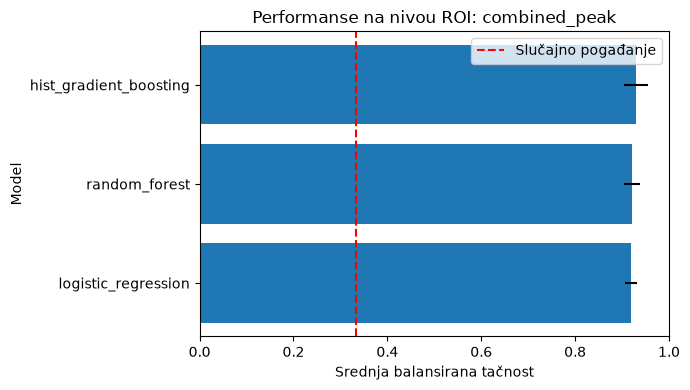

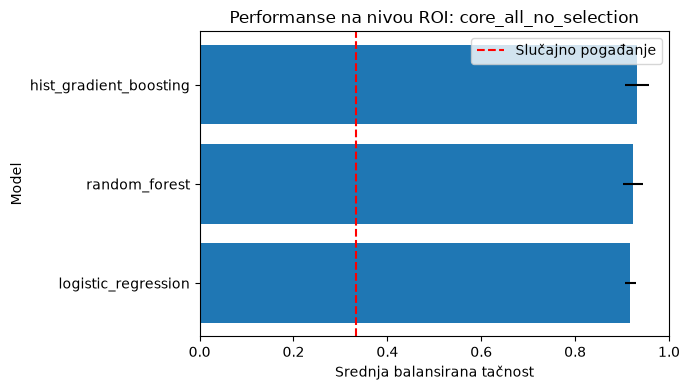

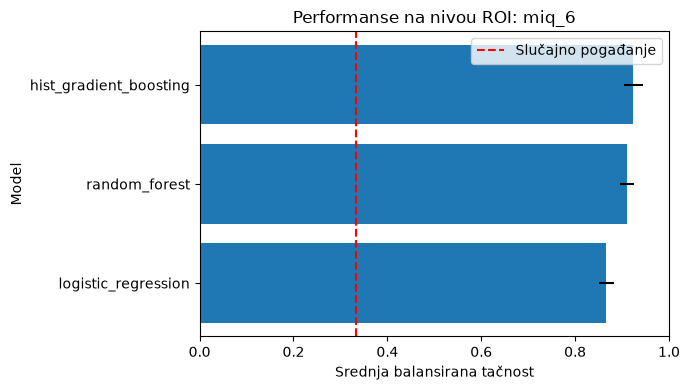

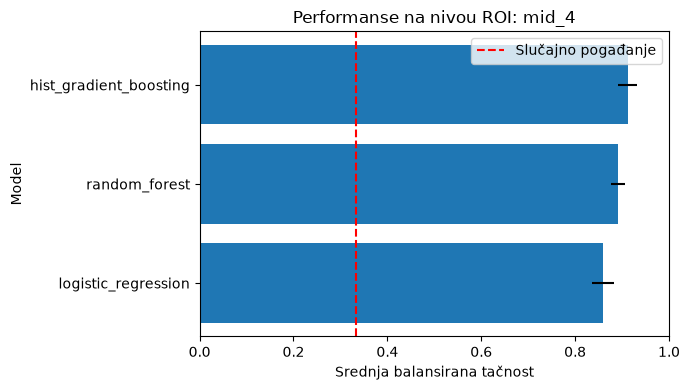

In [169]:
# Vizuelizacija performansi na nivou ROI
for representation_name in (
    combined_representations
):
    plot_data = (
        combined_roi_results.loc[
            combined_roi_results[
                "representation"
            ] == representation_name
        ]
        .sort_values(
            "test_balanced_accuracy_mean"
        )
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(
        plot_data["model"],
        plot_data[
            "test_balanced_accuracy_mean"
        ],
        xerr=plot_data[
            "test_balanced_accuracy_std"
        ],
    )

    ax.axvline(
        1 / 3,
        linestyle="--",
        color="red",
        label="Slučajno pogađanje",
    )

    ax.set_xlabel(
        "Srednja balansirana tačnost"
    )
    ax.set_ylabel("Model")
    ax.set_title(
        f"Performanse na nivou ROI: {representation_name}"
    )
    ax.set_xlim(0, 1)
    ax.legend()
    fig.tight_layout()

    save_figure(
        fig,
        f"{representation_name}_ROI_performance",
    )
    
    plt.show()

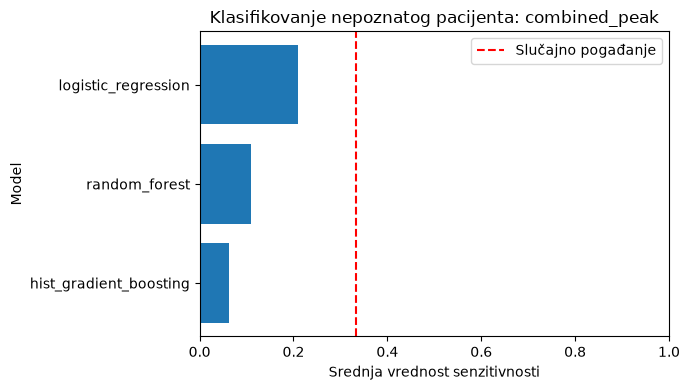

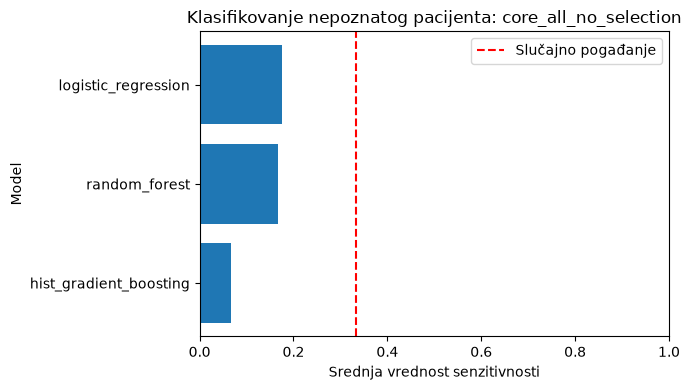

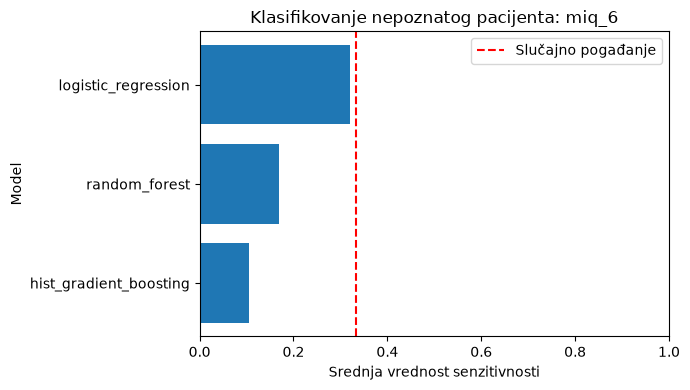

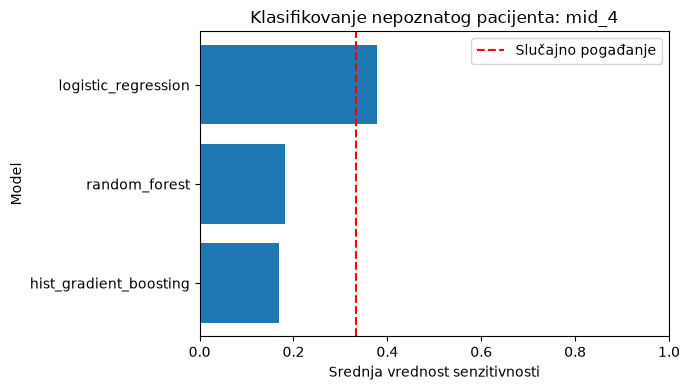

In [170]:
# Vizuelizacija performansi klasifikacije izostavljenog pacijenata
for representation_name in (
    combined_representations
):
    plot_data = (
        combined_holdout_summary.loc[
            combined_holdout_summary[
                "representation"
            ] == representation_name
        ]
        .sort_values(
            "mean_patient_recall"
        )
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(
        plot_data["model"],
        plot_data["mean_patient_recall"],
    )

    ax.axvline(
        1 / 3,
        linestyle="--",
        color="red",
        label="Slučajno pogađanje",
    )

    ax.set_xlabel(
        "Srednja vrednost senzitivnosti"
    )
    ax.set_ylabel("Model")
    ax.set_title(
        f"Klasifikovanje nepoznatog pacijenta: "
        f"{representation_name}"
    )
    ax.set_xlim(0, 1)
    ax.legend()
    fig.tight_layout()

    save_figure(
        fig,
        f"{representation_name}_holdout_performance",
    )
    
    plt.show()

In [171]:
# Čuvanje rezultata
COMBINED_RESULTS_DIR = MODELING_RESULTS_DIR / "LR_nonlinear_mRMR_combined"

COMBINED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

combined_roi_results.to_csv(
    COMBINED_RESULTS_DIR
    / "combined_mrmr_model_roi_cv_results.csv",
    index=False,
)

combined_holdout_results.to_csv(
    COMBINED_RESULTS_DIR
    / "combined_mrmr_model_patient_holdout_results.csv",
    index=False,
)

combined_holdout_summary.to_csv(
    COMBINED_RESULTS_DIR
    / "combined_mrmr_model_patient_holdout_summary.csv",
    index=False,
)

combined_joint_summary.to_csv(
    COMBINED_RESULTS_DIR
    / "combined_mrmr_model_joint_summary.csv",
    index=False,
)

Za kraj, ispitaćemo kako promena parametara metoda zasnovanih na stablima utiče na njihove performanse. Ispitivanje ćemo izvršiti sa četiri skupa osobina koje smo najskorije koristili.

## Podešavanje parametara nelinearnih modela

In [172]:
# Definisanje parametara modela (RF)
rf_sensitivity_factories = {
    # Bazna linija
    "rf_baseline": make_random_forest_pipeline,

    # Manja visina stabala sa većim listovima
    # i jača regularizacija
    "rf_regularized": partial(
        make_random_forest_pipeline,
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=10,
        max_features="sqrt",
    ),

    # Omogućavanje korišćenje
    # svih atributa za MRMR skupove
    "rf_regularized_all_features": partial(
        make_random_forest_pipeline,
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=10,
        max_features=None,
    ),
}

In [173]:
# Definisanje parametara modela (HGB)
hgb_sensitivity_factories = {
    # Bazna linija
    "hgb_baseline": (
        make_hist_gradient_boosting_pipeline
    ),

    # Prostija stabla i jača regularizacija
    "hgb_shallow_regularized": partial(
        make_hist_gradient_boosting_pipeline,
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=7,
        min_samples_leaf=30,
        l2_regularization=5.0,
    ),

    # Sporije učenje i jača regularizacija
    "hgb_low_learning_rate": partial(
        make_hist_gradient_boosting_pipeline,
        learning_rate=0.02,
        max_iter=400,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        l2_regularization=5.0,
    ),
}

In [174]:
# Kombinovanje 'factory' funkcija modela
tree_sensitivity_factories = {
    **rf_sensitivity_factories,
    **hgb_sensitivity_factories,
}

# Dodavanje oznaka
tree_variant_family = {
    variant_name: (
        "random_forest"
        if variant_name.startswith("rf_")
        else "hist_gradient_boosting"
    )
    for variant_name
    in tree_sensitivity_factories
}

In [175]:
# Analiza senzitivnosti na nivou ROI
tree_sensitivity_roi_rows = []

for representation_name, configuration in (
    combined_representations.items()
):
    features = configuration["features"]

    selection_method = configuration[
        "selection_method"
    ]

    n_selected_features = configuration[
        "n_selected_features"
    ]

    for (
        model_variant,
        base_model_factory,
    ) in tree_sensitivity_factories.items():

        if selection_method is None:
            current_model_factory = (
                base_model_factory
            )

        else:
            current_model_factory = (
                make_mrmr_model_factory(
                    base_model_factory=(
                        base_model_factory
                    ),
                    max_features=(
                        n_selected_features
                    ),
                    method=selection_method,
                )
            )

        result = evaluate_feature_set(
            model_name=model_variant,
            model_factory=current_model_factory,
            feature_set_name=representation_name,
            features=features,
        )

        result["representation"] = (
            representation_name
        )

        result["model_variant"] = (
            model_variant
        )

        result["model_family"] = (
            tree_variant_family[
                model_variant
            ]
        )

        result["selection_method"] = (
            selection_method
            if selection_method is not None
            else "none"
        )

        result["n_input_features"] = len(
            features
        )

        result["n_selected_features"] = (
            n_selected_features
        )

        tree_sensitivity_roi_rows.append(
            result
        )

# Kombinovanje rezultata
tree_sensitivity_roi_results = (
    pd.DataFrame(
        tree_sensitivity_roi_rows
    )
)

# Trening VS test razlika
tree_sensitivity_roi_results[
    "balanced_accuracy_gap"
] = (
    tree_sensitivity_roi_results[
        "train_balanced_accuracy_mean"
    ]
    - tree_sensitivity_roi_results[
        "test_balanced_accuracy_mean"
    ]
)

In [176]:
# Prikaz rezultata na nivou ROI
tree_sensitivity_roi_display = (
    tree_sensitivity_roi_results[
        [
            "representation",
            "model_family",
            "model_variant",
            "n_selected_features",
            "test_accuracy_mean",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_macro_mean",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .sort_values(
        [
            "representation",
            "model_family",
            "test_balanced_accuracy_mean",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

tree_sensitivity_roi_display.round(3)

,representation,model_family,model_variant,n_selected_features,test_accuracy_mean,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_macro_mean,train_balanced_accuracy_mean,balanced_accuracy_gap
0,combined_peak,hist_gradient_boosting,hgb_shallow_regularized,8,0.939,0.931,0.024,0.932,0.993,0.062
1,combined_peak,hist_gradient_boosting,hgb_baseline,8,0.938,0.930,0.025,0.930,1.000,0.070
2,combined_peak,hist_gradient_boosting,hgb_low_learning_rate,8,0.934,0.926,0.024,0.926,0.994,0.068
3,combined_peak,random_forest,rf_baseline,8,0.924,0.920,0.017,0.913,0.960,0.039
4,combined_peak,random_forest,rf_regularized,8,0.911,0.914,0.024,0.901,0.941,0.027
5,combined_peak,random_forest,rf_regularized_all_features,8,0.905,0.906,0.028,0.896,0.934,0.027
6,core_all_no_selection,hist_gradient_boosting,hgb_low_learning_rate,14,0.946,0.939,0.026,0.939,0.996,0.057
7,core_all_no_selection,hist_gradient_boosting,hgb_shallow_regularized,14,0.942,0.936,0.028,0.935,0.996,0.060
8,core_all_no_selection,hist_gradient_boosting,hgb_baseline,14,0.941,0.932,0.026,0.934,1.000,0.068
9,core_all_no_selection,random_forest,rf_baseline,14,0.923,0.923,0.022,0.915,0.961,0.037


In [177]:
# Balansirana tačnost
tree_sensitivity_roi_pivot = (
    tree_sensitivity_roi_results
    .pivot(
        index="representation",
        columns="model_variant",
        values="test_balanced_accuracy_mean",
    )
)

tree_sensitivity_roi_pivot.round(3)

model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
representation,,,,,,
combined_peak,0.930,0.926,0.931,0.920,0.914,0.906
core_all_no_selection,0.932,0.939,0.936,0.923,0.916,0.912
mid_4,0.912,0.909,0.903,0.891,0.886,0.889
miq_6,0.924,0.920,0.922,0.910,0.908,0.907


In [178]:
# Trening VS test razlika
tree_sensitivity_gap_pivot = (
    tree_sensitivity_roi_results
    .pivot(
        index="representation",
        columns="model_variant",
        values="balanced_accuracy_gap",
    )
)

tree_sensitivity_gap_pivot.round(3)

model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
representation,,,,,,
combined_peak,0.070,0.068,0.062,0.039,0.027,0.027
core_all_no_selection,0.068,0.057,0.060,0.037,0.029,0.026
mid_4,0.087,0.071,0.068,0.048,0.035,0.029
miq_6,0.076,0.065,0.060,0.035,0.022,0.017


In [179]:
# Promena u odnosu na LR
tree_roi_delta_from_lr = (
    tree_sensitivity_roi_pivot
    .subtract(
        combined_roi_balanced_accuracy_pivot[
            "logistic_regression"
        ],
        axis=0,
    )
)

tree_roi_delta_from_lr.round(3)

model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
representation,,,,,,
combined_peak,0.010,0.006,0.012,0.001,-0.006,-0.013
core_all_no_selection,0.014,0.022,0.019,0.006,-0.002,-0.006
mid_4,0.053,0.049,0.044,0.031,0.027,0.030
miq_6,0.057,0.053,0.055,0.043,0.041,0.040


Ono što možemo primetiti jeste da su se u slučaju RF primetno smanjile razlike u trening i test performansama. Na primer, u slučaju `mid_4` skupa osobina i `rf_regularized_all_features` model, razlika u ove dve vrednosti spala je na `0.029` sa vrednosti od `0.048` za osnovnu RF konfiguraciju. Ovo je praćeno zanemarljivim padom u performansama na nivou ROI.

U slučaju HGB, razlika u test i trening performansama i dalje je izražena, mada je i ona smanjena - za `mid_4`, vrednost je opala sa `0.087` na `0.068` u slučaju `hgb_shallow_regularized` modela.

In [180]:
# Izostavljanje po jednog pacijenta
tree_sensitivity_holdout_tables = []

for representation_name, configuration in (
    combined_representations.items()
):
    features = configuration["features"]

    selection_method = configuration[
        "selection_method"
    ]

    n_selected_features = configuration[
        "n_selected_features"
    ]

    for (
        model_variant,
        base_model_factory,
    ) in tree_sensitivity_factories.items():

        if selection_method is None:
            current_model_factory = (
                base_model_factory
            )

        else:
            current_model_factory = (
                make_mrmr_model_factory(
                    base_model_factory=(
                        base_model_factory
                    ),
                    max_features=(
                        n_selected_features
                    ),
                    method=selection_method,
                )
            )

        (
            holdout_long,
            _,
            _,
        ) = run_patient_holdout_analysis(
            feature_set_dictionary={
                representation_name: features,
            },
            model_factory=(
                current_model_factory
            ),
            model_name=model_variant,
        )

        holdout_long[
            "representation"
        ] = representation_name

        holdout_long[
            "model_variant"
        ] = model_variant

        holdout_long[
            "model_family"
        ] = tree_variant_family[
            model_variant
        ]

        holdout_long[
            "selection_method"
        ] = (
            selection_method
            if selection_method is not None
            else "none"
        )

        holdout_long[
            "n_selected_features"
        ] = n_selected_features

        tree_sensitivity_holdout_tables.append(
            holdout_long
        )

# Kombinovanje rezultata
tree_sensitivity_holdout_results = (
    pd.concat(
        tree_sensitivity_holdout_tables,
        ignore_index=True,
    )
)

In [181]:
# Sažeti rezultati
tree_sensitivity_holdout_summary = (
    tree_sensitivity_holdout_results
    .groupby(
        [
            "representation",
            "model_family",
            "model_variant",
            "n_selected_features",
        ],
        as_index=False,
    )
    .agg(
        mean_patient_recall=(
            "correct_class_recall",
            "mean",
        ),
        std_patient_recall=(
            "correct_class_recall",
            "std",
        ),
        minimum_patient_recall=(
            "correct_class_recall",
            "min",
        ),
        maximum_patient_recall=(
            "correct_class_recall",
            "max",
        ),
    )
)

In [182]:
# Prikaz rezultata
tree_sensitivity_holdout_display = (
    tree_sensitivity_holdout_summary
    .sort_values(
        [
            "representation",
            "model_family",
            "mean_patient_recall",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

tree_sensitivity_holdout_display.round(3)

,representation,model_family,model_variant,n_selected_features,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,combined_peak,hist_gradient_boosting,hgb_shallow_regularized,8,0.093,0.058,0.031,0.143
1,combined_peak,hist_gradient_boosting,hgb_low_learning_rate,8,0.066,0.054,0.018,0.143
2,combined_peak,hist_gradient_boosting,hgb_baseline,8,0.062,0.043,0.018,0.121
3,combined_peak,random_forest,rf_regularized_all_features,8,0.238,0.350,0.061,0.762
4,combined_peak,random_forest,rf_regularized,8,0.166,0.158,0.057,0.394
5,combined_peak,random_forest,rf_baseline,8,0.109,0.101,0.047,0.260
6,core_all_no_selection,hist_gradient_boosting,hgb_low_learning_rate,14,0.088,0.058,0.038,0.168
7,core_all_no_selection,hist_gradient_boosting,hgb_shallow_regularized,14,0.085,0.059,0.047,0.171
8,core_all_no_selection,hist_gradient_boosting,hgb_baseline,14,0.066,0.048,0.028,0.137
9,core_all_no_selection,random_forest,rf_regularized_all_features,14,0.238,0.339,0.057,0.746


In [183]:
# Srednja senzitivnost
tree_sensitivity_holdout_pivot = (
    tree_sensitivity_holdout_summary
    .pivot(
        index="representation",
        columns="model_variant",
        values="mean_patient_recall",
    )
)

tree_sensitivity_holdout_pivot.round(3)

model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
representation,,,,,,
combined_peak,0.062,0.066,0.093,0.109,0.166,0.238
core_all_no_selection,0.066,0.088,0.085,0.167,0.223,0.238
mid_4,0.169,0.185,0.194,0.182,0.295,0.298
miq_6,0.106,0.127,0.129,0.168,0.236,0.259


In [184]:
# Rezultati za svakog pacijenta
for representation_name in (
    combined_representations
):
    representation_patient_pivot = (
        tree_sensitivity_holdout_results.loc[
            tree_sensitivity_holdout_results[
                "representation"
            ] == representation_name
        ]
        .pivot(
            index=[
                "held_out_patient",
                "true_class",
            ],
            columns="model_variant",
            values="correct_class_recall",
        )
    )

    print(
        f"\nIzostavljanje pacijenata: "
        f"{representation_name}"
    )

    display(
        representation_patient_pivot.round(3)
    )


Izostavljanje pacijenata: combined_peak


,model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
held_out_patient,true_class,,,,,,
10a,SMA,0.052,0.057,0.057,0.061,0.061,0.061
10b,SMA,0.121,0.143,0.143,0.260,0.394,0.762
3,ALS,0.018,0.018,0.031,0.067,0.153,0.061
4,ALS,0.057,0.047,0.142,0.047,0.057,0.066



Izostavljanje pacijenata: core_all_no_selection


,model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
held_out_patient,true_class,,,,,,
10a,SMA,0.043,0.052,0.052,0.057,0.057,0.057
10b,SMA,0.137,0.168,0.171,0.387,0.571,0.746
3,ALS,0.055,0.092,0.067,0.166,0.190,0.092
4,ALS,0.028,0.038,0.047,0.057,0.075,0.057



Izostavljanje pacijenata: miq_6


,model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
held_out_patient,true_class,,,,,,
10a,SMA,0.070,0.074,0.065,0.074,0.070,0.070
10b,SMA,0.238,0.292,0.298,0.419,0.498,0.724
3,ALS,0.031,0.067,0.067,0.104,0.178,0.074
4,ALS,0.085,0.075,0.085,0.075,0.198,0.170



Izostavljanje pacijenata: mid_4


,model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
held_out_patient,true_class,,,,,,
10a,SMA,0.048,0.083,0.113,0.074,0.070,0.070
10b,SMA,0.314,0.279,0.321,0.397,0.676,0.737
3,ALS,0.227,0.301,0.258,0.209,0.245,0.215
4,ALS,0.085,0.075,0.085,0.047,0.189,0.170


In [185]:
# Promena u srednjoj senzitivnosti u odnosu na LR
tree_holdout_delta_from_lr = (
    tree_sensitivity_holdout_pivot
    .subtract(
        combined_holdout_mean_pivot[
            "logistic_regression"
        ],
        axis=0,
    )
)

tree_holdout_delta_from_lr.round(3)

model_variant,hgb_baseline,hgb_low_learning_rate,hgb_shallow_regularized,rf_baseline,rf_regularized,rf_regularized_all_features
representation,,,,,,
combined_peak,-0.147,-0.143,-0.116,-0.100,-0.043,0.028
core_all_no_selection,-0.110,-0.088,-0.091,-0.009,0.047,0.062
mid_4,-0.208,-0.192,-0.183,-0.195,-0.082,-0.079
miq_6,-0.214,-0.193,-0.191,-0.152,-0.084,-0.061


U slučaju HGB, najbolje rezultate pokazuje model `hgb_shallow_regularized`. Srednja vrednost senzitivnosti bolja je za svaki skup osobina, a za `combined_peak` i `mid_4` je zabeležena povećana senzitivnost u slučaju svakog pojedinačnog pacijenta. Ovo nam govori da je izvorna HGB konfiguracija bila previše fleksibilna. Ipak, senzitivnost je i dalje drastično niža u odnosu na logističku regresiju. Možemo zaključiti da jača regularizacija čini GB model manje specifičnim za uzorak, ali i dalje ne omogućava pouzdanu identifikaciju nepoznatog uzorka.

`hgb_low_learning_rate` u kombinaciji sa `core_all_no_selection` je model sa najboljim performansama na nivou ROI od svih dosad ispitanih, sa vrednošću balansirane tačnosti `0.939`. Međutim, srednja senzitivnost prilikom predikcije klase nepoznatih pacijenata iznosi svega `0.088`. Ovaj rezultat nije iznenađujuć ako uzmemo u obzir ono što smo dosad videli, a to je da optimizacija performansi na nivou ROI nekog modela ne dovodi nužno do poboljšanja moći njegove generalizacije; naprotiv, često se dešava suprotno.

RF pokazuje veći porast performansi, gde najbolji prosečan rezultat ima `rf_regularized_all_features`. Međutim, prosečan rezultat za ovaj model je uveliko posledica dobre performanse prilikom predikcije pacijenta `10b` i slabije predikcije ostalih pacijenata. Ovaj model daje slične, u proseku nešto lošije performanse na nivou ROI u odnosu na `rf_regularized`. `max_features=None` opcija omogućava da svako stablo bira iste ili slične, dominantne prediktore. Izgleda da je u ovom setu podataka takva konfiguracija posebno efektivna u predikciji pacijenta `10b`, ali da ne uspeva u slučaju ostalih pacijenata.

Možemo se osvrnuti na kombinaciju `mid_4` i `rf_regularized`, gde je senzitivnost znatno povećana za pacijente `10b` i `4`, a nešto bolja je i u slučaju pacijenta `3`, dok ostaje niska za pacijenta `10a`. Ovaj rezultat je malo uverljiviji u odnosu na varijantu sa `max_features=None`, jer porast vrednosti ne zavisi samo od pacijenta `10b`. Ipak, ukupan rezultat i dalje je lošiji od kombinacije `mid_4` i LR.

In [186]:
# Zajednički prikaz performanse na nivou ROI
# i prilikom izostavljanja pacijenata
tree_sensitivity_joint_summary = (
    tree_sensitivity_roi_results[
        [
            "representation",
            "model_family",
            "model_variant",
            "n_selected_features",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "train_balanced_accuracy_mean",
            "balanced_accuracy_gap",
        ]
    ]
    .merge(
        tree_sensitivity_holdout_summary[
            [
                "representation",
                "model_variant",
                "mean_patient_recall",
                "std_patient_recall",
                "minimum_patient_recall",
                "maximum_patient_recall",
            ]
        ],
        on=[
            "representation",
            "model_variant",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [187]:
# Rezultati poređani po performansama na nivou ROI
tree_sensitivity_joint_by_roi = (
    tree_sensitivity_joint_summary
    .sort_values(
        "test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

tree_sensitivity_joint_by_roi.round(3)

,representation,model_family,model_variant,n_selected_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,train_balanced_accuracy_mean,balanced_accuracy_gap,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,core_all_no_selection,hist_gradient_boosting,hgb_low_learning_rate,14,0.939,0.026,0.996,0.057,0.088,0.058,0.038,0.168
1,core_all_no_selection,hist_gradient_boosting,hgb_shallow_regularized,14,0.936,0.028,0.996,0.060,0.085,0.059,0.047,0.171
2,core_all_no_selection,hist_gradient_boosting,hgb_baseline,14,0.932,0.026,1.000,0.068,0.066,0.048,0.028,0.137
3,combined_peak,hist_gradient_boosting,hgb_shallow_regularized,8,0.931,0.024,0.993,0.062,0.093,0.058,0.031,0.143
4,combined_peak,hist_gradient_boosting,hgb_baseline,8,0.930,0.025,1.000,0.070,0.062,0.043,0.018,0.121
5,combined_peak,hist_gradient_boosting,hgb_low_learning_rate,8,0.926,0.024,0.994,0.068,0.066,0.054,0.018,0.143
6,miq_6,hist_gradient_boosting,hgb_baseline,6,0.924,0.020,1.000,0.076,0.106,0.091,0.031,0.238
7,core_all_no_selection,random_forest,rf_baseline,14,0.923,0.022,0.961,0.037,0.167,0.156,0.057,0.387
8,miq_6,hist_gradient_boosting,hgb_shallow_regularized,6,0.922,0.010,0.982,0.060,0.129,0.113,0.065,0.298
9,combined_peak,random_forest,rf_baseline,8,0.920,0.017,0.960,0.039,0.109,0.101,0.047,0.260


In [188]:
# Poređano po performansama pri izostavljanju pacijenata
tree_sensitivity_joint_by_holdout = (
    tree_sensitivity_joint_summary
    .sort_values(
        "mean_patient_recall",
        ascending=False,
    )
    .reset_index(drop=True)
)

tree_sensitivity_joint_by_holdout.round(3)

,representation,model_family,model_variant,n_selected_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,train_balanced_accuracy_mean,balanced_accuracy_gap,mean_patient_recall,std_patient_recall,minimum_patient_recall,maximum_patient_recall
0,mid_4,random_forest,rf_regularized_all_features,4,0.889,0.019,0.918,0.029,0.298,0.299,0.070,0.737
1,mid_4,random_forest,rf_regularized,4,0.886,0.015,0.921,0.035,0.295,0.265,0.070,0.676
2,miq_6,random_forest,rf_regularized_all_features,6,0.907,0.018,0.924,0.017,0.259,0.313,0.070,0.724
3,core_all_no_selection,random_forest,rf_regularized_all_features,14,0.912,0.027,0.938,0.026,0.238,0.339,0.057,0.746
4,combined_peak,random_forest,rf_regularized_all_features,8,0.906,0.028,0.934,0.027,0.238,0.350,0.061,0.762
5,miq_6,random_forest,rf_regularized,6,0.908,0.015,0.930,0.022,0.236,0.184,0.070,0.498
6,core_all_no_selection,random_forest,rf_regularized,14,0.916,0.019,0.945,0.029,0.223,0.239,0.057,0.571
7,mid_4,hist_gradient_boosting,hgb_shallow_regularized,4,0.903,0.020,0.972,0.068,0.194,0.113,0.085,0.321
8,mid_4,hist_gradient_boosting,hgb_low_learning_rate,4,0.909,0.024,0.980,0.071,0.185,0.122,0.075,0.301
9,mid_4,random_forest,rf_baseline,4,0.891,0.015,0.939,0.048,0.182,0.160,0.047,0.397


In [189]:
# Čuvanje rezultata
tree_sensitivity_roi_results.to_csv(
    NONLINEAR_RESULTS_DIR
    / "tree_sensitivity_roi_cv_results.csv",
    index=False,
)

tree_sensitivity_holdout_results.to_csv(
    NONLINEAR_RESULTS_DIR
    / "tree_sensitivity_holdout_results.csv",
    index=False,
)

tree_sensitivity_holdout_summary.to_csv(
    NONLINEAR_RESULTS_DIR
    / "tree_sensitivity_holdout_summary.csv",
    index=False,
)

tree_sensitivity_joint_summary.to_csv(
    NONLINEAR_RESULTS_DIR
    / "tree_sensitivity_joint_summary.csv",
    index=False,
)

Za konačni zaključak, izvršićemo poređenje srednje vrednosti senzitivnosti prilikom predviđanja klase nepoznatog pacijenta za neke od najboljih modela.


| Model i skup osobina | Srednja senzitivnost |
| :--- | ---: |
|`mid_4` LR|0.377|
|`miq_6` LR|0.320|
|`mid_4` regularizovana RF (sve osobine)|0.298|
|`mid_4` regularizovana RF|0.295|
|`miq_6` regularizovana RF (sve osobine)|0.259|
|`combined_peak` regularizovana RF (sve osobine)|0.238|
|`core_all_no_selection` regularizovana RF (sve osobine)|0.238|
|`miq_6` regularizovana RF|0.236|
|`core_all_no_selection` regularizovana RF|0.223|
|`combined_peak` LR|0.209|

Uzimajući u obzir činjenicu da je ukupan broj ispitanih kombinacija modela i skupova osobina prilično veliki, `combined_peak` skup osobina u kombinaciji sa logističkom regresijom zadržava relativno dobre performanse. Svakako najbolje performanse pokazuju skupovi osobina selektovani pomoću mRMR, naročito `mid_4` i `miq_6` u kombinaciji sa LR. Ono na šta treba obratiti pažnju jeste da je selekcija ovih modela izvršena poređenjem njihovih performansi na osnovu istih onih podataka pomoću kojih su skupovi osobina odabrani u originalnoj mRMR proceduri, tako da smo uveli element pristrasnosti u odabiru skupova osobina.

Kad su u pitanju modeli zasnovani na stablima, Gradient Boosting se pokazao kao slabo pouzdan u identifikaciji klase nepoznatog pacijenta, bez obzira na zadate parametre. Random Forest, iako bolji od GB, pokazuje lošije performanse od LR za `mid_4` i `miq_6` skpove osobina, bez obzira na parametre. RF sa zadatom opcijom `max_features=None` ima bolje prosečne performanse za `combined_peak` skup osobina u odnosu na LR (`0.238` naspram `0.209`), ali ovo je u suštini rezultat nesrazmerno dobre performanse za pacijenta `10b`. Isto važi i za `core_all_no_selection` skup osobina (identičan `combined_peak_plus_both_reduced_fit` skupu u analizama sa LR).

Na kraju se može reći da logistička regresija u kombinaciji sa `combined_peak` skupom osobina predstavlja primarni model sa najboljim ukupnim rezultatom kada se u obzir uzmu performanse na nivou ROI i na nivou nepoznatog pacijenta, doslednost rezultata, kompleksnost modela, i biološka smislenost. Najbolji eksploratorni model sa kompaktnim skupom osobina predstavlja logistička regresija sa `mid_4`.

## Završne vizuelizacije

Sledeće vizuelizacije objedinjuju najvažnije nalaze modeliranja: odnos između performansi na nivou ROI i prilikom detekcije nepoznatog paciejnta, heterogenost rezultata za pojedinačne pacijente i stabilnost mRMR selekcije.

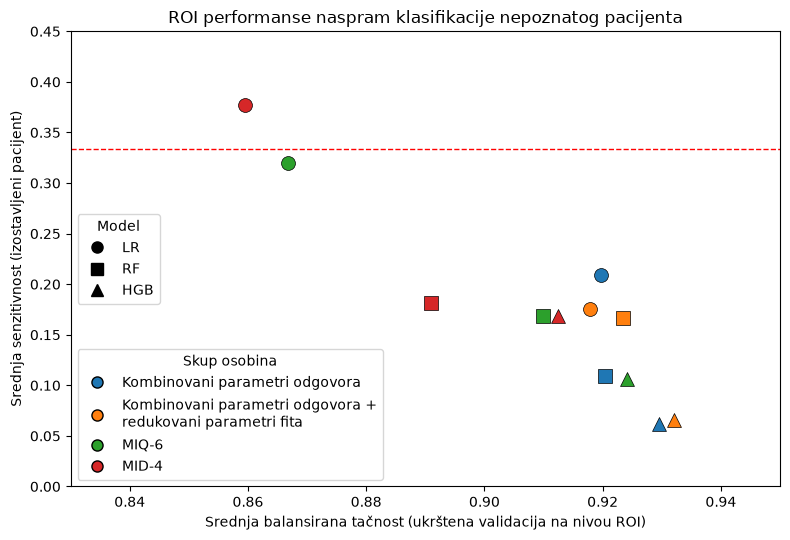

In [190]:
# Performanse na nivou ROI i za nepoznate pacijente
plot_data = (
    combined_joint_summary
    .copy()
)

representation_order = [
    "combined_peak",
    "core_all_no_selection",
    "miq_6",
    "mid_4",
]

model_order = [
    "logistic_regression",
    "random_forest",
    "hist_gradient_boosting",
]

representation_labels = {
    "combined_peak": "Kombinovani parametri odgovora",
    "core_all_no_selection": "Kombinovani parametri odgovora +\nredukovani parametri fita",
    "miq_6": "MIQ-6",
    "mid_4": "MID-4",
}

model_labels = {
    "logistic_regression": "LR",
    "random_forest": "RF",
    "hist_gradient_boosting": "HGB",
}

model_markers = {
    "logistic_regression": "o",
    "random_forest": "s",
    "hist_gradient_boosting": "^",
}

default_colors = (
    plt.rcParams[
        "axes.prop_cycle"
    ]
    .by_key()["color"]
)

representation_colors = dict(
    zip(
        representation_order,
        default_colors[
            :len(representation_order)
        ],
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5.5),
)

for _, row in plot_data.iterrows():
    ax.scatter(
        row[
            "test_balanced_accuracy_mean"
        ],
        row["mean_patient_recall"],
        s=100,
        marker=model_markers[
            row["model"]
        ],
        color=representation_colors[
            row["representation"]
        ],
        edgecolor="black",
        linewidth=0.5,
    )

ax.axhline(
    1 / 3,
    linestyle="--",
    color="red",
    linewidth=1,
    label="Orijentaciona vrednost 1/3",
)

representation_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=(
            representation_colors[
                representation
            ]
        ),
        markeredgecolor="black",
        label=(
            representation_labels[
                representation
            ]
        ),
        markersize=8,
    )
    for representation
    in representation_order
]

model_handles = [
    Line2D(
        [0],
        [0],
        marker=model_markers[model],
        linestyle="none",
        color="black",
        label=model_labels[model],
        markersize=8,
    )
    for model in model_order
]

representation_legend = ax.legend(
    handles=representation_handles,
    title="Skup osobina",
    loc="lower left",
)

ax.add_artist(representation_legend)

ax.legend(
    handles=model_handles,
    title="Model",
    loc="center left",
)

ax.set_xlabel("Srednja balansirana tačnost (ukrštena validacija na nivou ROI)")

ax.set_ylabel("Srednja senzitivnost (izostavljeni pacijent)")

ax.set_title("ROI performanse naspram klasifikacije nepoznatog pacijenta")

ax.set_xlim(0.83, 0.95,)

ax.set_ylim(0, 0.45,)

fig.tight_layout()

save_figure(
    fig,
    "roi_performance_vs_patient_transfer",
)

plt.show()

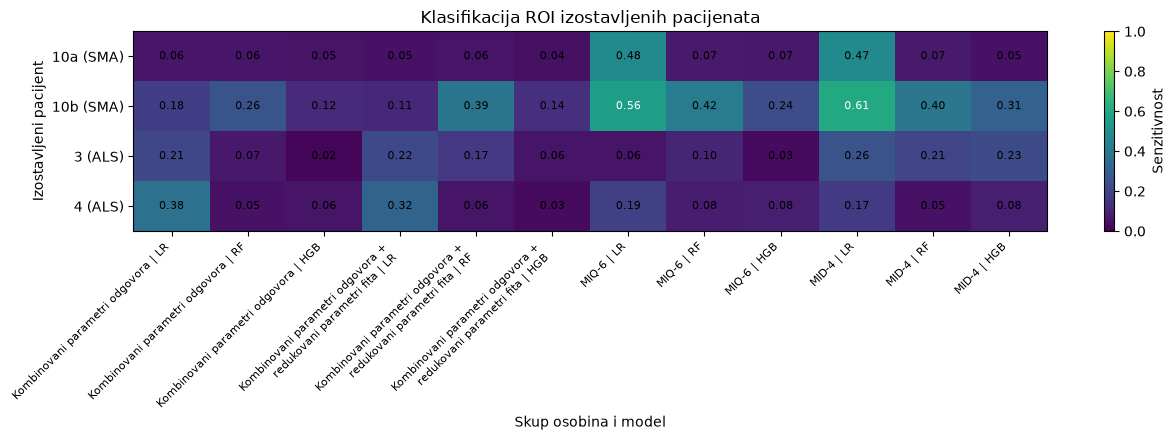

In [191]:
# Performanse pri izostavljanju pacijenata
model_short_labels = {
    "logistic_regression": "LR",
    "random_forest": "RF",
    "hist_gradient_boosting": "HGB",
}

representation_short_labels = {
    "combined_peak": "Kombinovani parametri odgovora",
    "core_all_no_selection": "Kombinovani parametri odgovora +\nredukovani parametri fita",
    "miq_6": "MIQ-6",
    "mid_4": "MID-4",
}

holdout_plot_data = (
    combined_holdout_results
    .copy()
)

holdout_plot_data[
    "configuration"
] = (
    holdout_plot_data[
        "representation"
    ].map(
        representation_short_labels
    )
    + " | "
    + holdout_plot_data[
        "model"
    ].map(
        model_short_labels
    )
)

holdout_plot_data[
    "patient_label"
] = (
    holdout_plot_data[
        "held_out_patient"
    ].astype(str)
    + " ("
    + holdout_plot_data[
        "true_class"
    ]
    + ")"
)

configuration_order = [
    (
        f"{representation_short_labels[representation]}"
        f" | {model_short_labels[model]}"
    )
    for representation
    in representation_order
    for model
    in model_order
]

patient_order = [
    "10a (SMA)",
    "10b (SMA)",
    "3 (ALS)",
    "4 (ALS)",
]

patient_heatmap = (
    holdout_plot_data
    .pivot(
        index="patient_label",
        columns="configuration",
        values="correct_class_recall",
    )
    .reindex(
        index=patient_order,
        columns=configuration_order,
    )
)

fig, ax = plt.subplots(
    figsize=(13, 4.5),
)

image = ax.imshow(
    patient_heatmap.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    np.arange(
        len(patient_heatmap.columns)
    ),
    labels=patient_heatmap.columns,
    rotation=45,
    ha="right",
    fontsize=8,
)

ax.set_yticks(
    np.arange(
        len(patient_heatmap.index)
    ),
    labels=patient_heatmap.index,
)

for row_index in range(
    patient_heatmap.shape[0]
):
    for column_index in range(
        patient_heatmap.shape[1]
    ):
        value = patient_heatmap.iat[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if value > 0.50
                else "black"
            ),
        )

fig.colorbar(
    image,
    ax=ax,
    label="Senzitivnost",
)

ax.set_xlabel("Skup osobina i model")

ax.set_ylabel("Izostavljeni pacijent")

ax.set_title("Klasifikacija ROI izostavljenih pacijenata")

fig.tight_layout()

save_figure(
    fig,
    "patient_holdout_heatmap",
)

plt.show()

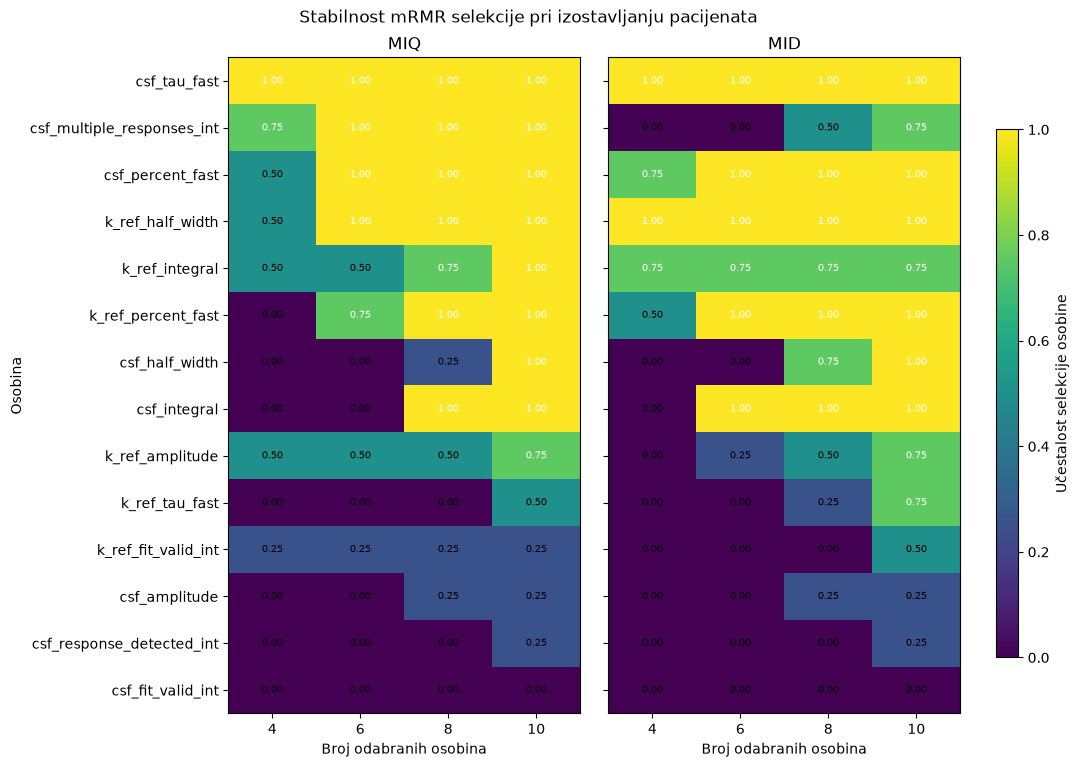

In [192]:
# Stabilnost mRMR selekcije
mrmr_feature_counts_order = [
    4,
    6,
    8,
    10,
]

miq_selection_plot = (
    mrmr_patient_selection_frequency_pivot
    .reindex(
        columns=mrmr_feature_counts_order,
        fill_value=0,
    )
)

mid_selection_plot = (
    mid_patient_selection_frequency_pivot
    .reindex(
        columns=mrmr_feature_counts_order,
        fill_value=0,
    )
)

maximum_selection_frequency = pd.concat(
    [
        miq_selection_plot.max(
            axis=1
        ).rename("MIQ"),
        mid_selection_plot.max(
            axis=1
        ).rename("MID"),
    ],
    axis=1,
).max(axis=1)

feature_order = (
    maximum_selection_frequency
    .sort_values(
        ascending=False
    )
    .index
)

miq_selection_plot = (
    miq_selection_plot
    .reindex(
        feature_order,
        fill_value=0,
    )
)

mid_selection_plot = (
    mid_selection_plot
    .reindex(
        feature_order,
        fill_value=0,
    )
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
    sharey=True,
)

for ax, selection_table, title in zip(
    axes,
    [
        miq_selection_plot,
        mid_selection_plot,
    ],
    [
        "MIQ",
        "MID",
    ],
):
    image = ax.imshow(
        selection_table.to_numpy(),
        aspect="auto",
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(
        np.arange(len(selection_table.columns)),
        labels=selection_table.columns,
    )

    ax.set_yticks(
        np.arange(len(selection_table.index)),
        labels=selection_table.index,
    )

    ax.set_xlabel("Broj odabranih osobina")

    ax.set_title(title)

    for row_index in range(
        selection_table.shape[0]
    ):
        for column_index in range(
            selection_table.shape[1]
        ):
            value = selection_table.iat[
                row_index,
                column_index,
            ]

            ax.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color=(
                    "white"
                    if value > 0.50
                    else "black"
                ),
            )

axes[0].set_ylabel("Osobina")

fig.suptitle("Stabilnost mRMR selekcije pri izostavljanju pacijenata")

fig.subplots_adjust(
    left=0.25,
    right=0.86,
    bottom=0.10,
    top=0.92,
    wspace=0.08,
)

colorbar_axis = fig.add_axes(
    [
        0.89,
        0.17,
        0.018,
        0.66,
    ]
)

colorbar = fig.colorbar(
    image,
    cax=colorbar_axis,
)

colorbar.set_label("Učestalost selekcije osobine")

save_figure(
    fig,
    "mrmr_patient_holdout_selection_stability",
)

plt.show()